<img src="https://github.com/djp840/MSDS_453_Public/blob/main/images/NorthwesternHeader.png?raw=1">

## MSDS453 - Research Assignment 01 - First Vectorized Representation


Our goal in this exercise is to BEGIN coming to a common agreement, among this class, as to what terms we will use as we selectively refine our corpus-wide vocabulary. This corpus vocabulary is what would represent the content of each different document for clustering and classification purposes, which will be our next step. This means that we need to make decisions - what is in, what is out.

In [ ]:
# Workaround for numpy downgrade caused by gensim

# Cell 1: Pre-installation Setup
# This cell will prepare the environment with compatible versions
# IMPORTANT: Put this at the very beginning of your notebook

# First, install the correct numpy version that gensim requires
#!pip install numpy==1.26.4 --force-reinstall
! pip install numpy

In [ ]:
# Cell 2

# # After the session is restarted, run this cell and Cell 3 and below too.
# # Then install gensim with the specific dependencies
# !pip install gensim==4.3.3
# !pip install scipy==1.13.1
!pip install gensim
!pip install scipy
#
# # Force restart the runtime programmatically
# import os
# import IPython
#
# # This will restart the runtime without user intervention
# try:
#     os._exit(00)
# except:
#     pass

# In Google Colab, the notebook will end (crash) here.

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 41.6 MB/s eta 0:00:00


In [ ]:
# Cell 3: Verify installation and import all libraries
# After the automatic restart, this will be the first cell to run

# In Google Colab, select Runtime > Run cell and below
import numpy as np
print(f"NumPy version: {np.__version__}")

import gensim
print(f"Gensim version: {gensim.__version__}")

NumPy version: 2.0.2
Gensim version: 4.4.0


In [ ]:
import pandas as pd
import os
import numpy as np
import re
import string
import seaborn as sns
import matplotlib.pyplot as plt
import nltk
import random
from dataclasses import dataclass

from nltk.stem.wordnet import WordNetLemmatizer
from nltk.stem import PorterStemmer

import gensim
from gensim.models import Word2Vec
from gensim.models.doc2vec import Doc2Vec, TaggedDocument

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.manifold import TSNE

import scipy.cluster.hierarchy

from IPython.display import display, HTML

from typing import List, Callable, Dict

### Mount Google Drive to Colab Environment

<div class="alert alert-block alert-success">
    <b>Directories Required for Research Assignment</b>:<br>
1. Data Directory - Source Class Corpus Data<br>
2. Output Directory - Vocabulary<br>
</div>

#### Uncomment To Map Drive

In [ ]:
from google.colab import drive
#drive.mount('/content/gdrive/My Drive')
##drive.mount('/content/gdrive/')

### NLTK Downloads

In [ ]:
# Only run this once, they will be downloaded.
nltk.download('stopwords',quiet=True)
nltk.download('wordnet',quiet=True)
#nltk.download('punkt',quiet=True)  # replaced by punkt due to "unsafe pickling" by NLTK developers
nltk.download('punkt_tab',quiet=True)
nltk.download('omw-1.4',quiet=True)

True

<div class="alert alert-block alert-danger">
<b>Gensim</b> is a Python library for topic modelling, document indexing and similarity retrieval with large corpora. Target audience is the natural language processing (NLP) and information retrieval (IR) community <br><br>
    <b>https://pypi.org/project/gensim/ </b>
</div>

In [ ]:
import pkg_resources
#pkg_resources.require("gensim<=3.8.3");

/tmp/ipykernel_15143/2941816030.py:1: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  import pkg_resources


In [ ]:
print("Genism Version: ", gensim.__version__)

Genism Version:  4.4.0


<div class="alert alert-block alert-info">
    <b>Suppress warning messages</b></div>

In [ ]:
def warn(*args, **kwargs):
    pass
import warnings
warnings.warn = warn

## Utility Functions

In [ ]:
def add_movie_descriptor(data: pd.DataFrame, corpus_df: pd.DataFrame):
    """
    Adds "Movie Description" to the supplied dataframe, in the form {Genre}_{P|N}_{Movie Title}_{DocID}
    """
    review = np.where(corpus_df['Review Type (pos or neg)'] == 'Positive', 'P', 'N')
    data['Descriptor'] = corpus_df['Genre of Movie'] + '_' + corpus_df['Movie Title'] + '_' + review + '_' + corpus_df['Doc_ID'].astype(str)

def get_corpus_df(path):
    data = pd.read_csv(path, encoding="utf-8")
    add_movie_descriptor(data, data)
    sorted_data = data.sort_values(['Descriptor'])
    indexed_data = sorted_data.set_index(['Doc_ID'])
    indexed_data['Doc_ID'] = indexed_data.index
    return indexed_data

def remove_punctuation(text):
    return re.sub('[^a-zA-Z]', ' ', str(text))

def lower_case(text):
    return text.lower()

def remove_tags(text):
    return re.sub("&lt;/?.*?&gt;"," &lt;&gt; ", text)

def remove_special_chars_and_digits(text):
    return re.sub("(\\d|\\W)+"," ", text)

@dataclass
class Document:
    doc_id: str
    text: str

def normalize_document(document: Document) -> Document:
    text = document.text
    text = remove_punctuation(text)
    text = lower_case(text)
    text = remove_tags(text)
    text = remove_special_chars_and_digits(text)

    return Document(document.doc_id, text)

def normalize_documents(documents: List[Document]) -> List[Document]:
    """
    Normalizes text for all given documents.
    Removes punctuation, converts to lower case, removes tags and special characters.
    """
    return [normalize_document(x) for x in documents]

@dataclass
class TokenizedDocument:
    doc_id: str
    tokens: List[str]

def tokenize_document(document: Document) -> TokenizedDocument:
    tokens = nltk.word_tokenize(document.text)
    return TokenizedDocument(document.doc_id, tokens)

def tokenize_documents(documents: List[Document]) -> List[TokenizedDocument]:
    return [tokenize_document(x) for x in documents]

def lemmatize(documents: List[TokenizedDocument]) -> List[TokenizedDocument]:
    result = []
    lemmatizer = WordNetLemmatizer()
    for document in documents:
        output_tokens = [lemmatizer.lemmatize(w) for w in document.tokens]
        result.append(TokenizedDocument(document.doc_id, output_tokens))

    return result

def stem(documents: List[TokenizedDocument]) -> List[TokenizedDocument]:
    result = []
    stemmer = PorterStemmer()
    for document in documents:
        output_tokens = [stemmer.stem(w) for w in document.tokens]
        result.append(TokenizedDocument(document.doc_id, output_tokens))
    return result

def remove_stop_words(documents: List[TokenizedDocument]) -> List[TokenizedDocument]:
    result = []

    stop_words = set(nltk.corpus.stopwords.words('english'))
    for document in documents:
        filtered_tokens = [w for w in document.tokens if not w in stop_words]
        result.append(TokenizedDocument(document.doc_id, filtered_tokens))

    return result

def add_flags(data: pd.DataFrame, casino_royale_doc_ids: List[int], action_doc_ids: List[int]):
    data['is_casino_royale'] = data.index.isin(casino_royale_doc_ids)
    data['is_action'] = data.index.isin(action_doc_ids)

def get_all_tokens(documents: List[TokenizedDocument]) -> List[str]:
    tokens = {y for x in documents for y in x.tokens}
    return sorted(list(tokens))

## Loading the corpus

In [ ]:
CORPUS_PATH=\
'https://raw.githubusercontent.com/barrycforever/MSDS_453_NLP/main/MSDS453_ClassCorpus/MSDS453_QA_20220906.csv'
corpus_df = get_corpus_df(CORPUS_PATH)
documents = [Document(x, y) for x, y in zip(corpus_df.Doc_ID, corpus_df.Text)]

In [ ]:
# CORPUS_PATH = './data/MSDS453_Sec57_TestQA_ClassCorpus.csv'
# corpus_df = get_corpus_df(CORPUS_PATH)
# documents = [Document(x, y) for x, y in zip(corpus_df.Doc_ID, corpus_df.Text)]

1. Dataframe = corpus_df
2. List = documents (Document ID, Text)

## Exploritory Data Analysis

In [ ]:
corpus_df.shape

(200, 9)

In [ ]:
corpus_df.head(4).T

Doc_ID,40,41,42,43
DSI_Title,KCM_Doc1_AngelHasFallen,KCM_Doc2_AngelHasFallen,KCM_Doc3_AngelHasFallen,KCM_Doc4_AngelHasFallen
Text,Boredom sets in long before the start of Angel...,\nWho ARE all these people?\n\nThat was what...,Ric Roman Waughs Angel Has Fallen sees U.S. S...,There is a certain mindless pleasure in the Fa...
Submission File Name,KCM_Doc1_AngelHasFallen,KCM_Doc2_AngelHasFallen,KCM_Doc3_AngelHasFallen,KCM_Doc4_AngelHasFallen
Student Name,KCM,KCM,KCM,KCM
Genre of Movie,Action,Action,Action,Action
Review Type (pos or neg),Negative,Negative,Negative,Negative
Movie Title,Angel Has Fallen,Angel Has Fallen,Angel Has Fallen,Angel Has Fallen
Descriptor,Action_Angel Has Fallen_N_40,Action_Angel Has Fallen_N_41,Action_Angel Has Fallen_N_42,Action_Angel Has Fallen_N_43
Doc_ID,40,41,42,43


In [ ]:
print(corpus_df.info());

<class 'pandas.core.frame.DataFrame'>
Index: 200 entries, 40 to 199
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   DSI_Title                 200 non-null    object
 1   Text                      200 non-null    object
 2   Submission File Name      200 non-null    object
 3   Student Name              200 non-null    object
 4   Genre of Movie            200 non-null    object
 5   Review Type (pos or neg)  200 non-null    object
 6   Movie Title               200 non-null    object
 7   Descriptor                200 non-null    object
 8   Doc_ID                    200 non-null    int64 
dtypes: int64(1), object(8)
memory usage: 15.6+ KB
None


In [ ]:
print(corpus_df['Movie Title'].unique())

['Angel Has Fallen' 'Inception' 'No Time To Die' 'Taken' 'Taxi'
 'Despicable Me 3' 'Dirty Grandpa' 'Holmes and Watson' 'Legally Blonde'
 'The Lost City' 'Drag me to hell' 'Fresh' 'It Chapter Two'
 'The Toxic Avenger' 'US' 'Batman' 'Equilibrium' 'Minority Report'
 'Oblivion' 'Pitch Black']


## Number of Reviews By Genre

In [ ]:
counts_df = corpus_df[['Genre of Movie']].copy()
counts_df['Count'] = 1
counts_df.groupby(['Genre of Movie']).count().reset_index()

,Genre of Movie,Count
0,Action,50
1,Comedy,50
2,Horror,50
3,Sci-Fi,50


In [ ]:
corpus_df.columns

Index(['DSI_Title', 'Text', 'Submission File Name', 'Student Name',
       'Genre of Movie', 'Review Type (pos or neg)', 'Movie Title',
       'Descriptor', 'Doc_ID'],
      dtype='object')

## Normalized Document

1. remove_punctuation(text)
2. lower_case(text)
3. remove_tags(text)
4. remove_special_chars_and_digits(text)
5. return Document(document.doc_id, text)

In [ ]:
normalized_documents = normalize_documents(documents)
normalized_documents[0]

Document(doc_id=40, text='boredom sets in long before the start of angel has fallen i start my journey to the movie by changing out of my work clothes into something more comfortable instead of something complex like a dress shirt with buttons and a collar along with khaki pants that require a belt i wear a loose fitting t shirt and a light pair of cargo shorts i want something simple and uncomplicated like the plot to an action movie boiled down to guy is framed guy wants revenge guy kills guys for revenge it took only one person to pick out both of my outfits for the day an accomplishment that seems remarkable compared to the three people who wrote the script to angel has fallen completely different from the two people who wrote the story of said movie a total of five people were needed to tell another convoluted story of gerard butler running from slightly bearded men with guns for two hours compared to the minutes it took me to figure out the clothes appropriate for the day it s ha

## Standardize Document

#### NLTK Tokenizer Package

https://www.nltk.org/api/nltk.tokenize.html

Tokenizers divide strings into lists of substrings. For example, tokenizers can be used to find the words and punctuation in a string:

### Functions for Tokenization Process
1. tokenize_document
2. tokenize_documents

In [ ]:
tokenized_documents = tokenize_documents(normalized_documents)
tokenized_documents[0]

TokenizedDocument(doc_id=40, tokens=['boredom', 'sets', 'in', 'long', 'before', 'the', 'start', 'of', 'angel', 'has', 'fallen', 'i', 'start', 'my', 'journey', 'to', 'the', 'movie', 'by', 'changing', 'out', 'of', 'my', 'work', 'clothes', 'into', 'something', 'more', 'comfortable', 'instead', 'of', 'something', 'complex', 'like', 'a', 'dress', 'shirt', 'with', 'buttons', 'and', 'a', 'collar', 'along', 'with', 'khaki', 'pants', 'that', 'require', 'a', 'belt', 'i', 'wear', 'a', 'loose', 'fitting', 't', 'shirt', 'and', 'a', 'light', 'pair', 'of', 'cargo', 'shorts', 'i', 'want', 'something', 'simple', 'and', 'uncomplicated', 'like', 'the', 'plot', 'to', 'an', 'action', 'movie', 'boiled', 'down', 'to', 'guy', 'is', 'framed', 'guy', 'wants', 'revenge', 'guy', 'kills', 'guys', 'for', 'revenge', 'it', 'took', 'only', 'one', 'person', 'to', 'pick', 'out', 'both', 'of', 'my', 'outfits', 'for', 'the', 'day', 'an', 'accomplishment', 'that', 'seems', 'remarkable', 'compared', 'to', 'the', 'three', 'p

## Useful Lookups (Titles by DocID, Genres by DocID, Description by DocID)

In [ ]:
titles_by_doc_ids = {x: y for x, y in zip(corpus_df['Doc_ID'], corpus_df['Movie Title'])}
genres_by_doc_ids = {x: y for x, y in zip(corpus_df['Doc_ID'], corpus_df['Genre of Movie'])}
descriptors_by_doc_ids = {x: y for x, y in zip(corpus_df['Doc_ID'], corpus_df['Descriptor'])}

action_doc_ids = [int(x) for x in corpus_df['Doc_ID'] if genres_by_doc_ids[x] == 'Action']
action_documents = [x for x in documents if x.doc_id in action_doc_ids]

non_action_doc_ids = {int(x) for x in corpus_df['Doc_ID'] if genres_by_doc_ids[x] != 'Action'}
non_action_documents = [x for x in documents if x.doc_id in non_action_doc_ids]

## Lookup for Specific Movie Title

In [ ]:
print(corpus_df['Movie Title'].unique())

['Angel Has Fallen' 'Inception' 'No Time To Die' 'Taken' 'Taxi'
 'Despicable Me 3' 'Dirty Grandpa' 'Holmes and Watson' 'Legally Blonde'
 'The Lost City' 'Drag me to hell' 'Fresh' 'It Chapter Two'
 'The Toxic Avenger' 'US' 'Batman' 'Equilibrium' 'Minority Report'
 'Oblivion' 'Pitch Black']


In [ ]:
casino_royale_doc_ids = [int(x) for x in corpus_df['Doc_ID'] if titles_by_doc_ids[x] == 'Batman']
casino_royale_documents = [x for x in documents if x.doc_id in casino_royale_doc_ids]

## Qualitative Term Determinations

#### Terms Determined by Document of Interest

In [ ]:
candidate_terms = [
    'action',
    'sequence',
    'grit',
    'plot',
    'chase',
    'airline',
    'stock',
    'series',
    'effect',
    'strong',
    'theme',
    'character',
    'money',
    'spy'
]

## CountVectorizer

<div class="alert alert-block alert-success">
    <b>sklearn.feature_extraction.text.CountVectorizer</b>:<br>
Convert a collection of text documents to a matrix of token counts.<br>
This implementation produces a sparse representation of the counts using scipy.sparse.csr_matrix.<br>
If you do not provide an a-priori dictionary and you do not use an analyzer that does some kind of feature selection then the number of features will be equal to the vocabulary size found by analyzing the data.
</div>

In [ ]:
vectorizer = CountVectorizer(ngram_range=(1, 1))
text_for_counts = [x.text for x in normalized_documents]
matrix = vectorizer.fit_transform(text_for_counts)
words = vectorizer.get_feature_names_out()
word_counts = pd.DataFrame(matrix.toarray(), columns=words, index=corpus_df.Doc_ID)

In [ ]:
add_flags(word_counts, casino_royale_doc_ids, action_doc_ids)
word_counts['Doc_ID'] = word_counts.index

In [ ]:
# Collect result into a dataframe
mean_frequencies = pd.DataFrame(index=candidate_terms)

casino_royale_mean_frequencies = word_counts[word_counts.is_casino_royale][[x for x in candidate_terms if x in word_counts.columns]].mean()
mean_frequencies['Batman'] = casino_royale_mean_frequencies

action_mean_frequencies = word_counts[word_counts.is_action][[x for x in candidate_terms if x in word_counts.columns]].mean()
mean_frequencies['All Action'] = action_mean_frequencies

non_action_mean_frequencies = word_counts[~word_counts.is_action][[x for x in candidate_terms if x in word_counts.columns]].mean()
mean_frequencies['All Non-Action'] = non_action_mean_frequencies

In [ ]:
mean_frequencies.fillna(0.0).sort_values(['Batman'], ascending=False)

,Batman,All Action,All Non-Action
character,2.4,0.96,0.900000
action,1.0,2.40,0.860000
series,0.8,0.68,0.313333
theme,0.5,0.08,0.113333
stock,0.3,0.02,0.060000
sequence,0.3,0.56,0.266667
effect,0.1,0.04,0.126667
chase,0.0,0.40,0.113333
plot,0.0,0.80,0.593333
grit,0.0,0.00,0.000000


In [ ]:
# These are identified
important_prevalent_terms = [
    'action',
    'series',
    'money',
    'chase'
]
stemmer = PorterStemmer()
stemmed_important_prevalent_terms = [stemmer.stem(x) for x in important_prevalent_terms]

In [ ]:
pd.options.display.float_format = '{:,.2f}'.format
mean_frequencies.fillna(0.0).loc[important_prevalent_terms].round(2).sort_values(['Batman'], ascending=False)

,Batman,All Action,All Non-Action
action,1.00,2.40,0.86
series,0.80,0.68,0.31
money,0.00,0.16,0.11
chase,0.00,0.40,0.11


t-SNE Utility function

In [ ]:
# NEW

from typing import Optional, Sequence, Union
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

def plot_tsne_by_category(
    data: Union[pd.DataFrame, np.ndarray],
    categories: Union[pd.Series, Sequence],
    title: str = "t-SNE (colored by category)",
    *,
    perplexity: Optional[float] = None,
    figsize=(14, 12),
    random_state: int = 42,
    legend_max: int = 20,
    point_size: int = 30,
    alpha: float = 0.8,
):
    """
    2D t-SNE scatter with points colored by category.
    - data: rows = points, columns = features (DataFrame or ndarray)
    - categories: labels per row (pd.Series indexed like data.index OR a Sequence aligned by order)
    - title: plot title
    Optional:
    - perplexity: if None, auto-chooses a reasonable value based on n
    - legend_max: cap the number of legend entries to keep it readable
    """
    # Coerce data/labels and align
    if isinstance(data, pd.DataFrame):
        X = data.values
        idx = data.index
    else:
        X = np.asarray(data)
        idx = pd.RangeIndex(len(X))

    if isinstance(categories, pd.Series):
        cats = categories.reindex(idx)
    else:
        if len(categories) != len(idx):
            raise ValueError("Length of 'categories' must match number of rows in 'data'.")
        cats = pd.Series(categories, index=idx)

    n = X.shape[0]
    if n < 2:
        raise ValueError("Need at least 2 points for t-SNE.")
    if perplexity is None:
        perplexity = 30 if n >= 50 else max(5, min(30, n // 2))

    tsne = TSNE(
        n_components=2,
        perplexity=perplexity,
        init="pca",
        learning_rate="auto",
        random_state=random_state,
    )
    Y = tsne.fit_transform(X)

    # Preserve category order of first appearance
    uniq = list(dict.fromkeys(cats.astype(str).values))
    cmap = plt.cm.get_cmap("tab20", max(20, len(uniq)))

    fig, ax = plt.subplots(figsize=figsize)
    for i, cat in enumerate(uniq):
        mask = (cats.astype(str).values == cat)
        pts = Y[mask]
        ax.scatter(pts[:, 0], pts[:, 1], s=point_size, alpha=alpha, color=cmap(i % cmap.N), label=cat)

    ax.set_title(title)
    ax.set_xlabel("t-SNE-1")
    ax.set_ylabel("t-SNE-2")

    handles, labels = ax.get_legend_handles_labels()
    if len(labels) > legend_max:
        ax.legend(handles[:legend_max], labels[:legend_max], title="Category",
                  bbox_to_anchor=(1.05, 1), loc="upper left")
    else:
        ax.legend(title="Category", bbox_to_anchor=(1.05, 1), loc="upper left")

    plt.tight_layout()
    plt.show()
    return Y  # return coordinates if the caller wants them

## TF-IDF Experiment Functions - Text Normalization

In [ ]:
# PREVIOUS VERSION

# def run_tfidf(documents: List[Document],
#               clean_func: Callable[[List[Document]], List[TokenizedDocument]],
#               important_prevalent_terms: List[str],
#               experiment_name: str,
#               output_tfidf_vectors: bool=False,
#               output_vocabulary: bool=True):
#     cleaned_documents = clean_func(documents)
#     cleaned_document_text = [' '.join(x.tokens) for x in cleaned_documents]

#     vectorizer = TfidfVectorizer(use_idf=True,
#                                  ngram_range=(1, 1),
#                                  norm=None)

#     transformed_documents = vectorizer.fit_transform(cleaned_document_text)
#     transformed_documents_as_array = transformed_documents.toarray()

#     output_dir = f'output/{experiment_name}_Results'
#     if not os.path.exists(output_dir):
#         os.makedirs(output_dir)

#     if output_tfidf_vectors:
#         for counter, doc in enumerate(transformed_documents_as_array):
#             tf_idf_tuples = list(zip(vectorizer.get_feature_names_out(), doc))
#             one_doc_as_df = pd.DataFrame.from_records(tf_idf_tuples, columns=['term', 'score'])\
#                                         .sort_values(by='score', ascending=False)\
#                                         .reset_index(drop=True)

#             one_doc_as_df.to_csv(f'{output_dir}/{corpus_df["Submission File Name"][counter]}')

#     if output_vocabulary:
#         with open(f'{output_dir}/vocabulary.txt', 'w') as vocab:
#             words = sorted(vectorizer.get_feature_names_out())
#             print('\n'.join(words), file=vocab)

#     # Create document-term dataframe
#     doc_term_matrix = transformed_documents.todense()
#     doc_term_df = pd.DataFrame(doc_term_matrix,
#                                columns=vectorizer.get_feature_names_out(),
#                                index=corpus_df.Doc_ID)
#     add_flags(doc_term_df, casino_royale_doc_ids, action_doc_ids)

#     # Print the top 10 mean TF-IDF values
#     top10_tfidf = pd.DataFrame(doc_term_df.mean().sort_values(ascending=False).head(10))
#     top10_tfidf.rename(columns={0: 'Mean TF-IDF'}, inplace=True)
#     display(top10_tfidf)

#     # Collect result into a dataframe
#     tfidf_results = pd.DataFrame(index=important_prevalent_terms)

#     all_tfidf_results = doc_term_df[[x for x in important_prevalent_terms if x in doc_term_df.columns]].mean().round(2)
#     tfidf_results['All Movies'] = all_tfidf_results

#     plt.hist(doc_term_df.mean(), 100, range=(0, 8))

#     print(f'Vocabulary size: {doc_term_df.shape[1]}')

#     descriptors = corpus_df['Descriptor']

#     similarities = cosine_similarity(doc_term_df.loc[action_doc_ids], doc_term_df.loc[action_doc_ids])
#     fig, ax = plt.subplots(figsize=(30, 30))
#     labels = [descriptors_by_doc_ids[x.doc_id] for x in action_documents]
#     sns.heatmap(ax=ax, data=similarities, xticklabels=labels, yticklabels=labels)
#     #plt.savefig(f'figures/{experiment_name}_heatmap_documents.png')
#     plt.show()

In [ ]:
# NEW CHANGED

def run_tfidf(documents: List[Document],
              clean_func: Callable[[List[Document]], List[TokenizedDocument]],
              important_prevalent_terms: List[str],
              experiment_name: str,
              output_tfidf_vectors: bool=False,
              output_vocabulary: bool=True,
              plot_action_heatmap: bool=True) -> pd.DataFrame:
    cleaned_documents = clean_func(documents)
    cleaned_document_text = [' '.join(x.tokens) for x in cleaned_documents]

    vectorizer = TfidfVectorizer(use_idf=True,
                                 ngram_range=(1, 1),
                                 norm=None)

    transformed_documents = vectorizer.fit_transform(cleaned_document_text)
    transformed_documents_as_array = transformed_documents.toarray()

    output_dir = f'output/{experiment_name}_Results'
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)

    if output_tfidf_vectors:
        for counter, doc in enumerate(transformed_documents_as_array):
            tf_idf_tuples = list(zip(vectorizer.get_feature_names_out(), doc))
            one_doc_as_df = (pd.DataFrame.from_records(tf_idf_tuples, columns=['term', 'score'])
                                .sort_values(by='score', ascending=False)
                                .reset_index(drop=True))
            one_doc_as_df.to_csv(f'{output_dir}/{corpus_df["Submission File Name"][counter]}')

    if output_vocabulary:
        with open(f'{output_dir}/vocabulary.txt', 'w') as vocab:
            words = sorted(vectorizer.get_feature_names_out())
            print('\n'.join(words), file=vocab)

    # document-term dataframe
    doc_term_matrix = transformed_documents.todense()
    doc_term_df = pd.DataFrame(doc_term_matrix,
                               columns=vectorizer.get_feature_names_out(),
                               index=corpus_df.Doc_ID)
    add_flags(doc_term_df, casino_royale_doc_ids, action_doc_ids)

    # top-10 mean TF-IDF
    top10_tfidf = pd.DataFrame(doc_term_df.mean().sort_values(ascending=False).head(10))
    top10_tfidf.rename(columns={0: 'Mean TF-IDF'}, inplace=True)
    display(top10_tfidf)

    # mean scores for important terms
    tfidf_results = pd.DataFrame(index=important_prevalent_terms)
    all_tfidf_results = doc_term_df[[x for x in important_prevalent_terms if x in doc_term_df.columns]].mean().round(2)
    tfidf_results['All Movies'] = all_tfidf_results

    plt.hist(doc_term_df.mean(), 100, range=(0, 8))
    print(f'Vocabulary size: {doc_term_df.shape[1]}')

    # keep original 50×50 action heatmap unless disabled
    if plot_action_heatmap:
        similarities = cosine_similarity(doc_term_df.loc[action_doc_ids], doc_term_df.loc[action_doc_ids])
        fig, ax = plt.subplots(figsize=(30, 30))
        labels = [descriptors_by_doc_ids[x.doc_id] for x in action_documents]
        sns.heatmap(ax=ax, data=similarities, xticklabels=labels, yticklabels=labels)
        # plt.savefig(f'figures/{experiment_name}_heatmap_documents.png')
        plt.show()

    # NEW: return the doc-term matrix for downstream visuals
    return doc_term_df

## TF-IDF  (Term Frequency-Inverse Document Frequency)

### Experiments, Normalize, Tokenize, Lemmatization and Stop Word Removal

In [ ]:
def clean_method(documents: List[Document]) -> List[TokenizedDocument]:
    """
    Normalizes text, tokenizes, lemmatizes, and removes stop words.
    """
    documents = normalize_documents(documents)
    documents = tokenize_documents(documents)
    documents = lemmatize(documents)
    documents = remove_stop_words(documents)
    documents = stem(documents)
    return documents

,Mean TF-IDF
film,5.74
movi,4.76
ha,3.59
wa,3.41
one,3.36
like,3.10
bond,3.08
time,2.66
make,2.59
get,2.48


Vocabulary size: 10073


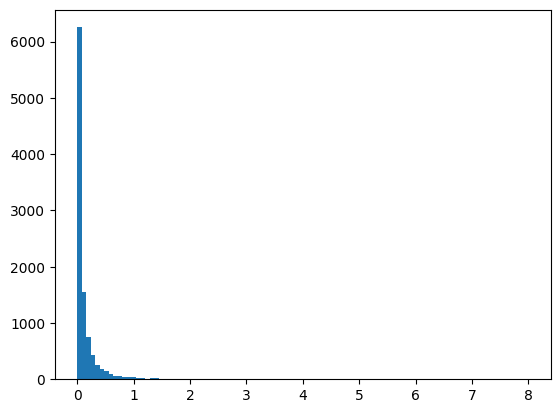

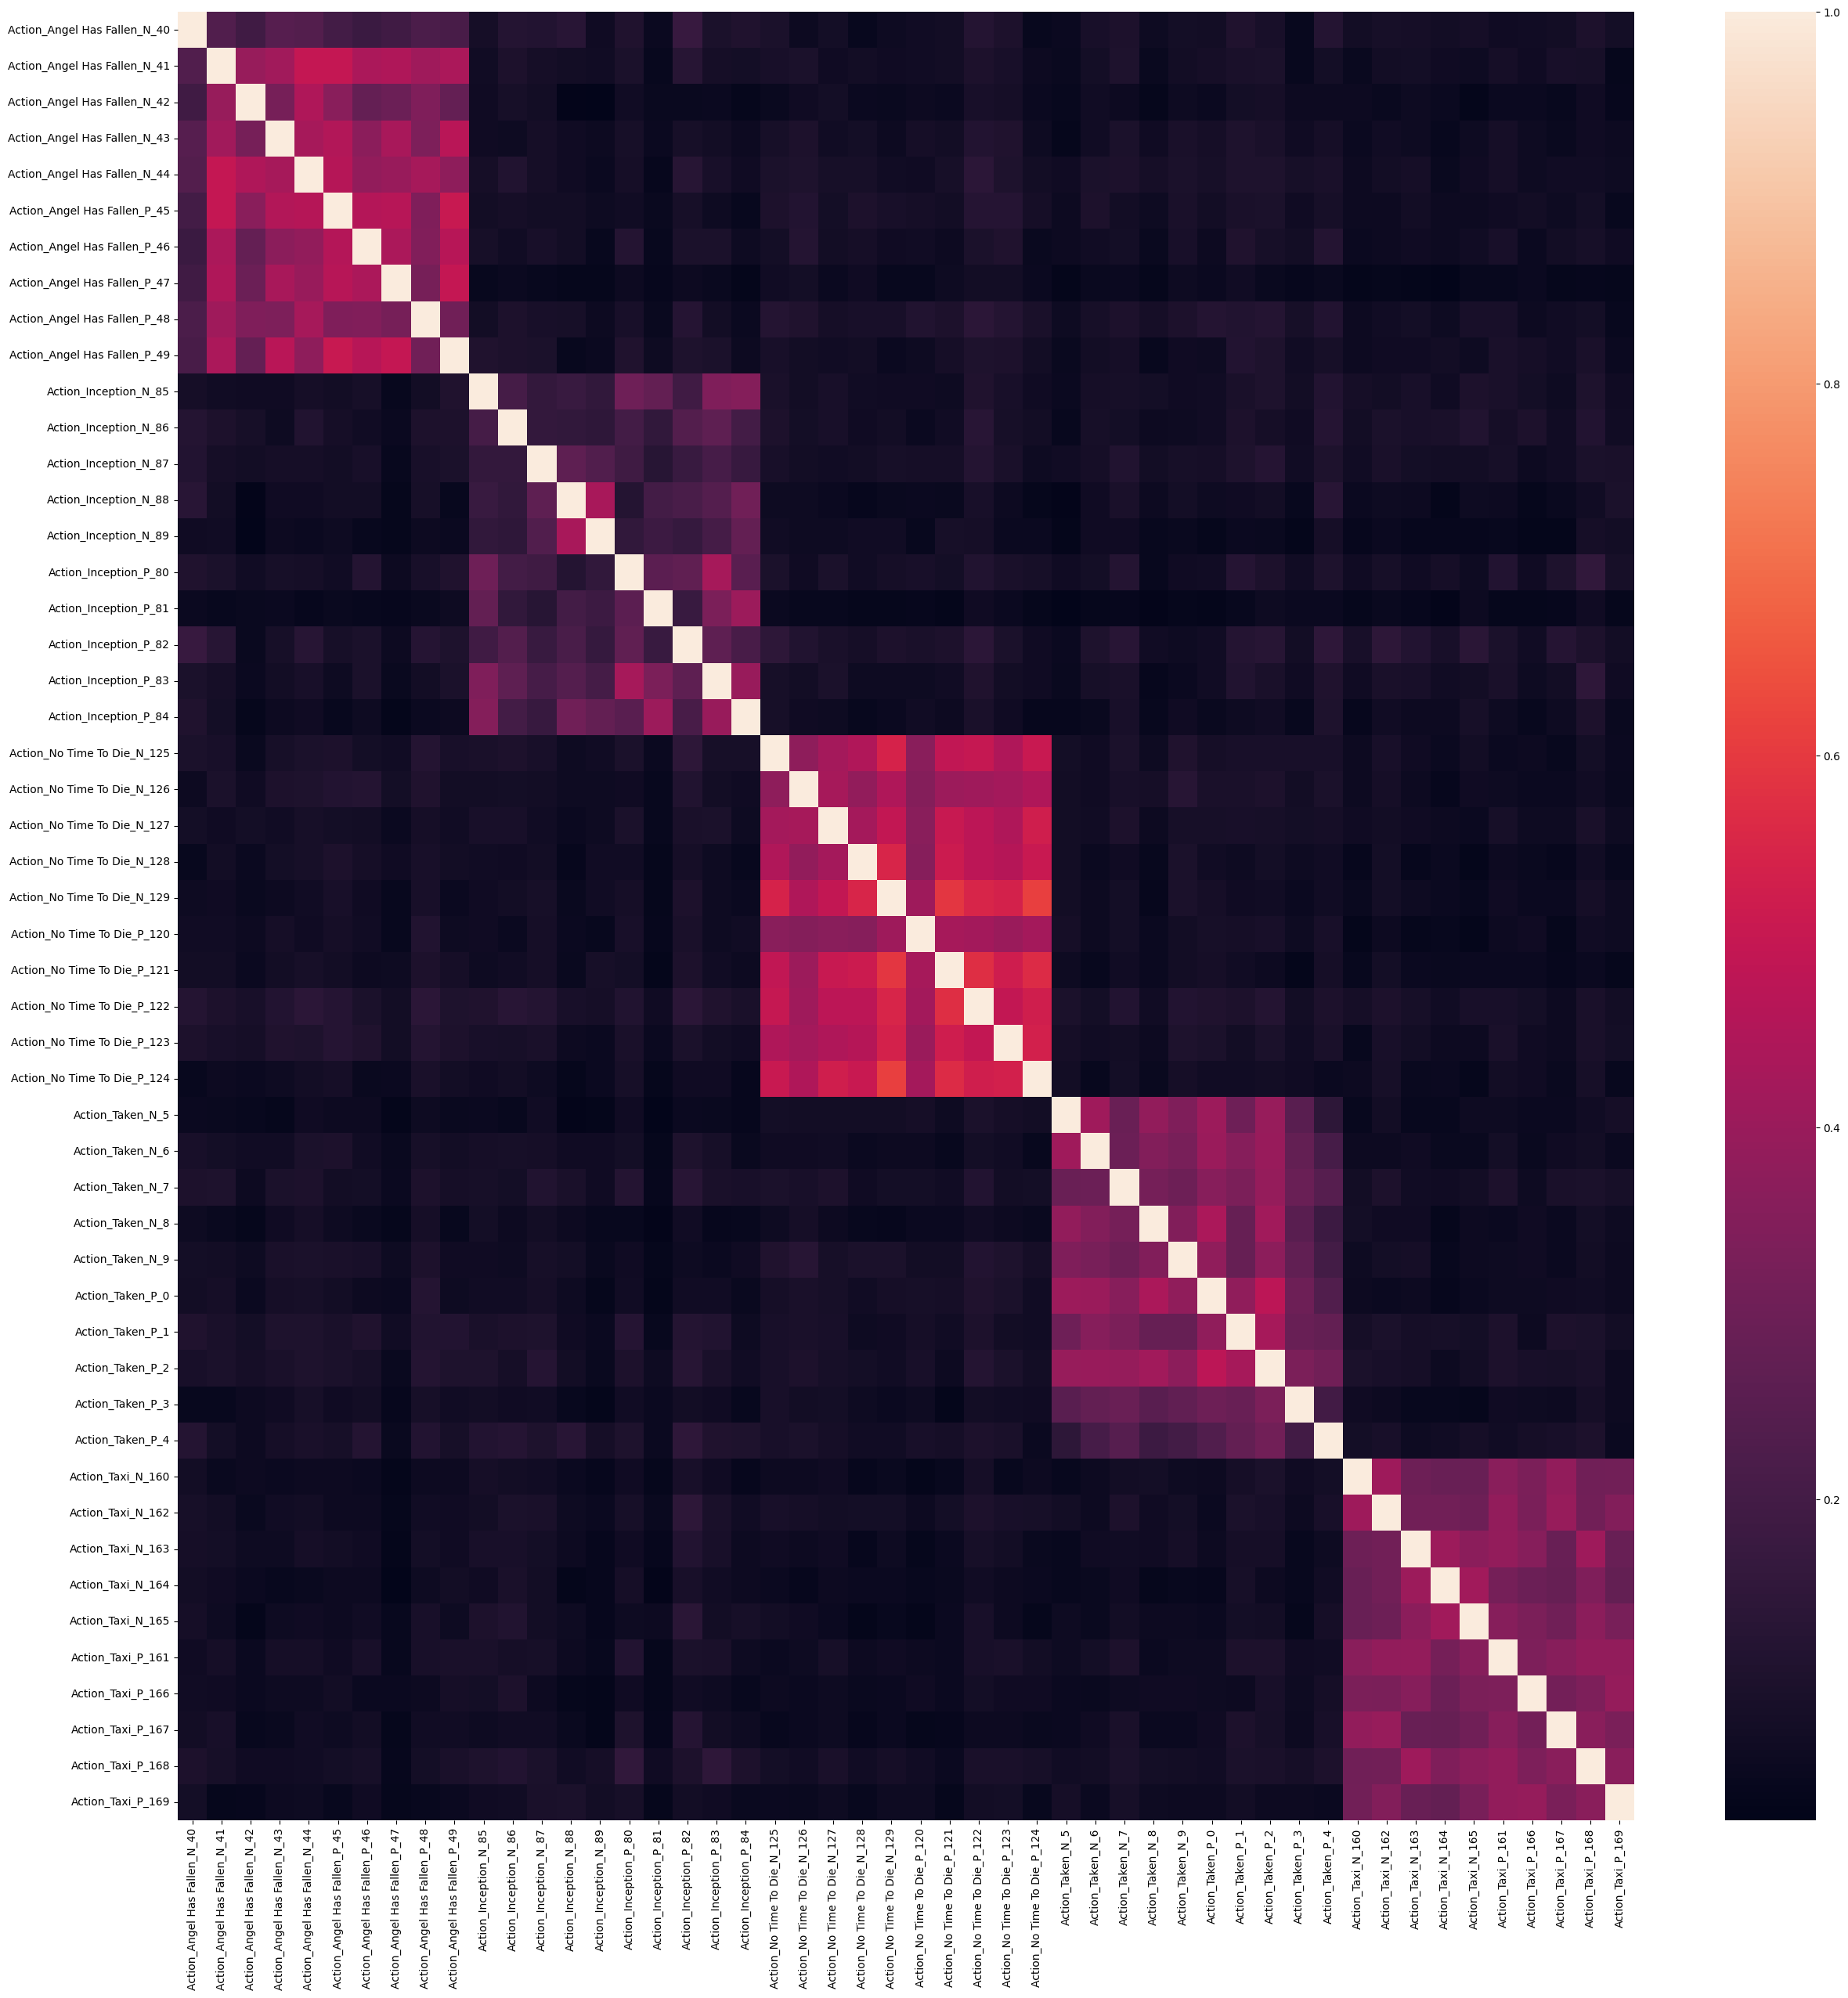

,aaron,ab,abandon,abduct,abductor,abdul,abel,aberr,abet,abigail,...,zippi,zippier,zoey,zombi,zone,zonk,zoom,zora,is_casino_royale,is_action
Doc_ID,,,,,,,,,,,,,,,,,,,,,
40,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,False,True
41,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,False,True
42,0.00,0.00,3.60,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,False,True
43,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,False,True
44,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
190,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,False,False
193,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,False,False
194,0.00,0.00,3.60,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,False,False


In [ ]:
run_tfidf(documents, clean_method, important_prevalent_terms, 'TFIDF_exp')

,Mean TF-IDF
film,5.74
movi,4.76
ha,3.59
wa,3.41
one,3.36
like,3.10
bond,3.08
time,2.66
make,2.59
get,2.48


Vocabulary size: 10073


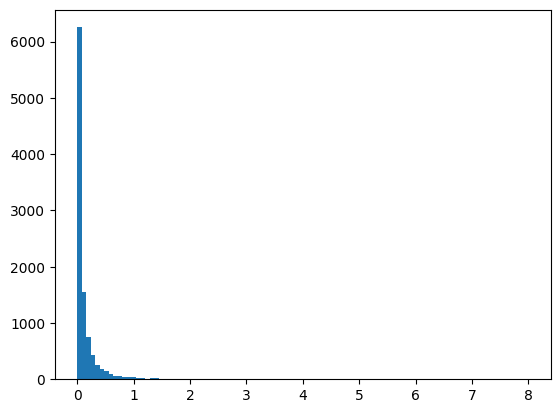

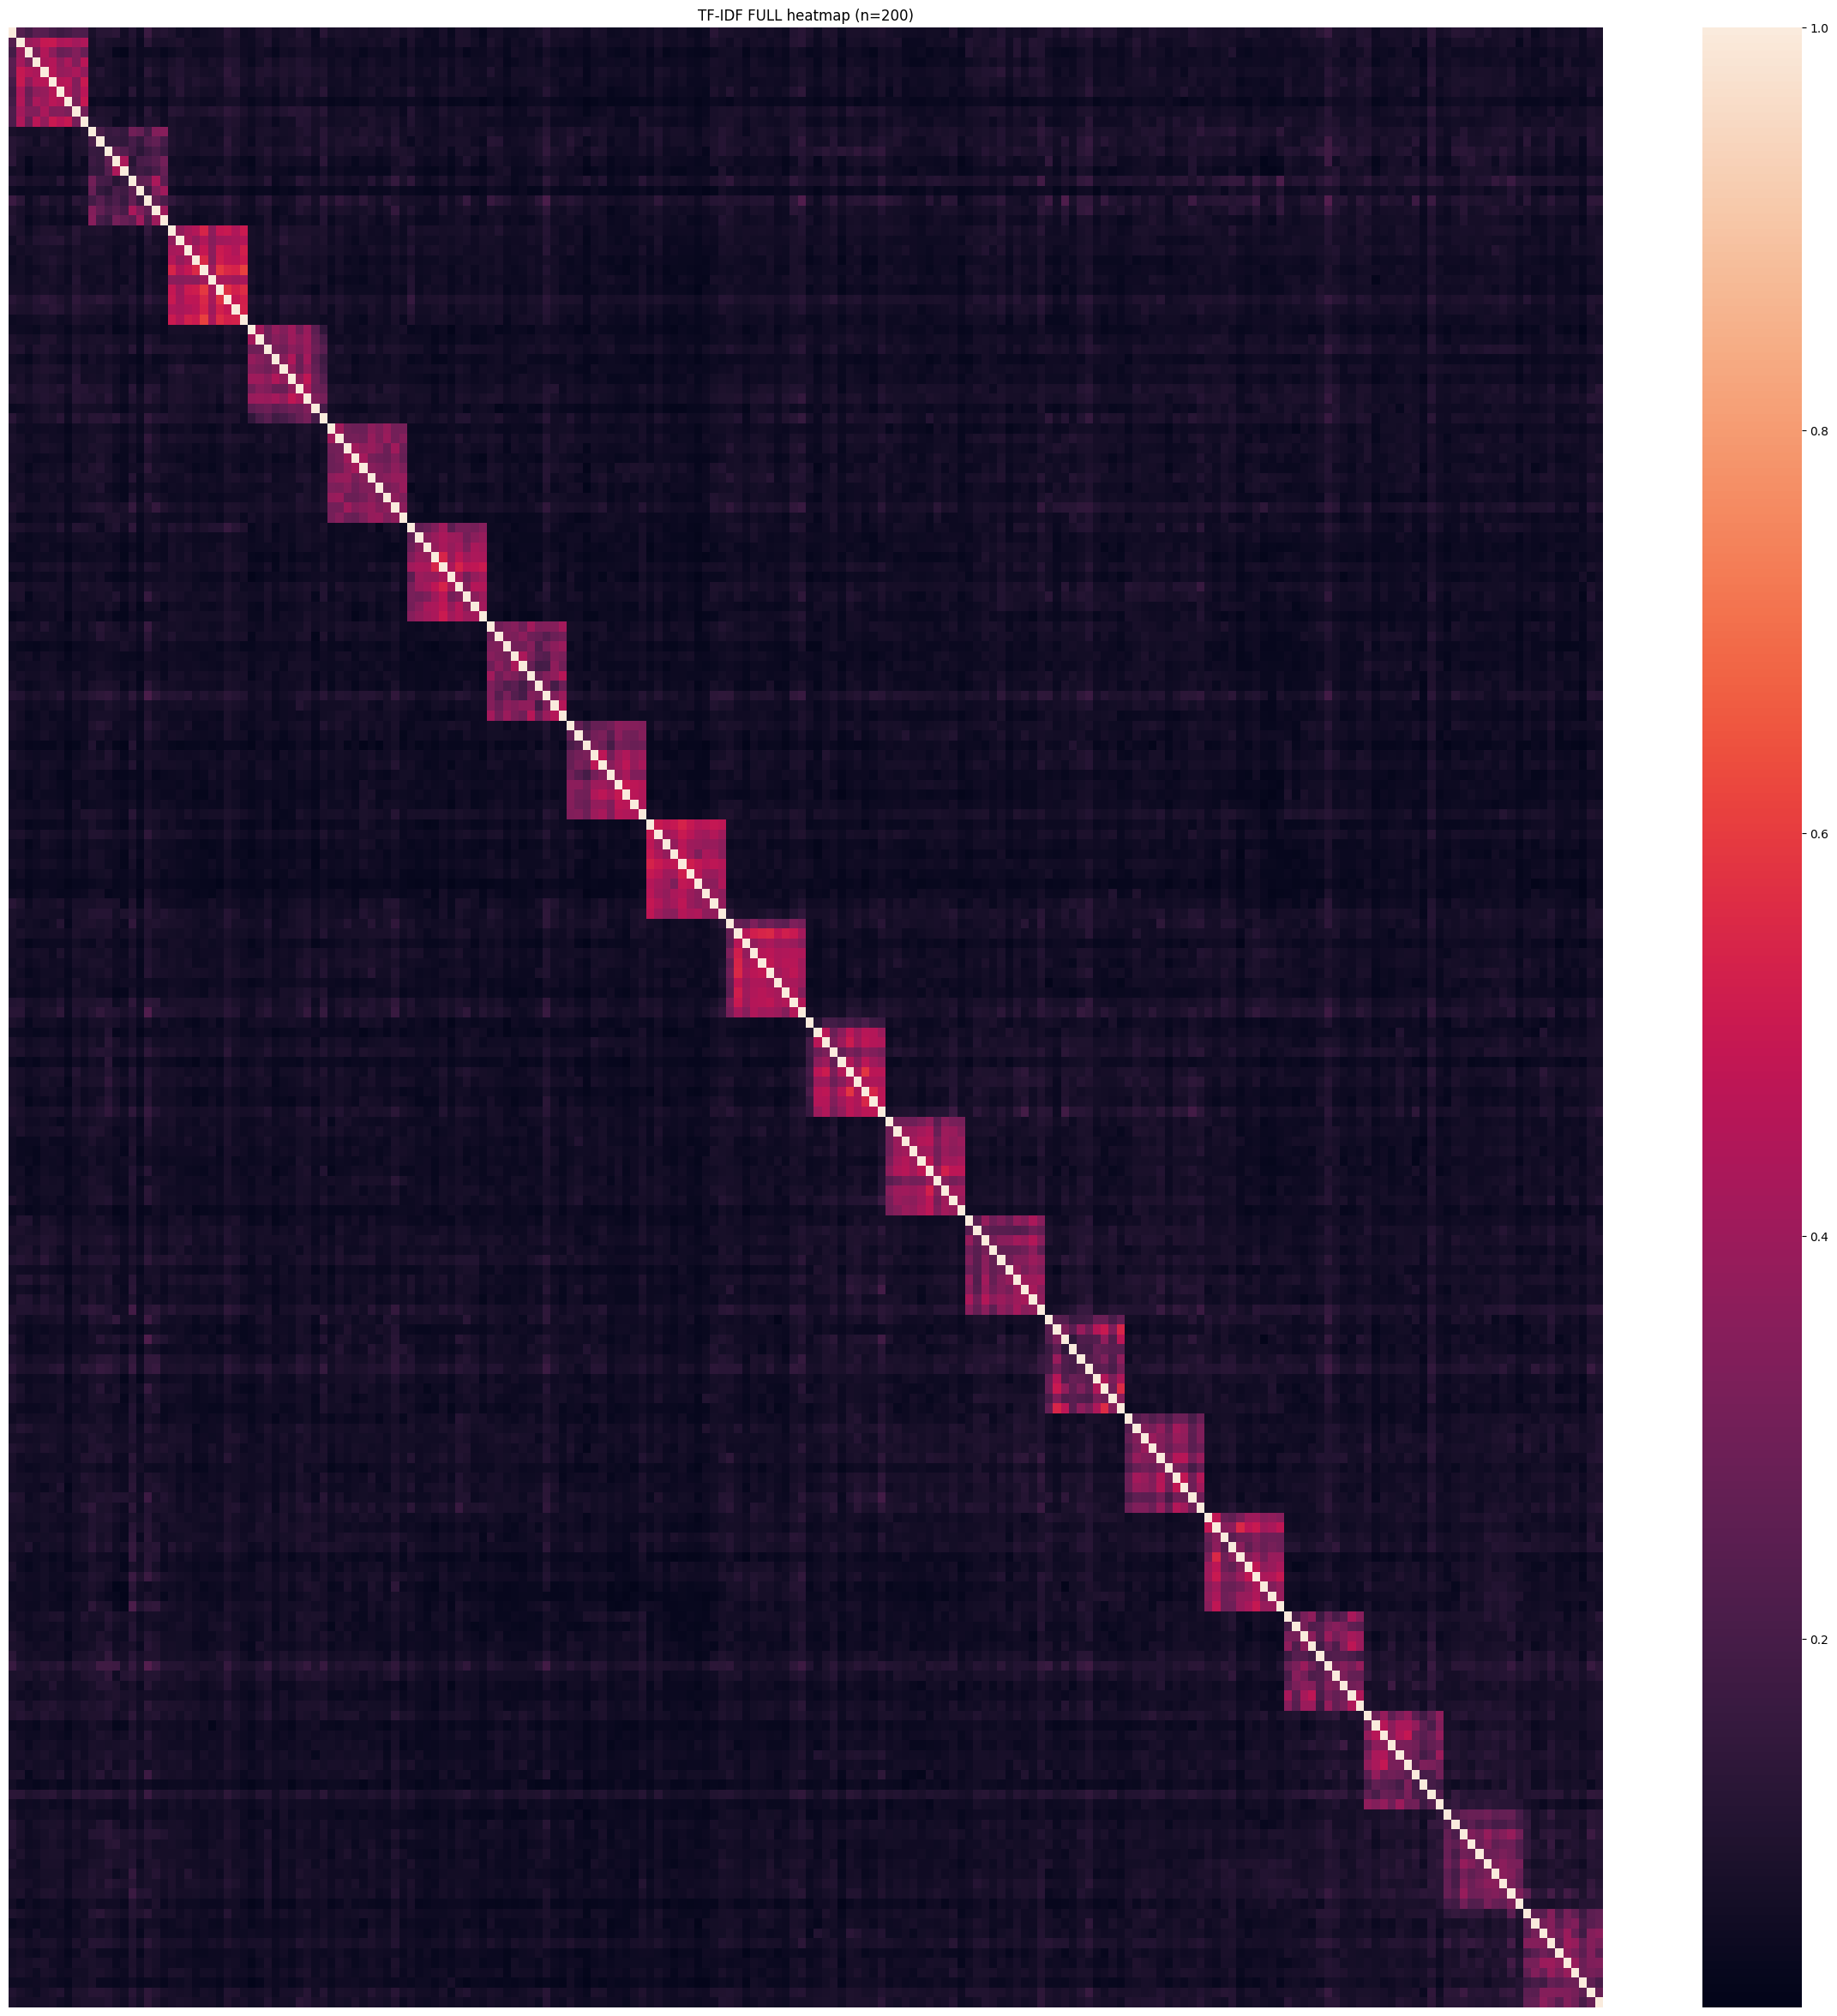

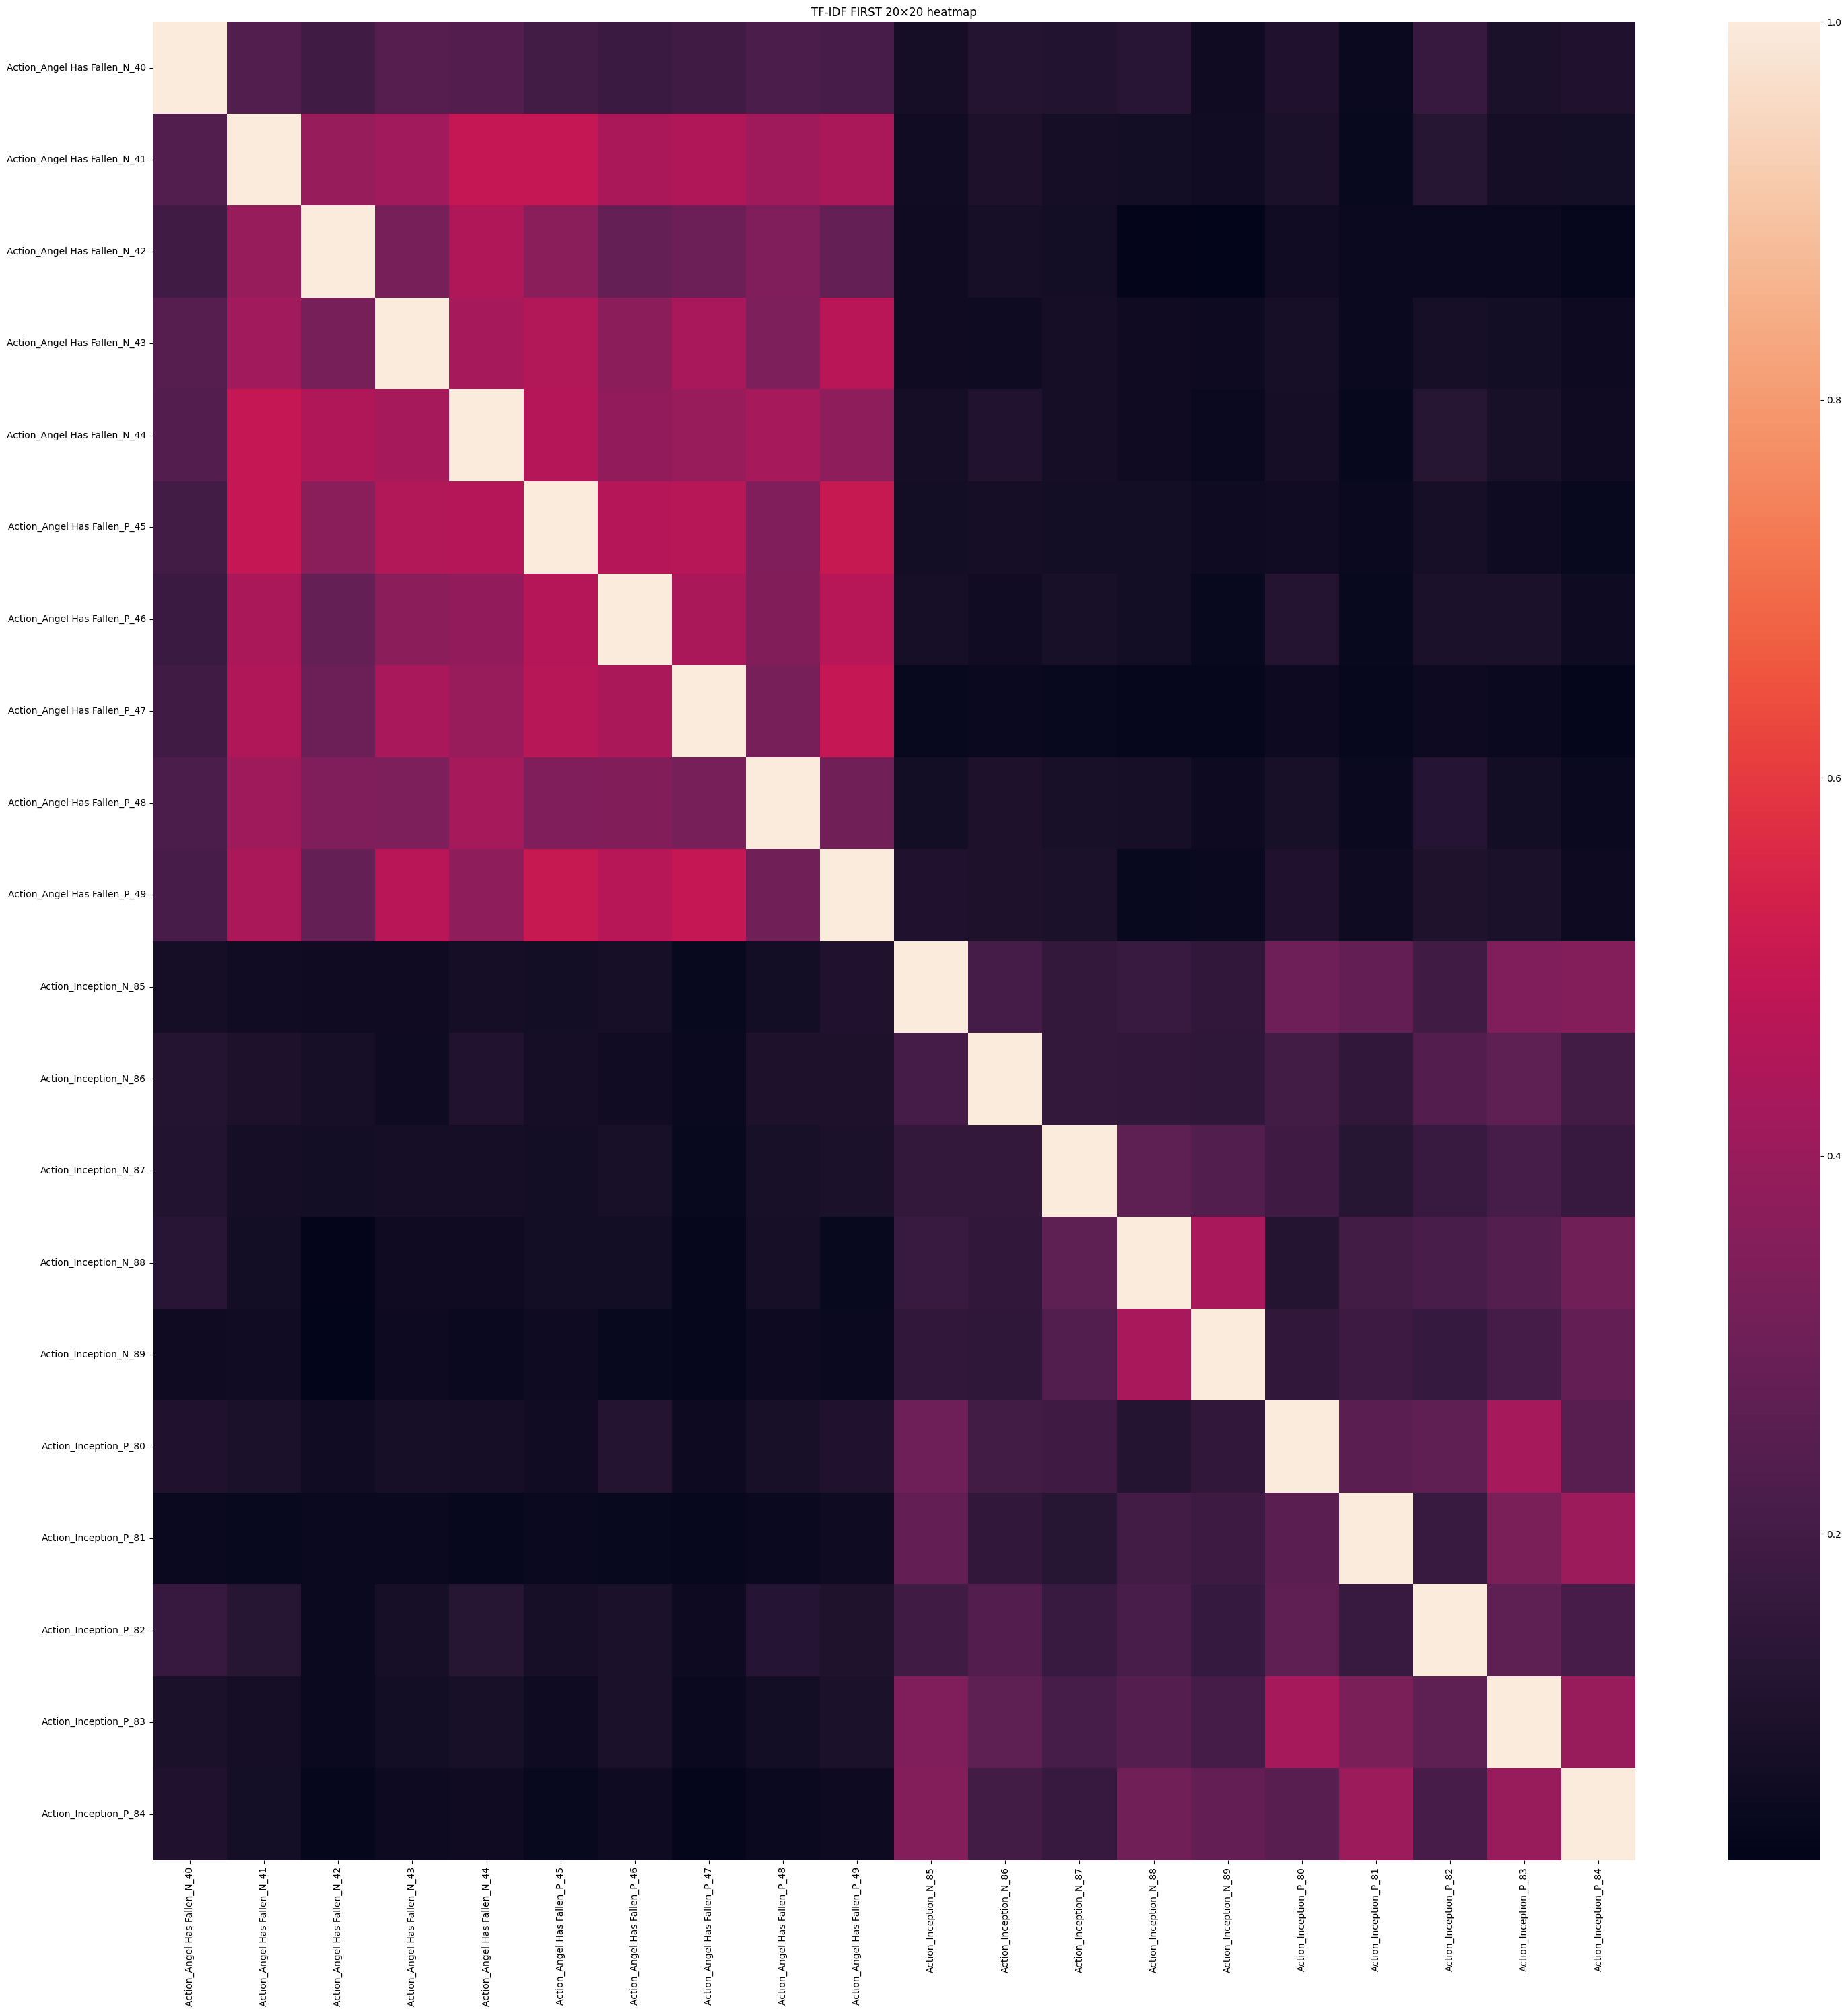

In [ ]:
# NEW: Show full n x n (200 x 200) and 20 x 20 heatmap

# build once, suppress the internal 50×50 so we don’t double-plot
doc_term_df = run_tfidf(documents, clean_method, important_prevalent_terms, 'TFIDF_exp',
                        plot_action_heatmap=False)

# FULL n x n
full_sim = cosine_similarity(doc_term_df, doc_term_df)
fig, ax = plt.subplots(figsize=(30, 30))
sns.heatmap(ax=ax, data=full_sim, xticklabels=False, yticklabels=False)
ax.set_title(f"TF-IDF FULL heatmap (n={doc_term_df.shape[0]})")
plt.show()

# FIRST 20 x FIRST 20
first_ids = list(doc_term_df.index)[:min(20, doc_term_df.shape[0])]
sub_sim = cosine_similarity(doc_term_df.loc[first_ids], doc_term_df.loc[first_ids])
labels_20 = [descriptors_by_doc_ids.get(doc_id, str(doc_id)) for doc_id in first_ids]

fig, ax = plt.subplots(figsize=(30, 30))
sns.heatmap(ax=ax, data=sub_sim, xticklabels=labels_20, yticklabels=labels_20)
ax.set_title("TF-IDF FIRST 20×20 heatmap")
plt.xticks(rotation=90); plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

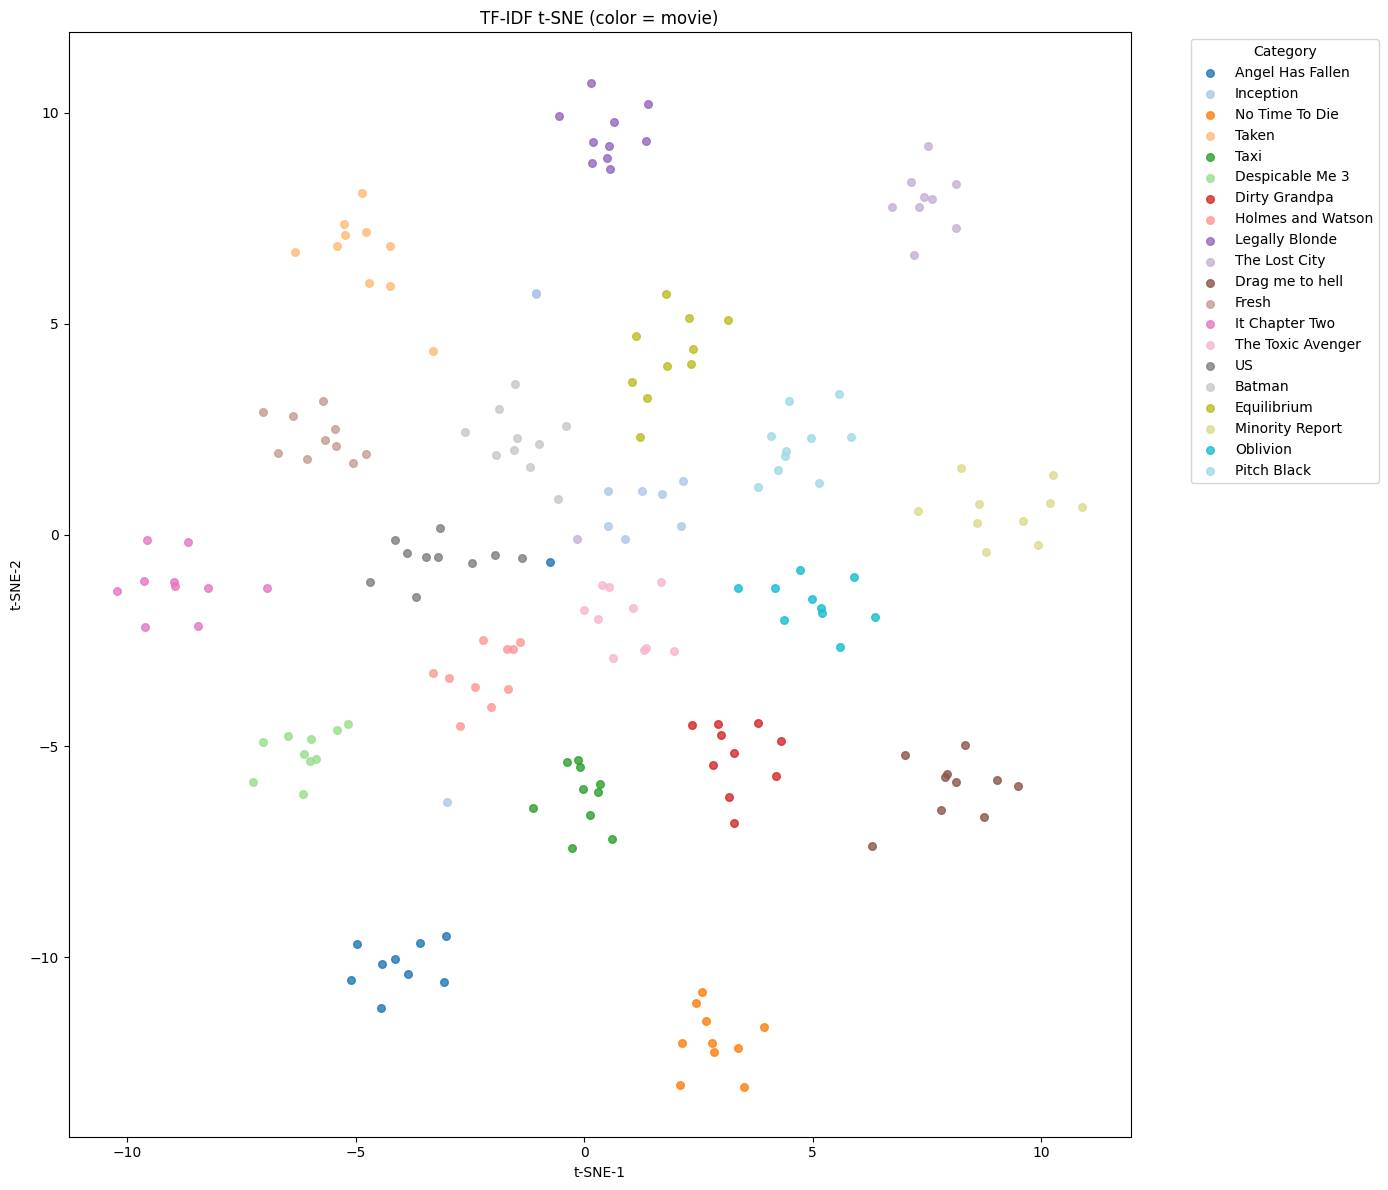

In [ ]:
# NEW: t-SNE visualization for documents colored by movie

# tfidf_doc_df_for_tsne = doc_term_df.copy()
# movie_series = pd.Series({i: titles_by_doc_ids[i] for i in tfidf_doc_df_for_tsne.index})
# plot_tsne_by_category(tfidf_doc_df_for_tsne, movie_series, experiment_name="TFIDF_TSNE_by_movie")

tfidf_doc_df_for_tsne = doc_term_df.copy()  # rows=docs, cols=terms
movie_series = pd.Series({i: titles_by_doc_ids[i] for i in tfidf_doc_df_for_tsne.index})
unused_return_result= plot_tsne_by_category(tfidf_doc_df_for_tsne, movie_series, title="TF-IDF t-SNE (color = movie)")
# ^- unused_return_result prevents large array from being printed out in notebook

## Word2Vec

<div class="alert alert-block alert-success">
    <b>Word2vec embeddings</b>: https://radimrehurek.com/gensim/models/word2vec.html <br>
    This module implements the word2vec family of algorithms, using highly optimized C routines, data streaming and Pythonic interfaces.
            </div>

## Utility Functions For Word2Vec Experiments

In [ ]:
def get_word2vec_vectors(documents: List[TokenizedDocument], embedding_size: int) -> pd.DataFrame:
    tokens = [x.tokens for x in documents]

    word2vec_model = Word2Vec(sentences=tokens, vector_size=embedding_size, window=3, min_count=1, workers=12)

    vectors = {}
    for i in word2vec_model.wv.index_to_key:
        temp_vec = word2vec_model.wv[i]
        vectors[i] = temp_vec

    result = pd.DataFrame(vectors).transpose()
    result = result.sort_index()
    return result

def plot_similarity_matrix(data: pd.DataFrame, experiment_name: str, figsize=(25, 25)):
    similarities = cosine_similarity(data, data)
    fig, ax = plt.subplots(figsize=figsize)
    sns.heatmap(ax=ax, data=similarities, xticklabels=data.index, yticklabels=data.index);
    #plt.savefig(f'figures/{experiment_name}_heatmap.png')
    plt.close()

def plot_similarity_clustermap(data: pd.DataFrame, experiment_name: str, figsize=(25, 25)):
    similarities = cosine_similarity(data, data)
    cm = sns.clustermap(similarities, metric='cosine', xticklabels=data.index, yticklabels=data.index, method='complete', cmap='RdBu', figsize=figsize)
    cm.ax_row_dendrogram.set_visible(False)
    cm.ax_col_dendrogram.set_visible(False)
    plt.legend(loc='upper left')
    #plt.savefig(f'figures/{experiment_name}_clustermap.png')
    plt.show()
    plt.close()

def plot_tsne(data: pd.DataFrame, perplexity: int, experiment_name: str, figsize=(40, 40)):
    """
    Creates a TSNE plot of the supplied dataframe
    """
    tsne_model = TSNE(perplexity=perplexity, n_components=2, learning_rate='auto', init='pca', n_iter=1000, random_state=32)
    new_values = tsne_model.fit_transform(data)

    x = []
    y = []
    for value in new_values:
        x.append(value[0])
        y.append(value[1])

    plt.figure(figsize=figsize)
    labels = list(data.index)
    for i in range(len(x)):
        new_value = new_values[i]
        x = new_value[0]
        y = new_value[1]

        plt.scatter(x, y)
        plt.annotate(labels[i],
                     xy=(x, y),
                     xytext=(5, 2),
                     textcoords='offset points',
                     ha='right',
                     va='bottom')
    #plt.savefig(f'figures/{experiment_name}_tsne.png')
    plt.show()
    plt.close()

def run_word2vec_experiment(documents: List[Document],
                            clean_func: Callable[[List[Document]], List[TokenizedDocument]],
                            embedding_size: int,
                            chosen_tokens: List[str],
                            experiment_name: str):
    cleaned_documents = clean_func(documents)

    word2vec_df = get_word2vec_vectors(cleaned_documents, embedding_size)
    filtered_word2vec_df = word2vec_df.loc[chosen_tokens].copy()

    plot_tsne(filtered_word2vec_df, 30, experiment_name)
    plot_similarity_matrix(filtered_word2vec_df, experiment_name)
    plot_similarity_clustermap(filtered_word2vec_df, experiment_name)

In [ ]:
from collections import Counter
import nltk

def _ensure_pos_tagger():
    try:
        nltk.pos_tag(["ok"])
    except LookupError:
        for res in ("averaged_perceptron_tagger_eng", "averaged_perceptron_tagger"):
            try:
                nltk.download(res, quiet=True)
                nltk.pos_tag(["ok"])
                break
            except Exception:
                pass

def select_tokens_for_word2vec(strategy: str = "most_common", top_k: int = 50):
    """
    Simple control flow, single return.
    - Always count tokens exactly as Word2Vec sees them (clean_method).
    - For 'nouns'/'verbs', filter those counts via POS, aligned to your W2V token form.
    """
    strategy = strategy.lower()

    # Count tokens in the exact form used by Word2Vec
    cleaned = clean_method(documents)  # List[TokenizedDocument]
    w2v_tokens = [tok for d in cleaned for tok in d.tokens]
    counts = Counter(w2v_tokens)

    # Decide what to include
    if strategy == "most_common":
        # No filtering; use all tokens and rank by frequency
        filtered = list(counts.items())

    elif strategy in ("nouns", "verbs"):
        _ensure_pos_tagger()

        # Flatten all tokens for tagging; keep words longer than 2 chars
        raw_tokens = [w for td in tokenize_documents(normalize_documents(documents)) for w in td.tokens if len(w) > 2]
        # ^ flattens token lists from all docs into one list; filters out super-short strings

        # Pick POS family
        if strategy == "nouns":
            want = "NN"  # matches NN, NNS, NNP, NNPS
        else:
            want = "VB"  # matches VB, VBD, VBG, VBN, VBP, VBZ

        tagged = nltk.pos_tag(raw_tokens)
        pos_kept = [w for (w, tag) in tagged if tag.startswith(want)]
        # ^ keeps only words whose POS tag starts with the wanted prefix

        # Align POS-selected words to your W2V token form (lemmatize -> stem)
        aligned_doc = stem(lemmatize([TokenizedDocument(-1, pos_kept)]))[0]
        allowed_tokens = aligned_doc.tokens

        # Keep only counted tokens that appear in the allowed list
        filtered = [(t, c) for (t, c) in counts.items() if t in allowed_tokens]

    else:
        raise ValueError("strategy must be 'most_common', 'nouns', or 'verbs'")

    # Rank and take top_k
    filtered.sort(key=lambda x: x[1], reverse=True)
    tokens = [t for t, _ in filtered[:top_k]]
    # ^ extracts just the token strings from the (token, count) pairs
    return tokens

In [ ]:
# NEW

TOP_K = 100 # number of tokens to print for these heat map and t-SNE charts

tokens_most_common = select_tokens_for_word2vec("most_common", TOP_K)
print(f"most_common: selected {len(tokens_most_common)} tokens -> {tokens_most_common[:10]}")

tokens_nouns = select_tokens_for_word2vec("nouns", TOP_K)
print(f"nouns: selected {len(tokens_nouns)} tokens -> {tokens_nouns[:10]}")

tokens_verbs = select_tokens_for_word2vec("verbs", TOP_K)
print(f"verbs: selected {len(tokens_verbs)} tokens -> {tokens_verbs[:10]}")

most_common: selected 100 tokens -> ['film', 'movi', 'ha', 'one', 'like', 'wa', 'time', 'make', 'get', 'go']
nouns: selected 100 tokens -> ['film', 'movi', 'one', 'like', 'time', 'make', 'get', 'go', 'charact', 'even']
verbs: selected 100 tokens -> ['film', 'ha', 'like', 'wa', 'time', 'make', 'get', 'go', 'charact', 'scene']


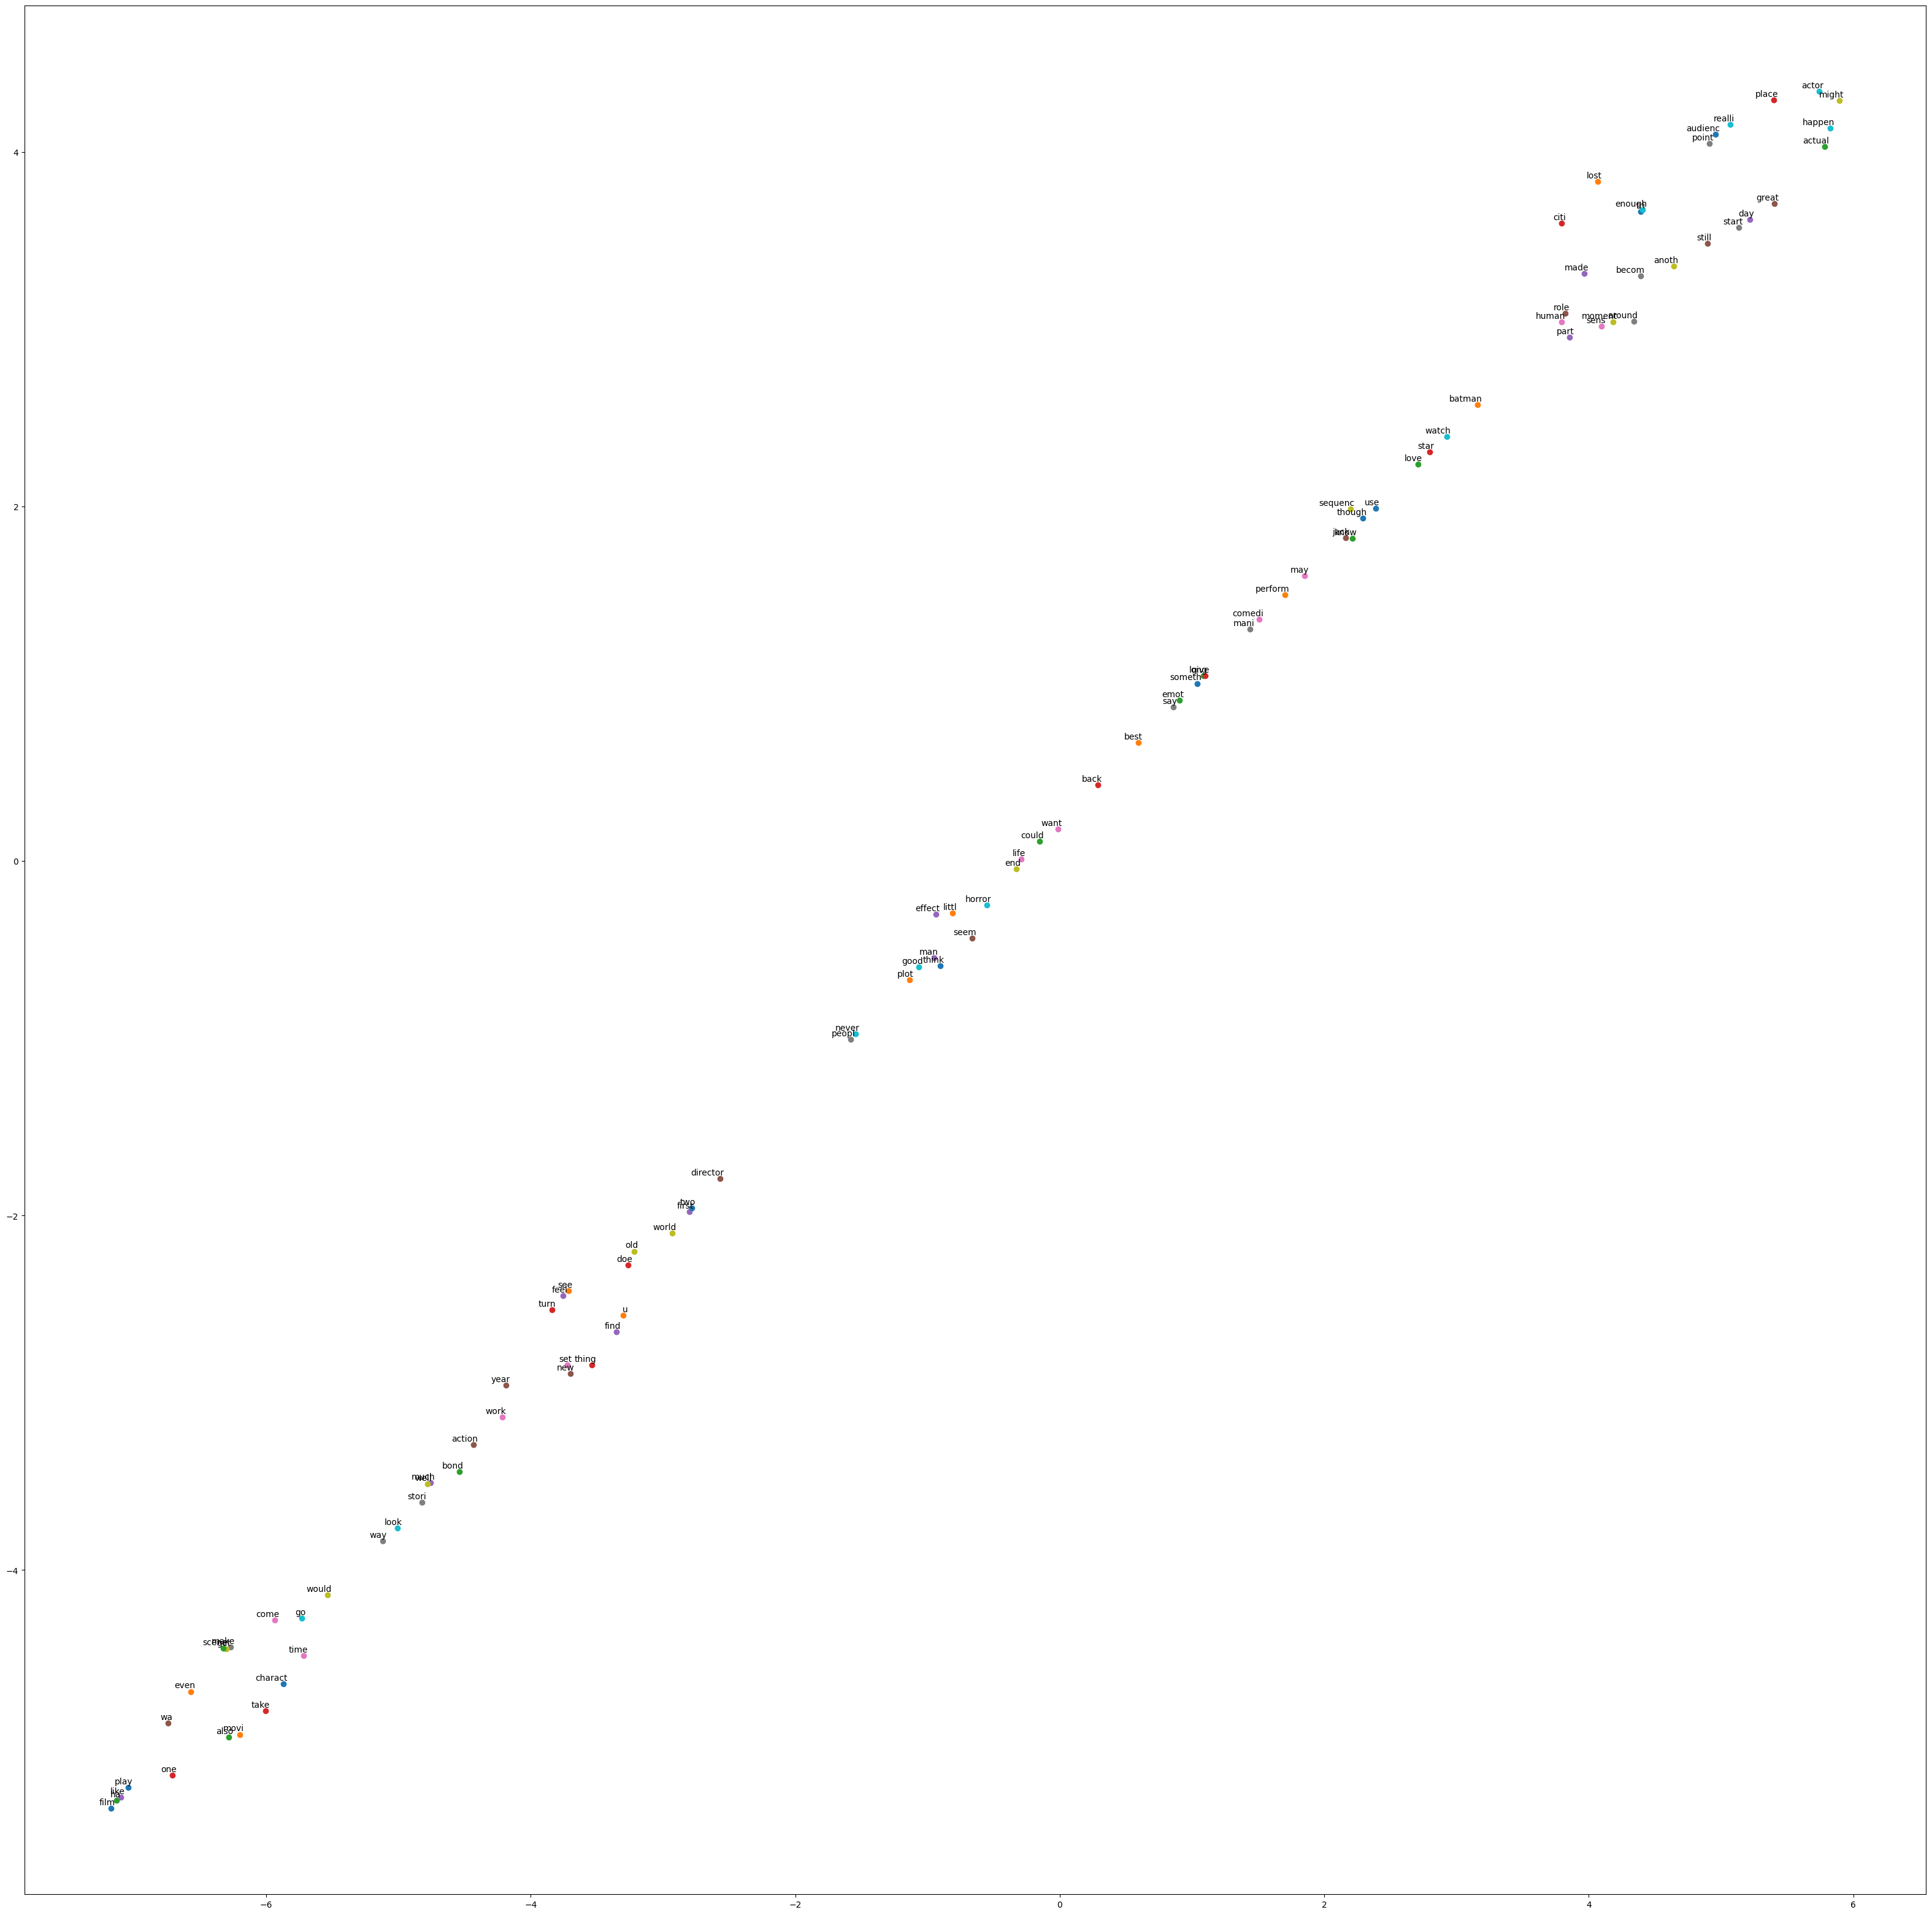

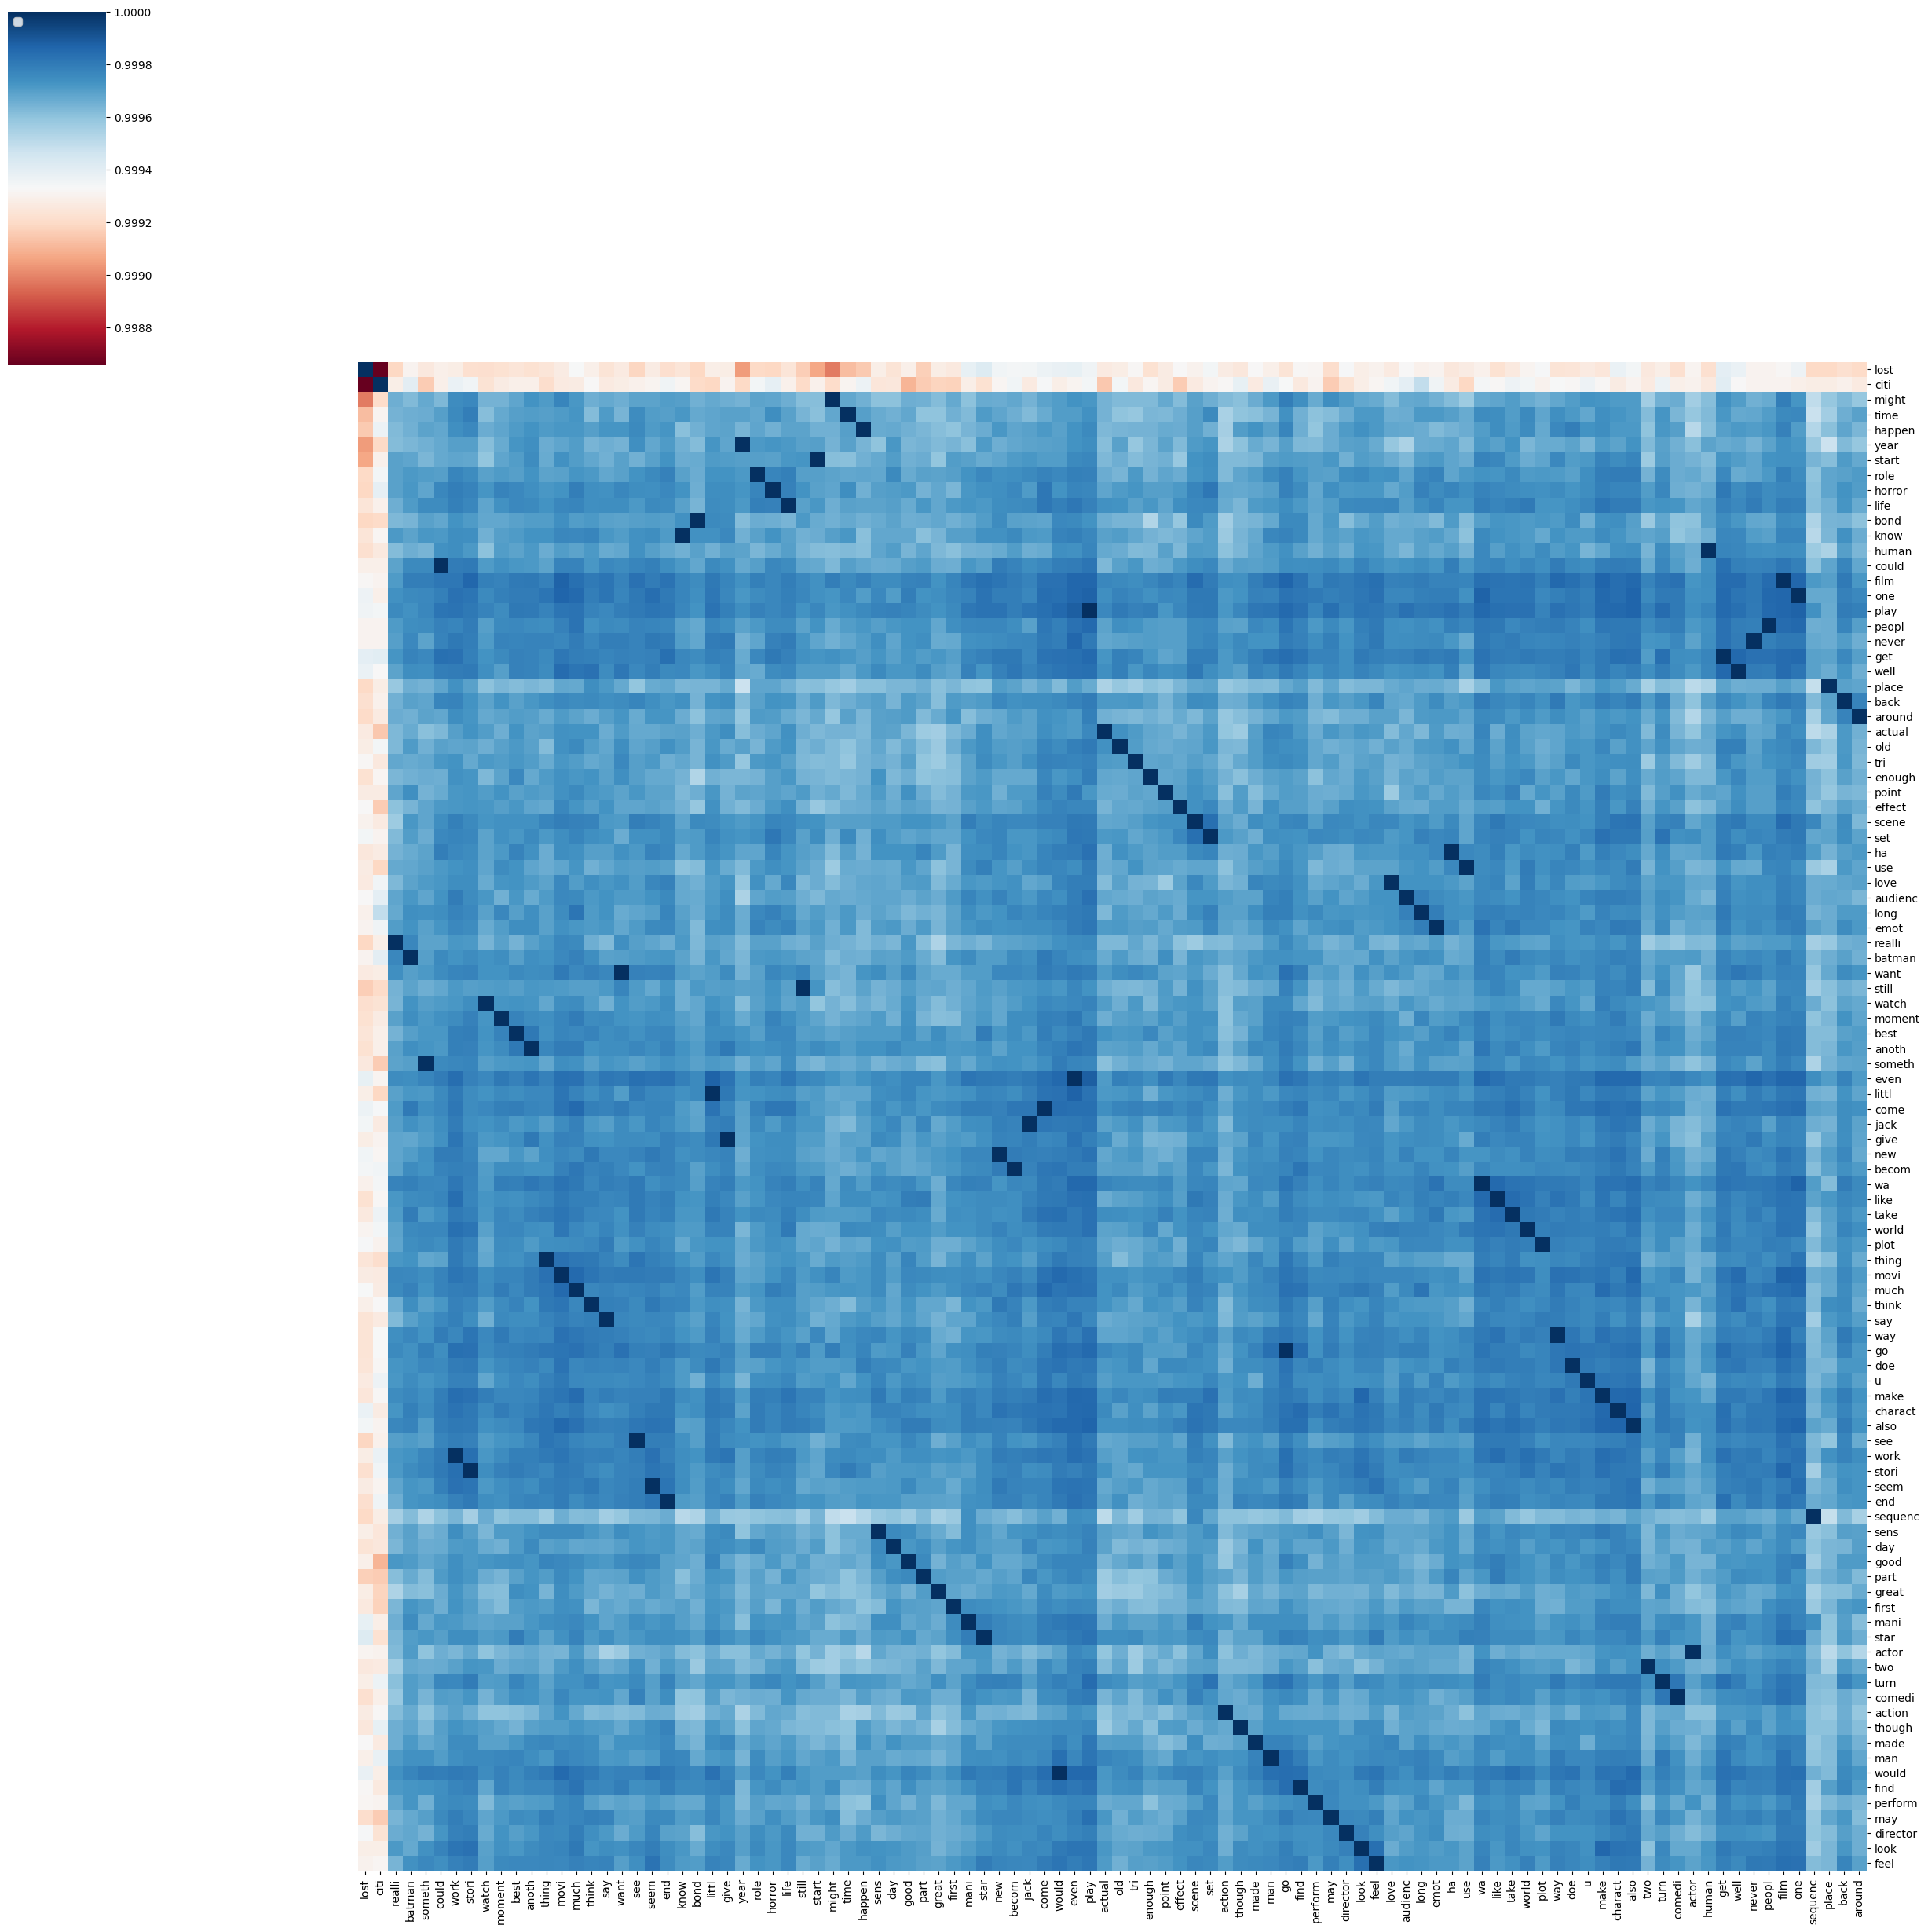

In [ ]:
# NEW: Word2Vec visualizations using meaningful subsets of 100 tokens
# MOST COMMON, NOUNS, VERBS

# most_common
run_word2vec_experiment(documents, clean_method, 100, tokens_most_common, "W2V_most_common_100d")

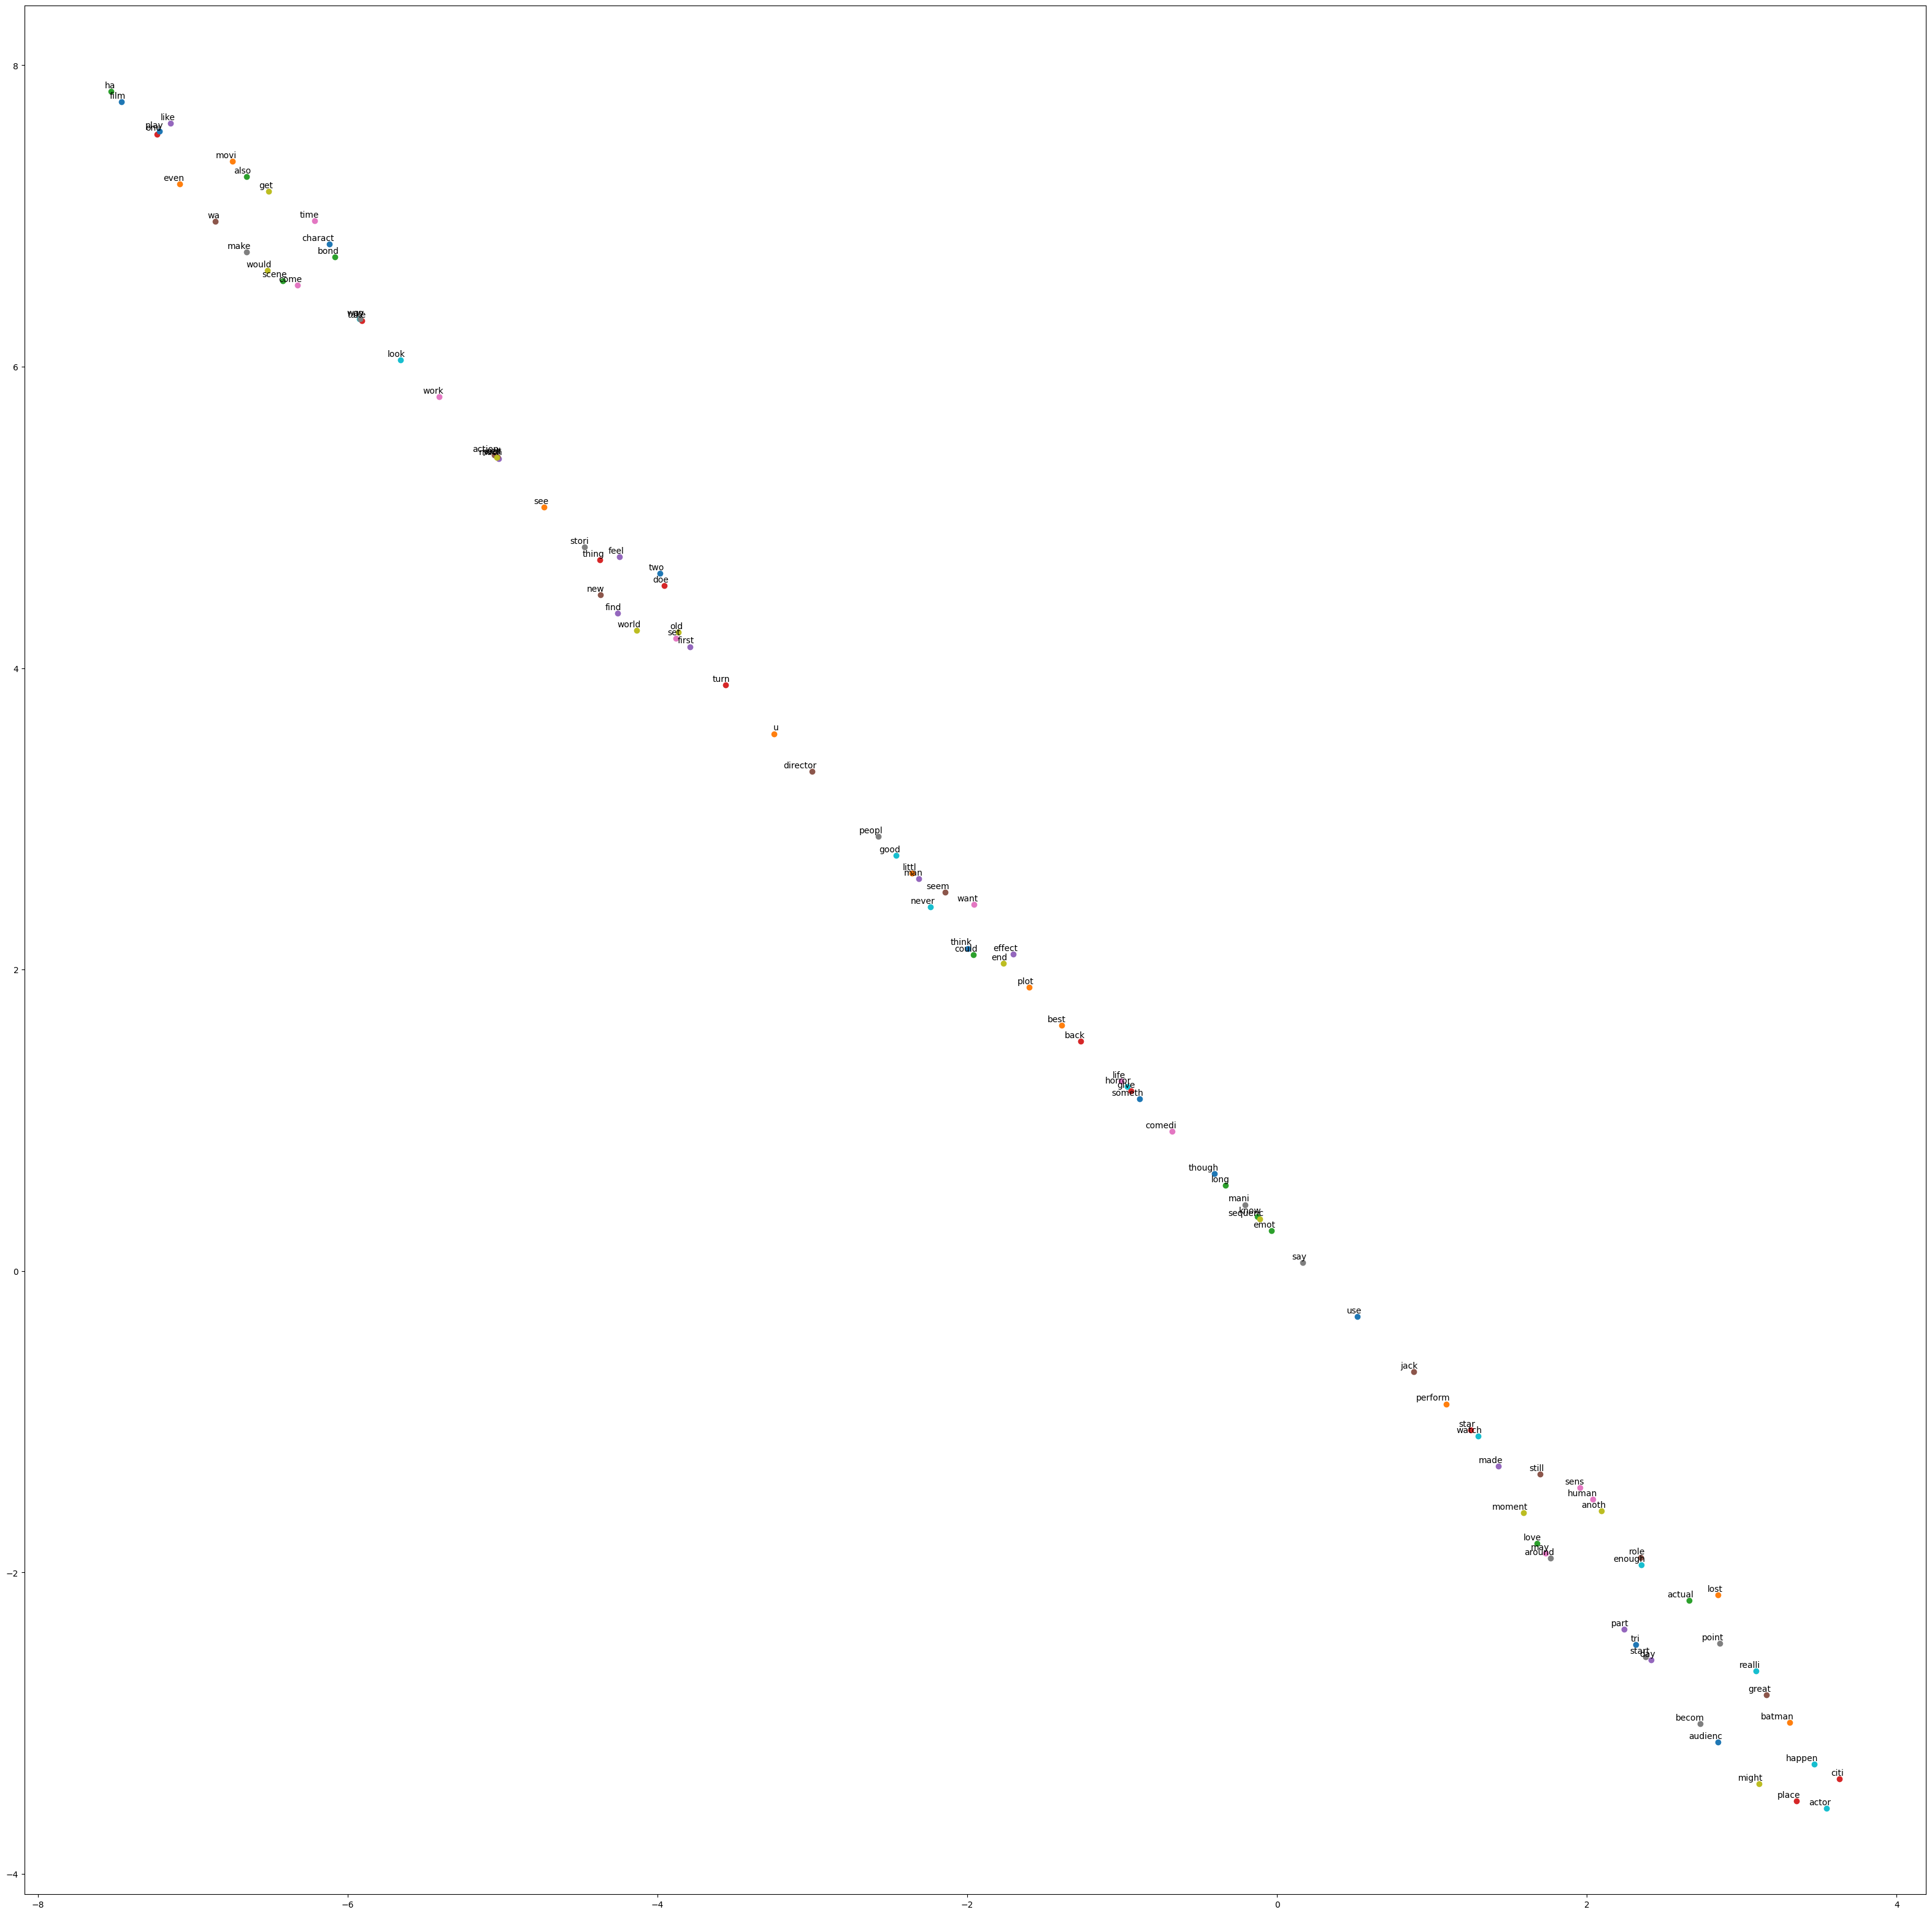

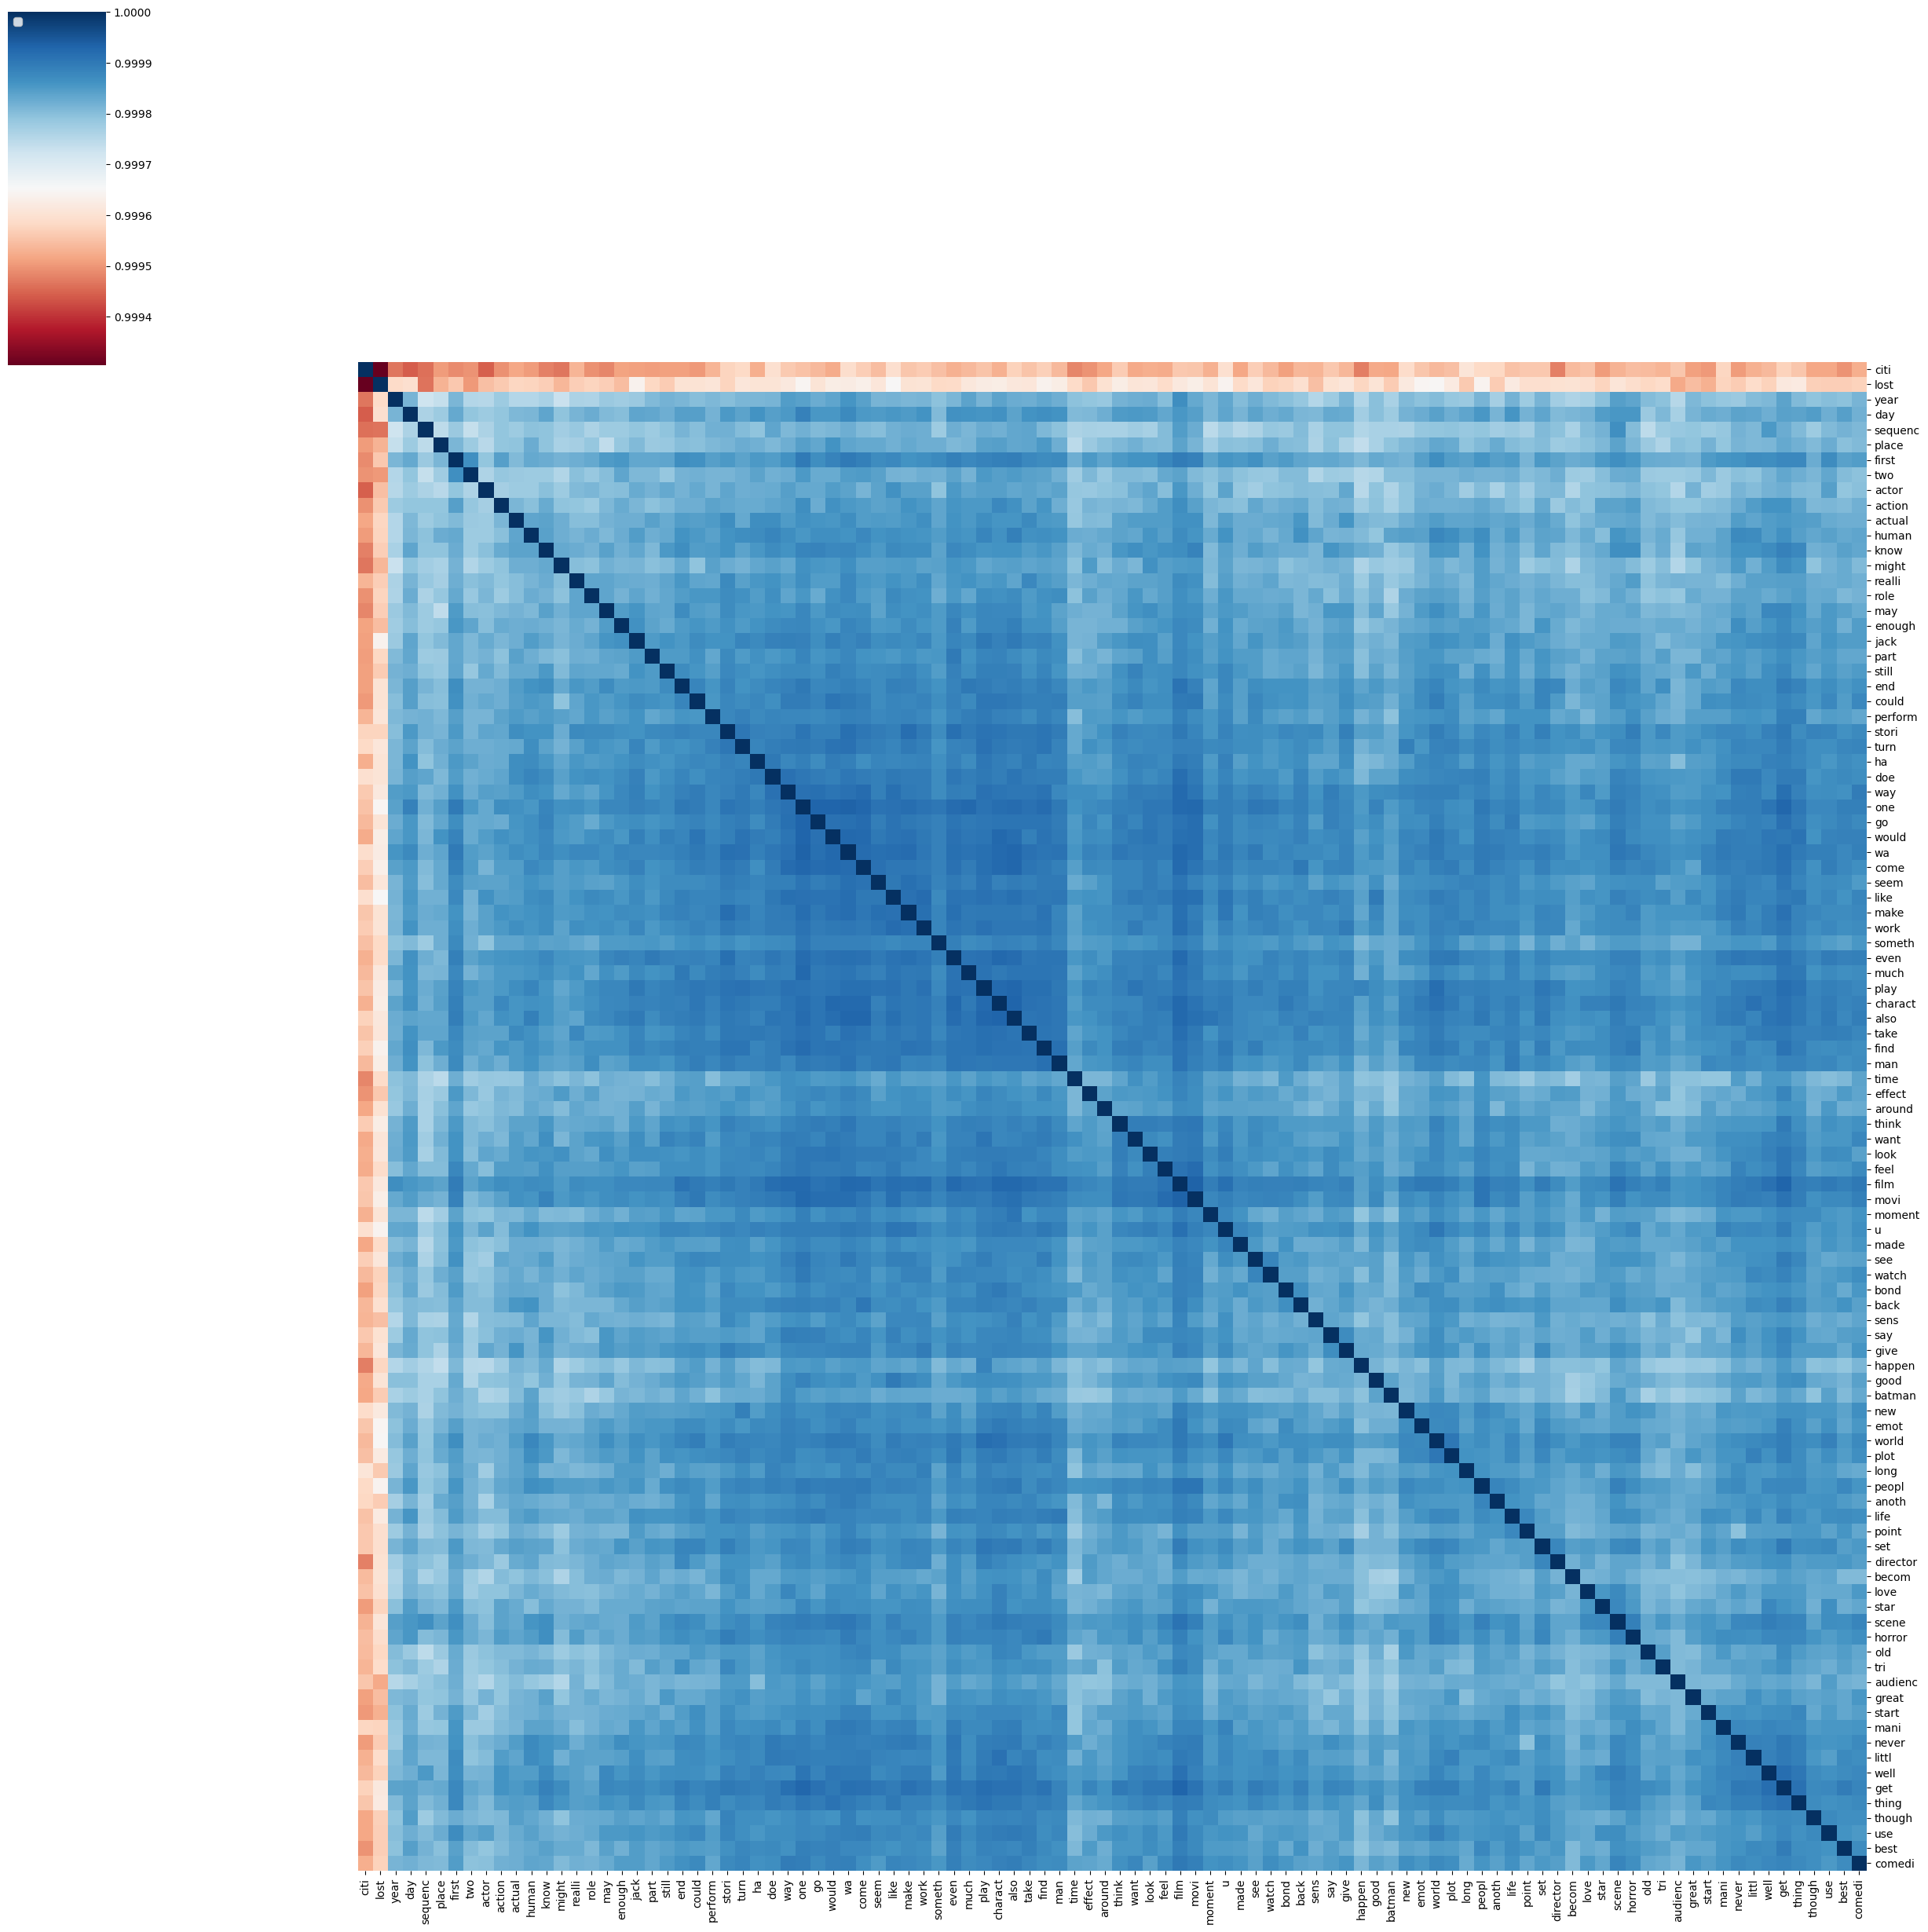

In [ ]:
run_word2vec_experiment(documents, clean_method, 200, tokens_most_common, "W2V_most_common_200d")

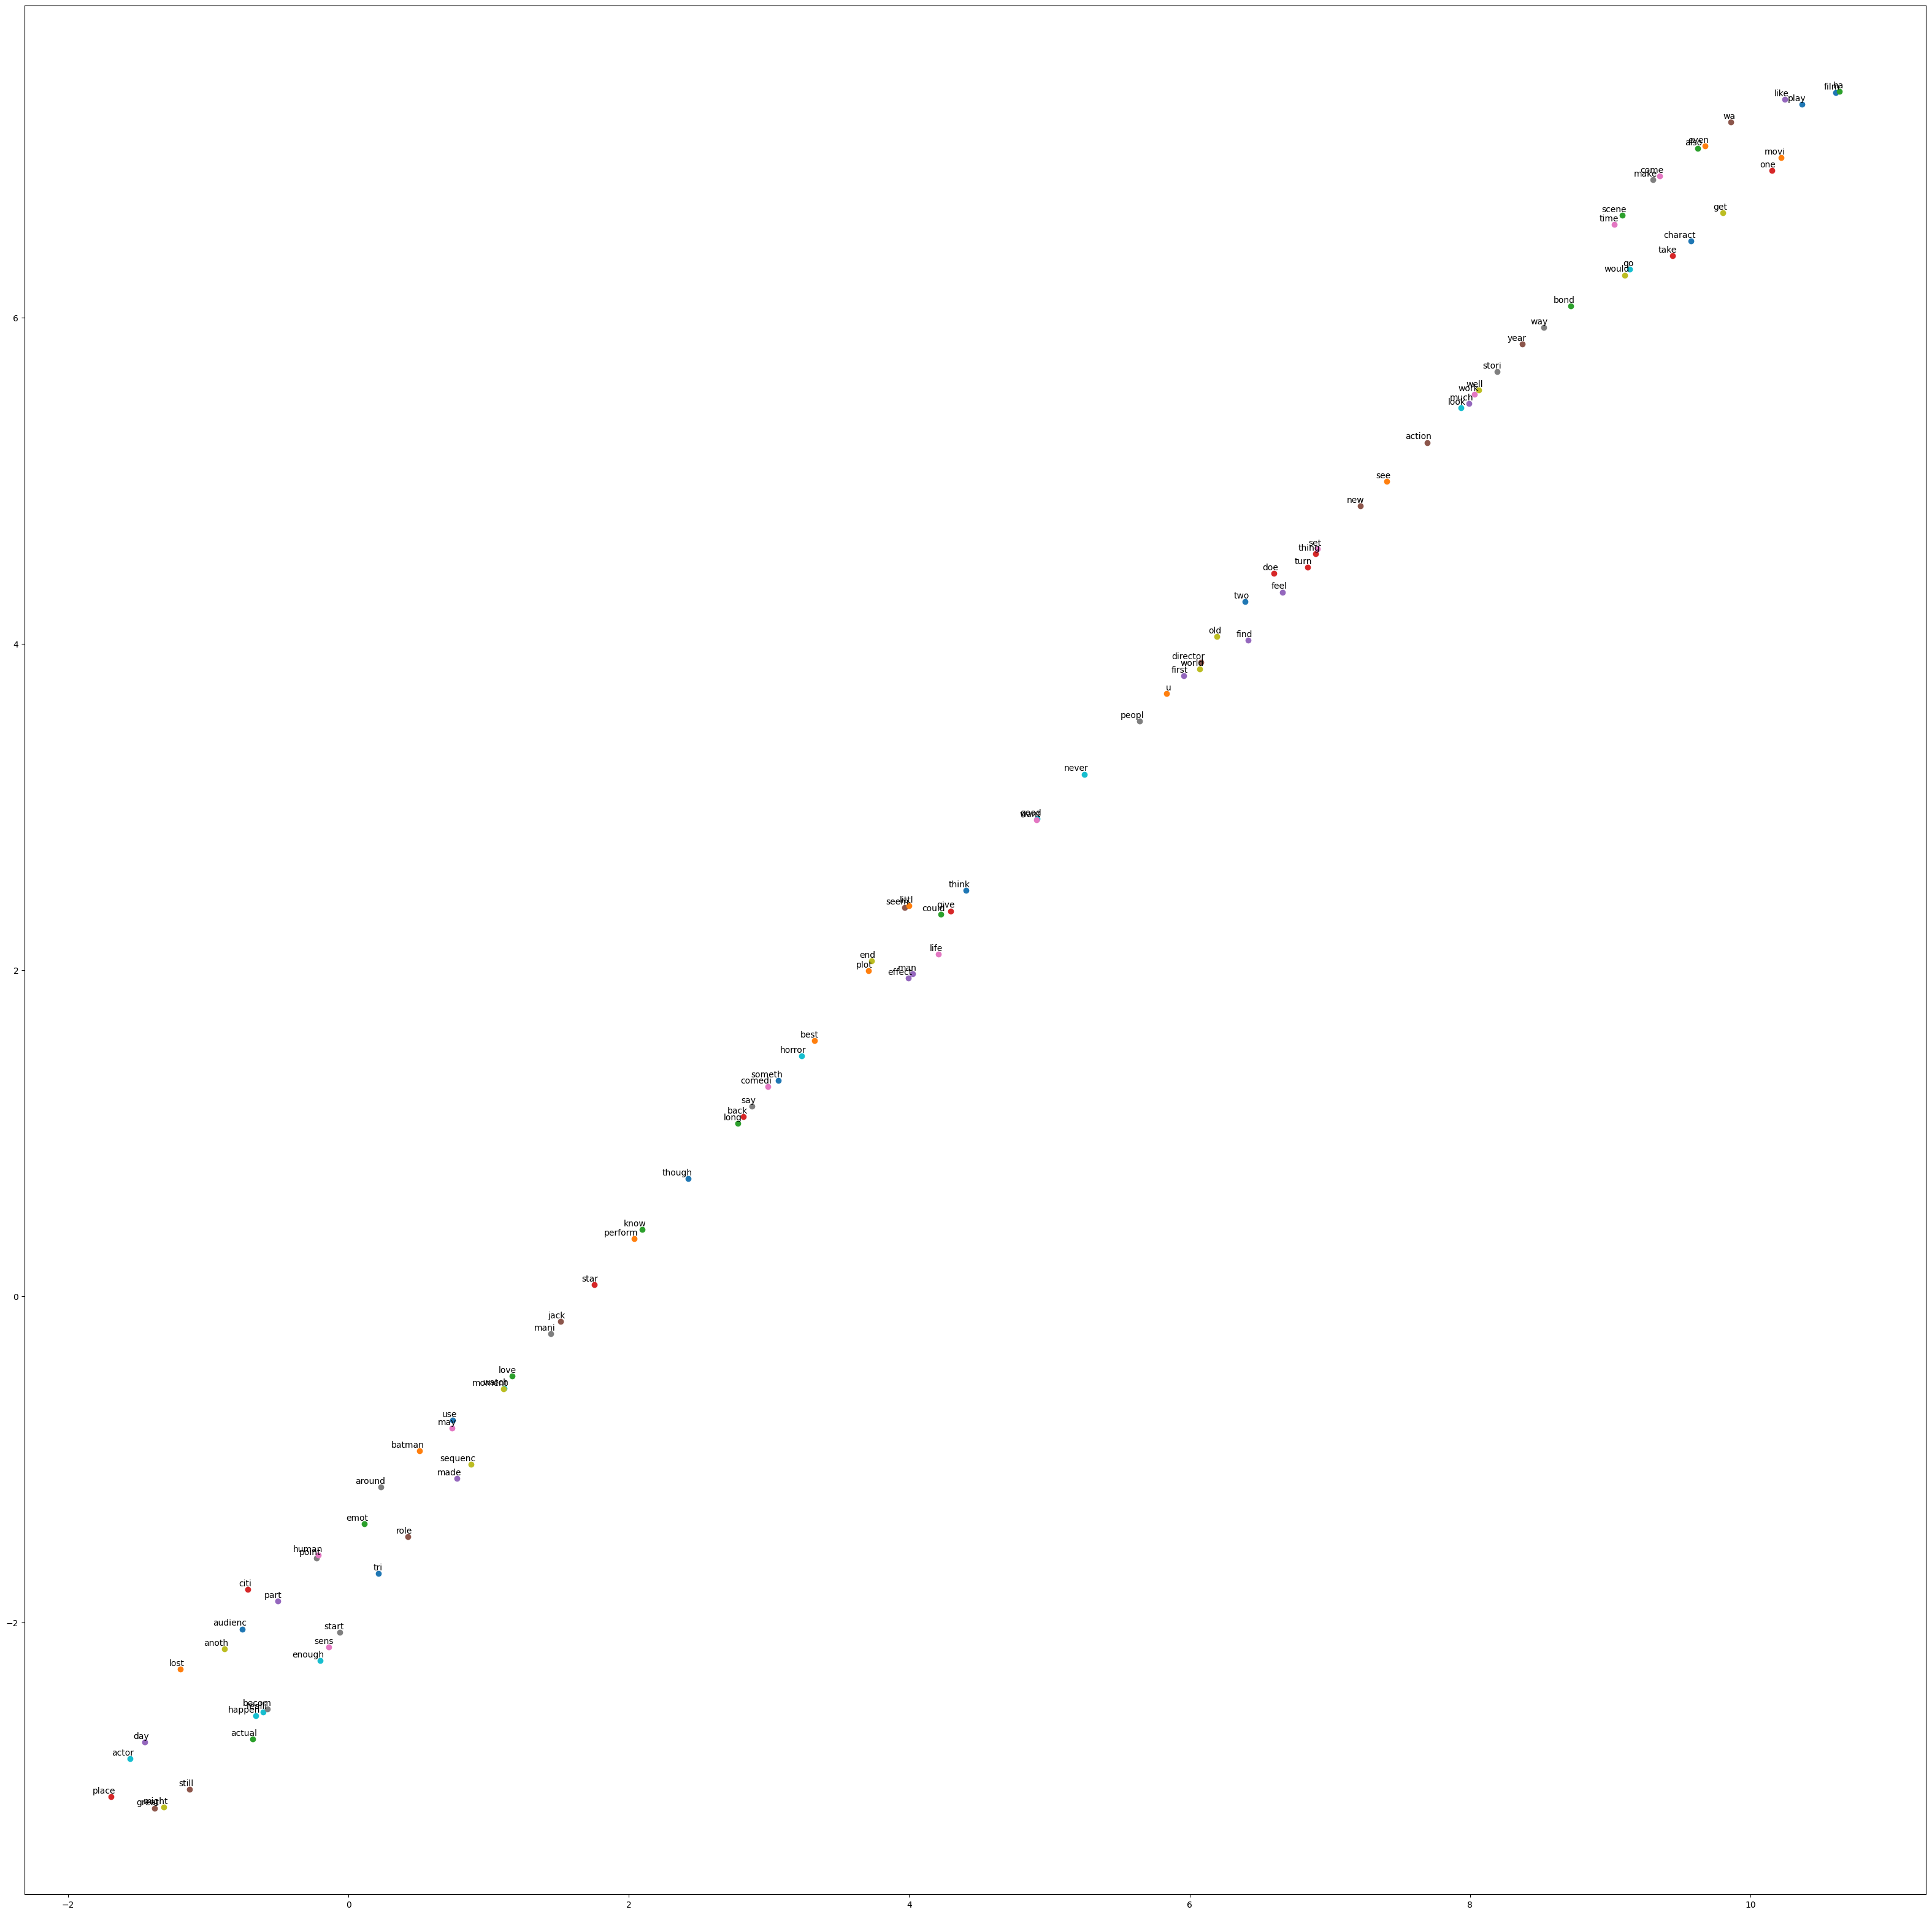

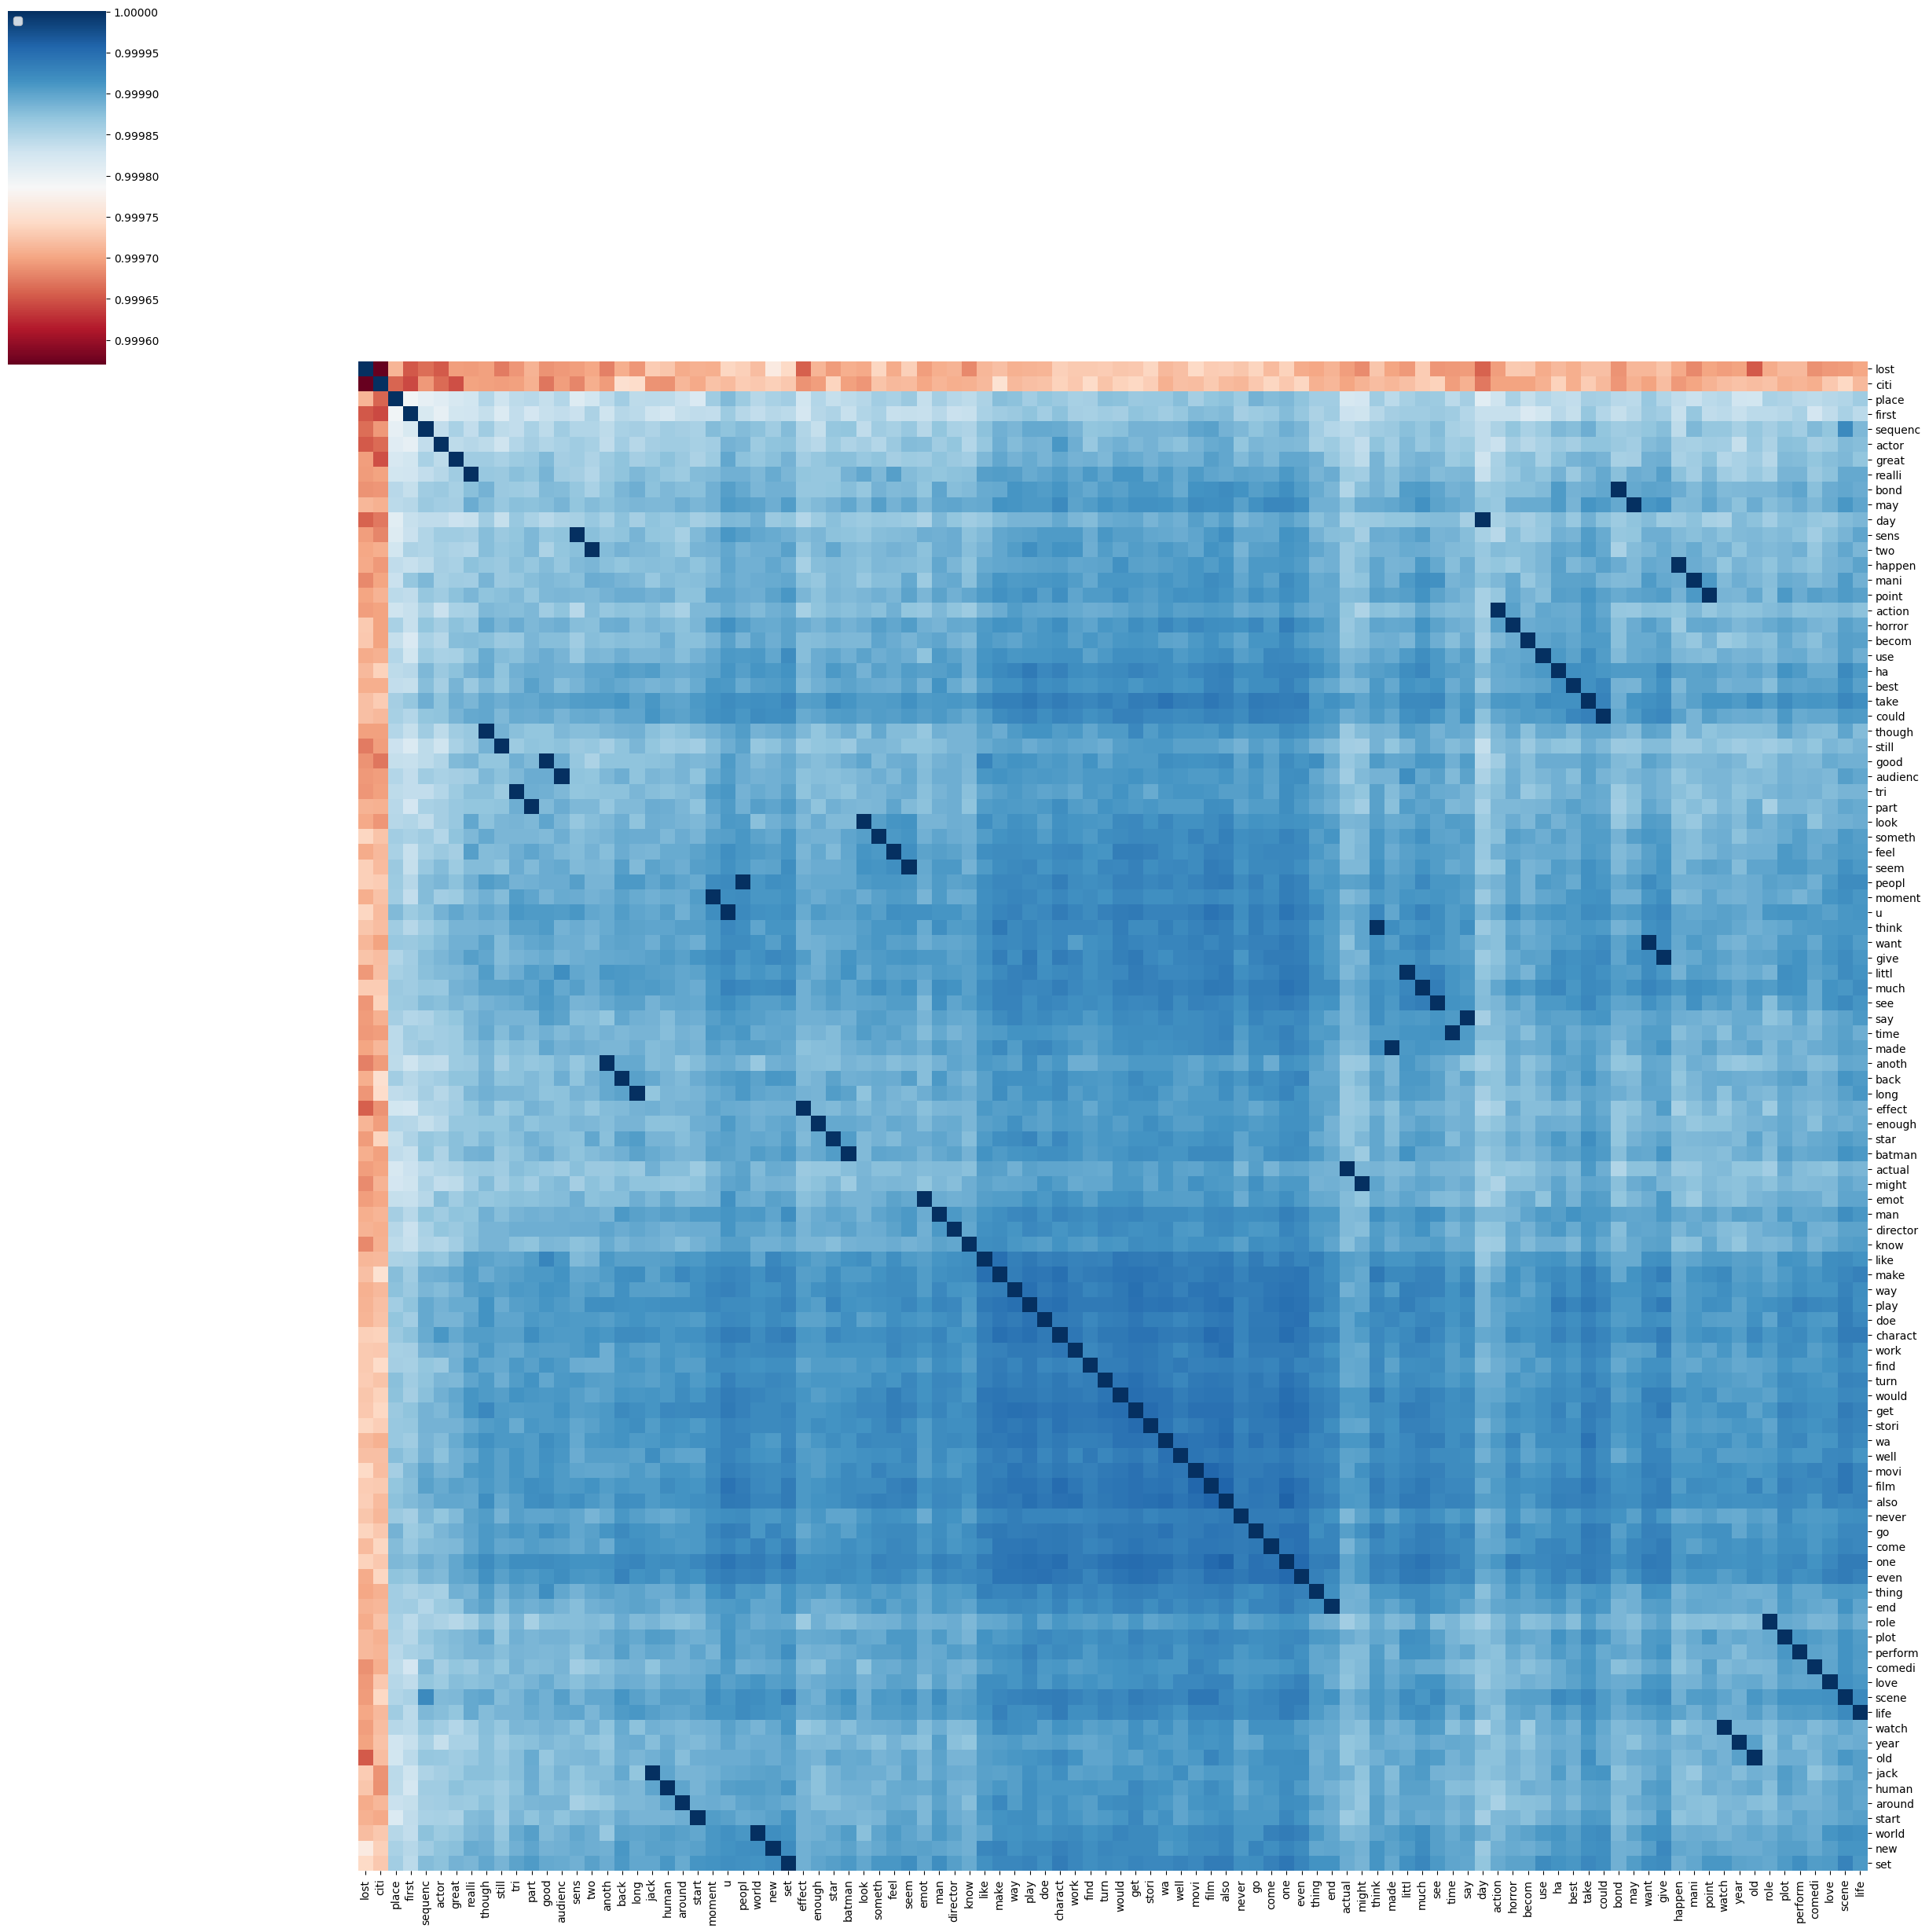

In [ ]:
run_word2vec_experiment(documents, clean_method, 300, tokens_most_common, "W2V_most_common_300d")

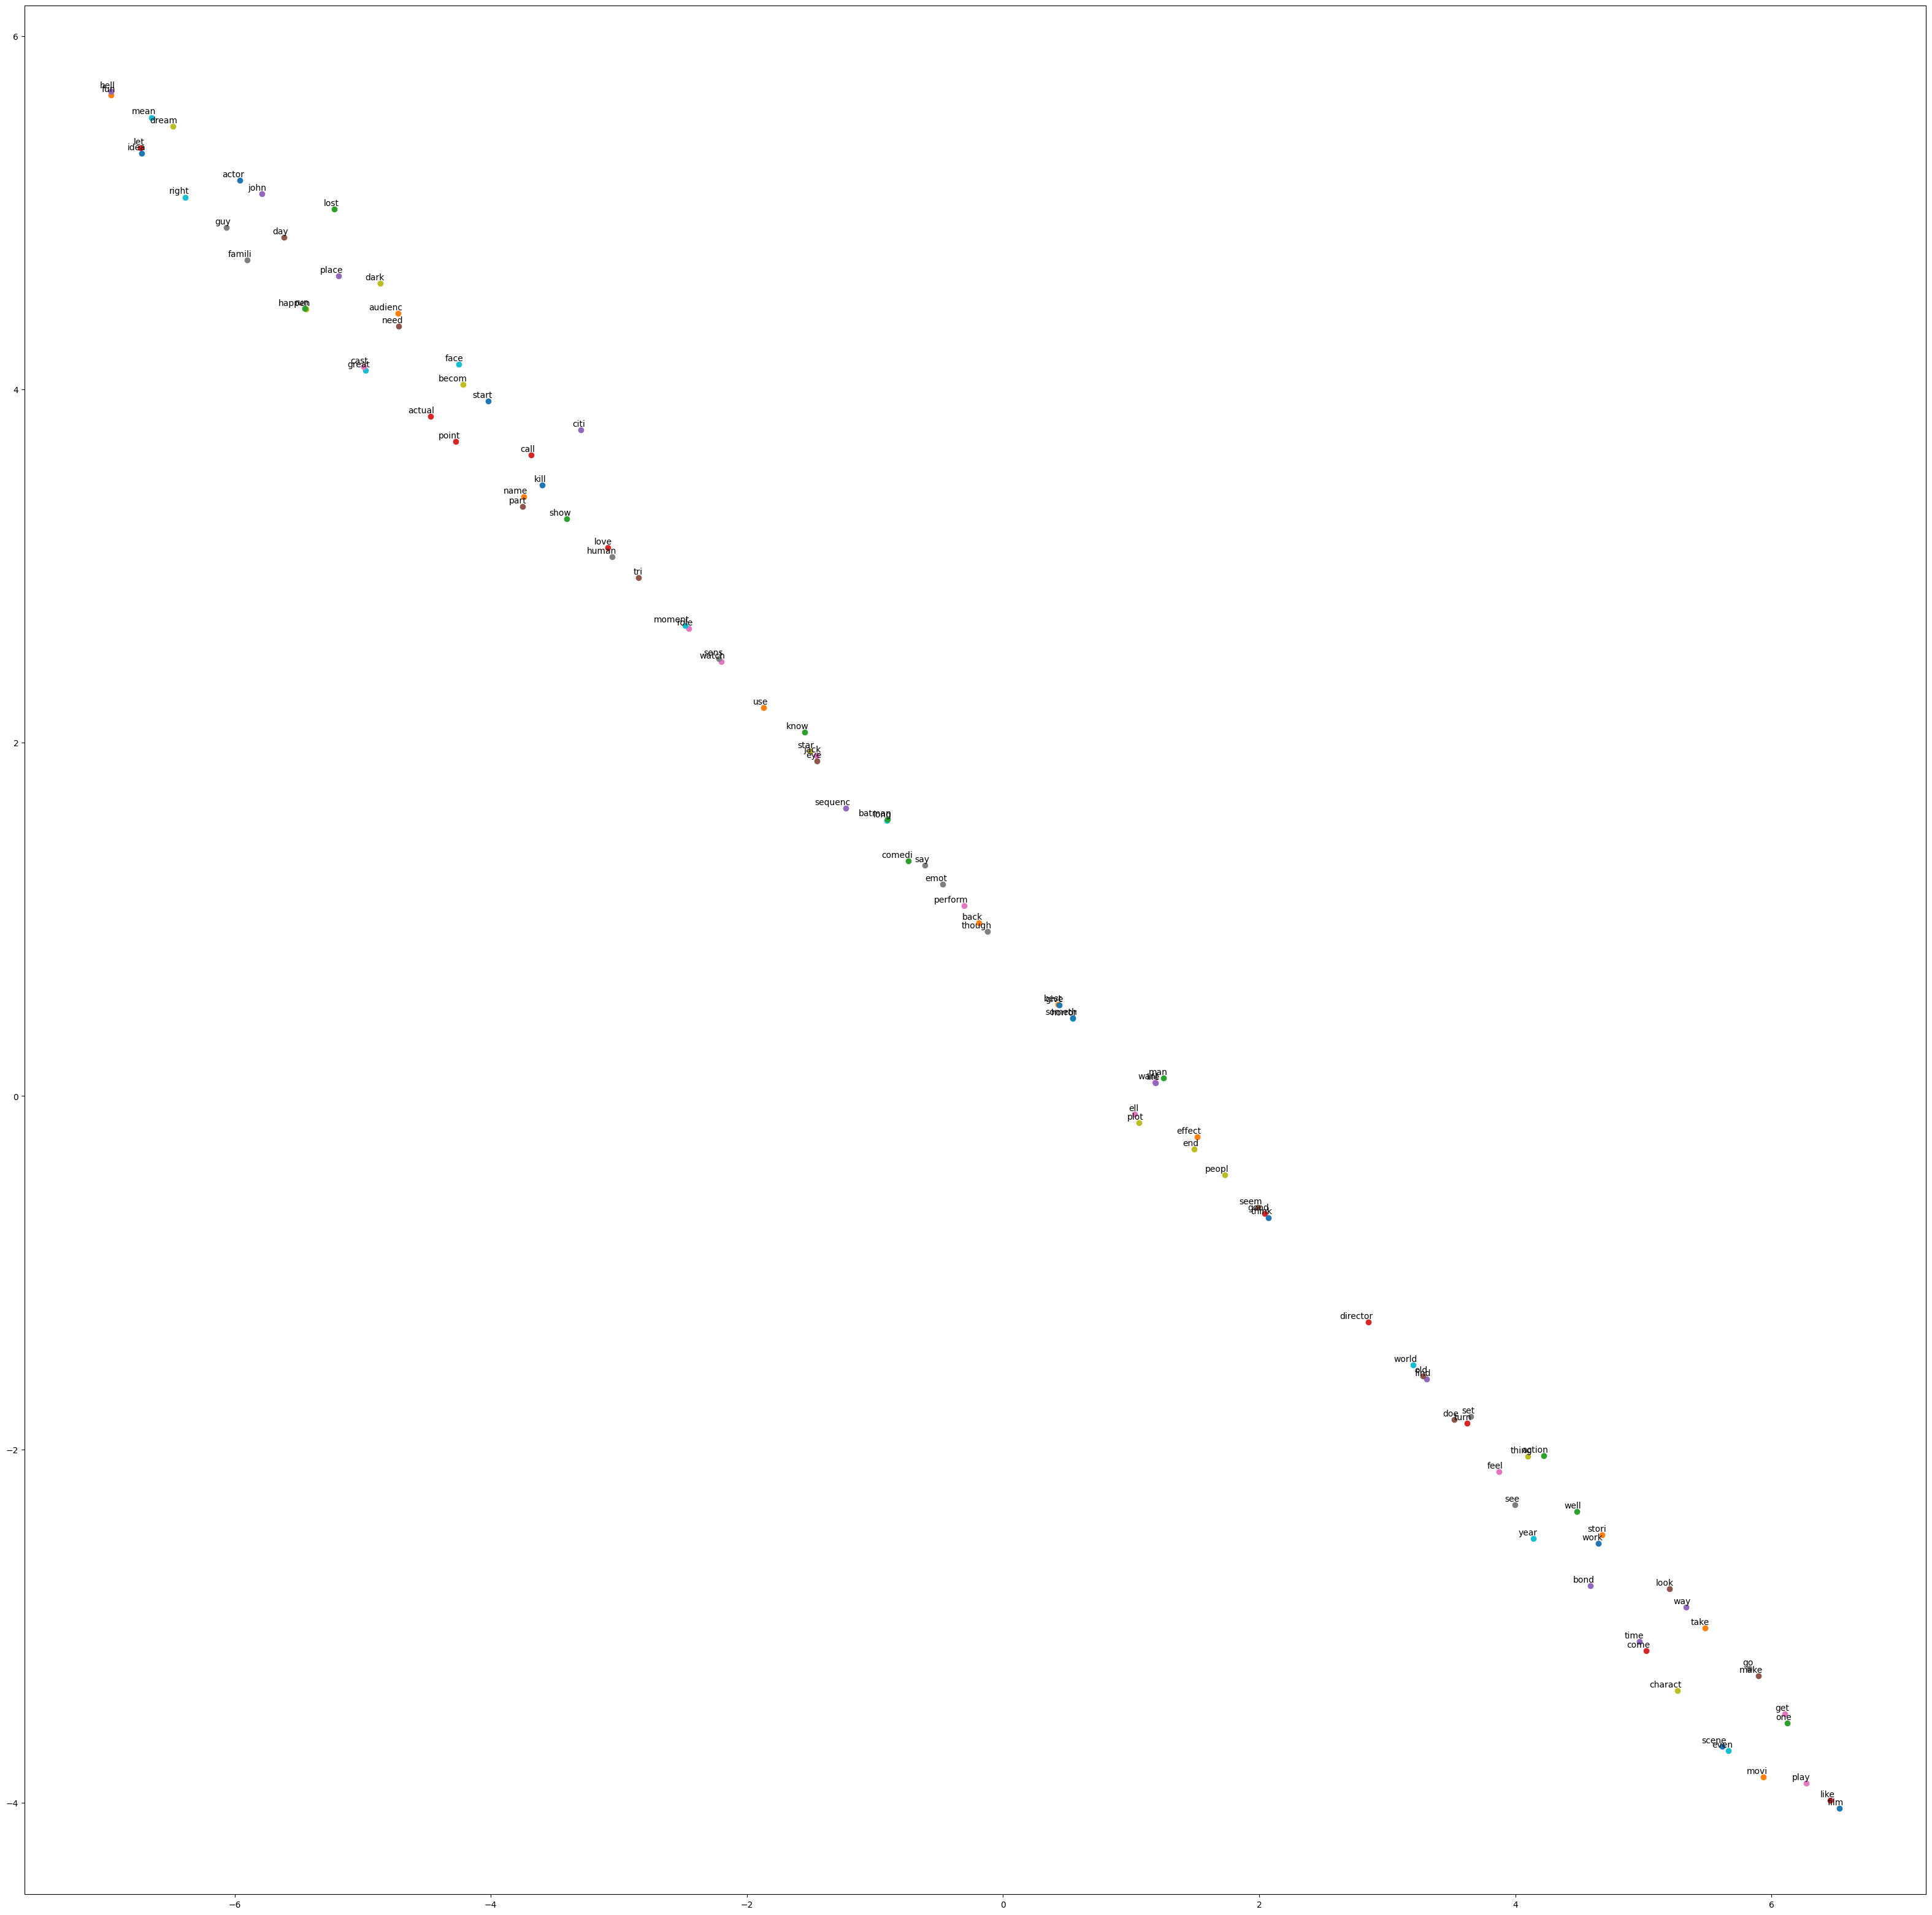

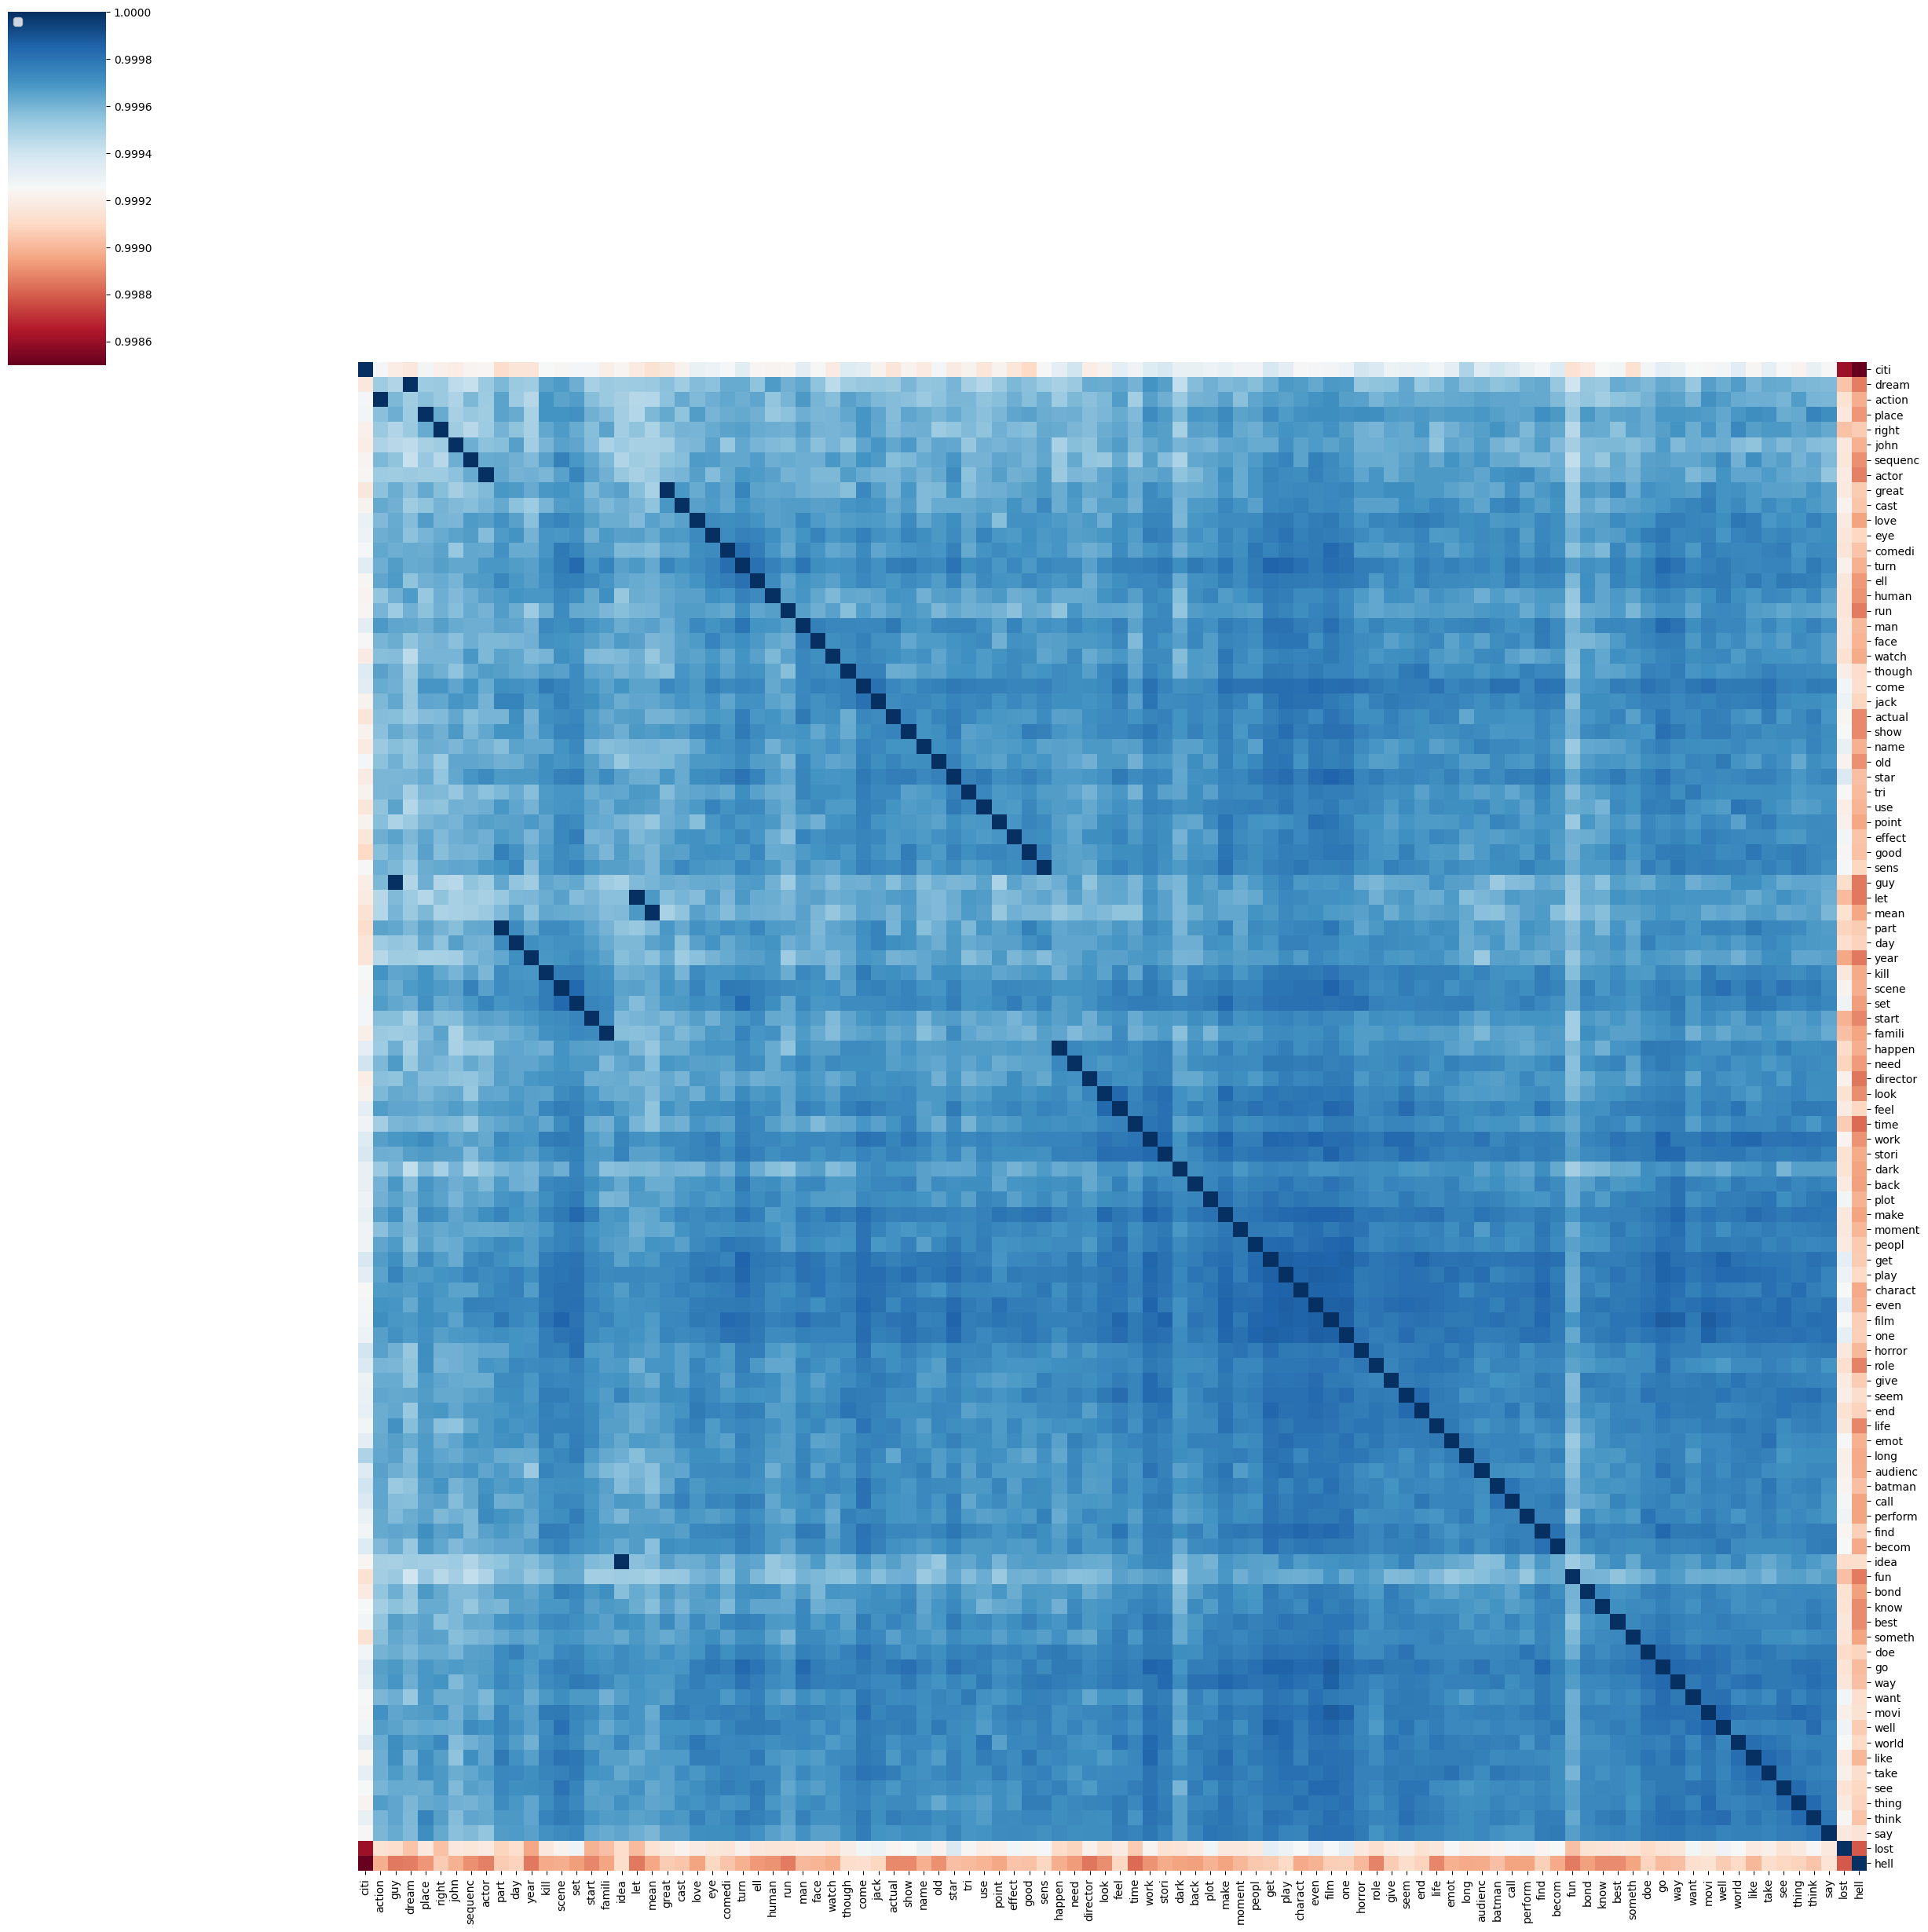

In [ ]:
# nouns
run_word2vec_experiment(documents, clean_method, 100, tokens_nouns, "W2V_nouns_100d")

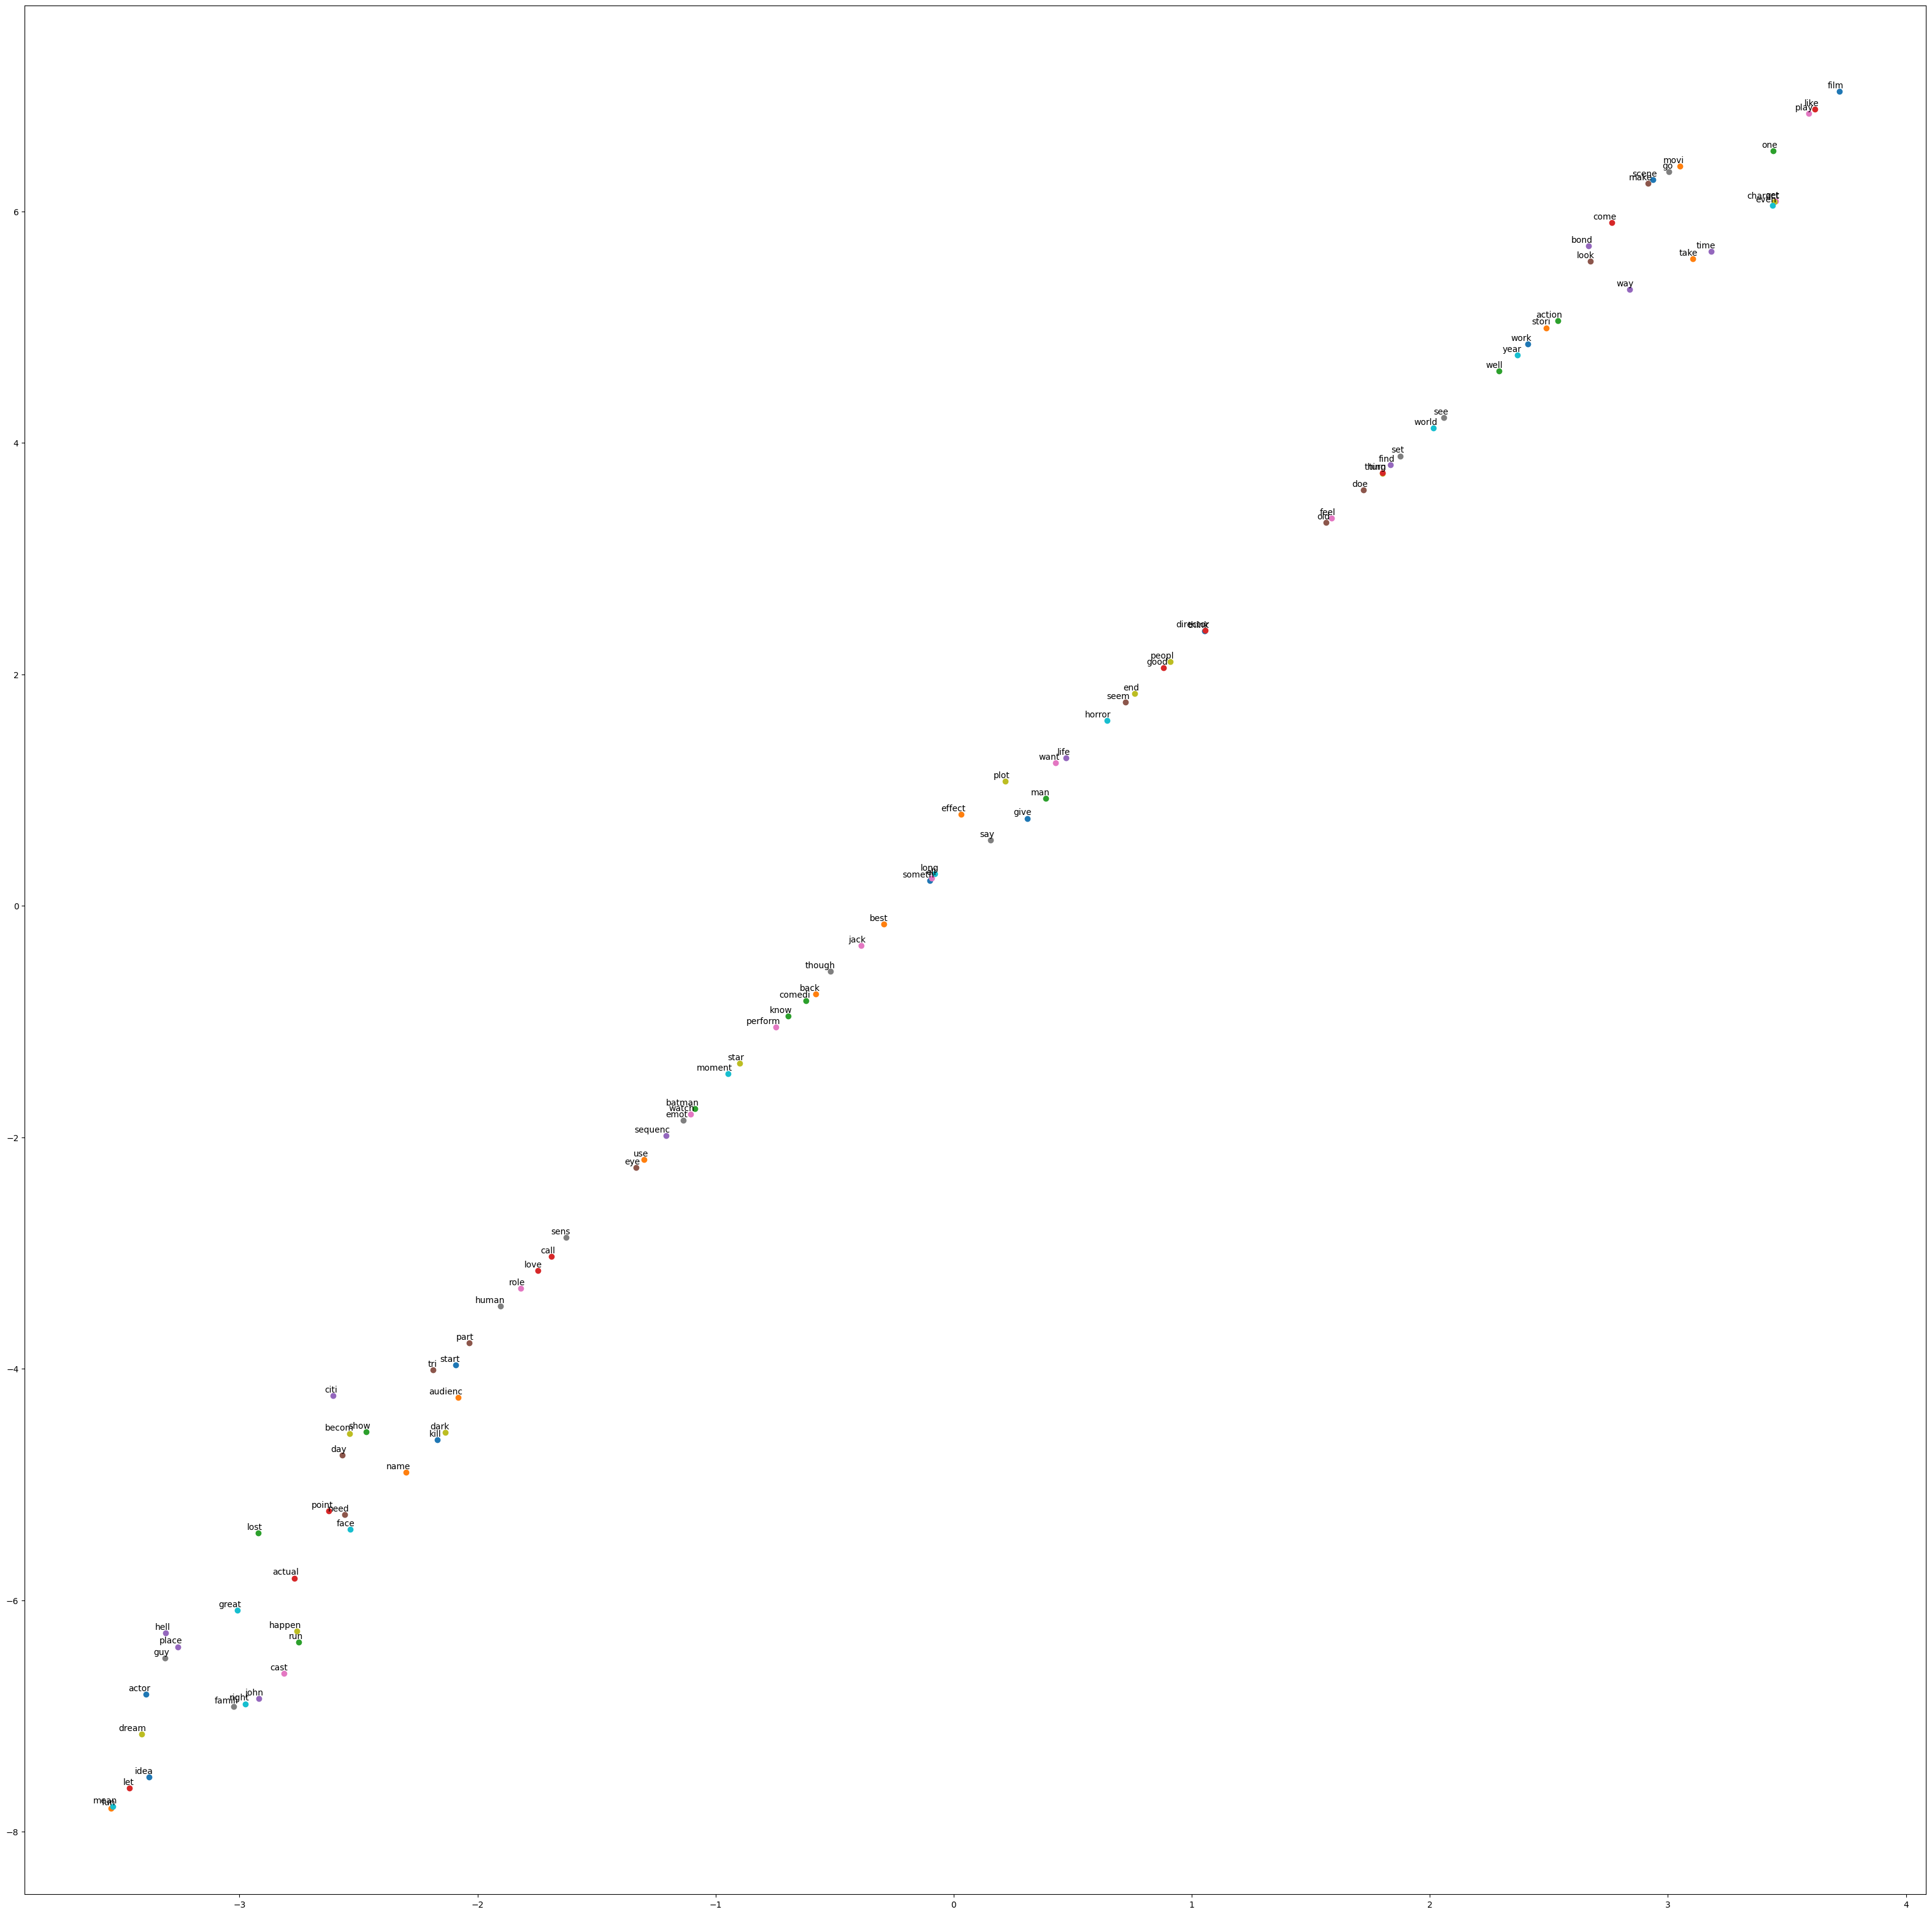

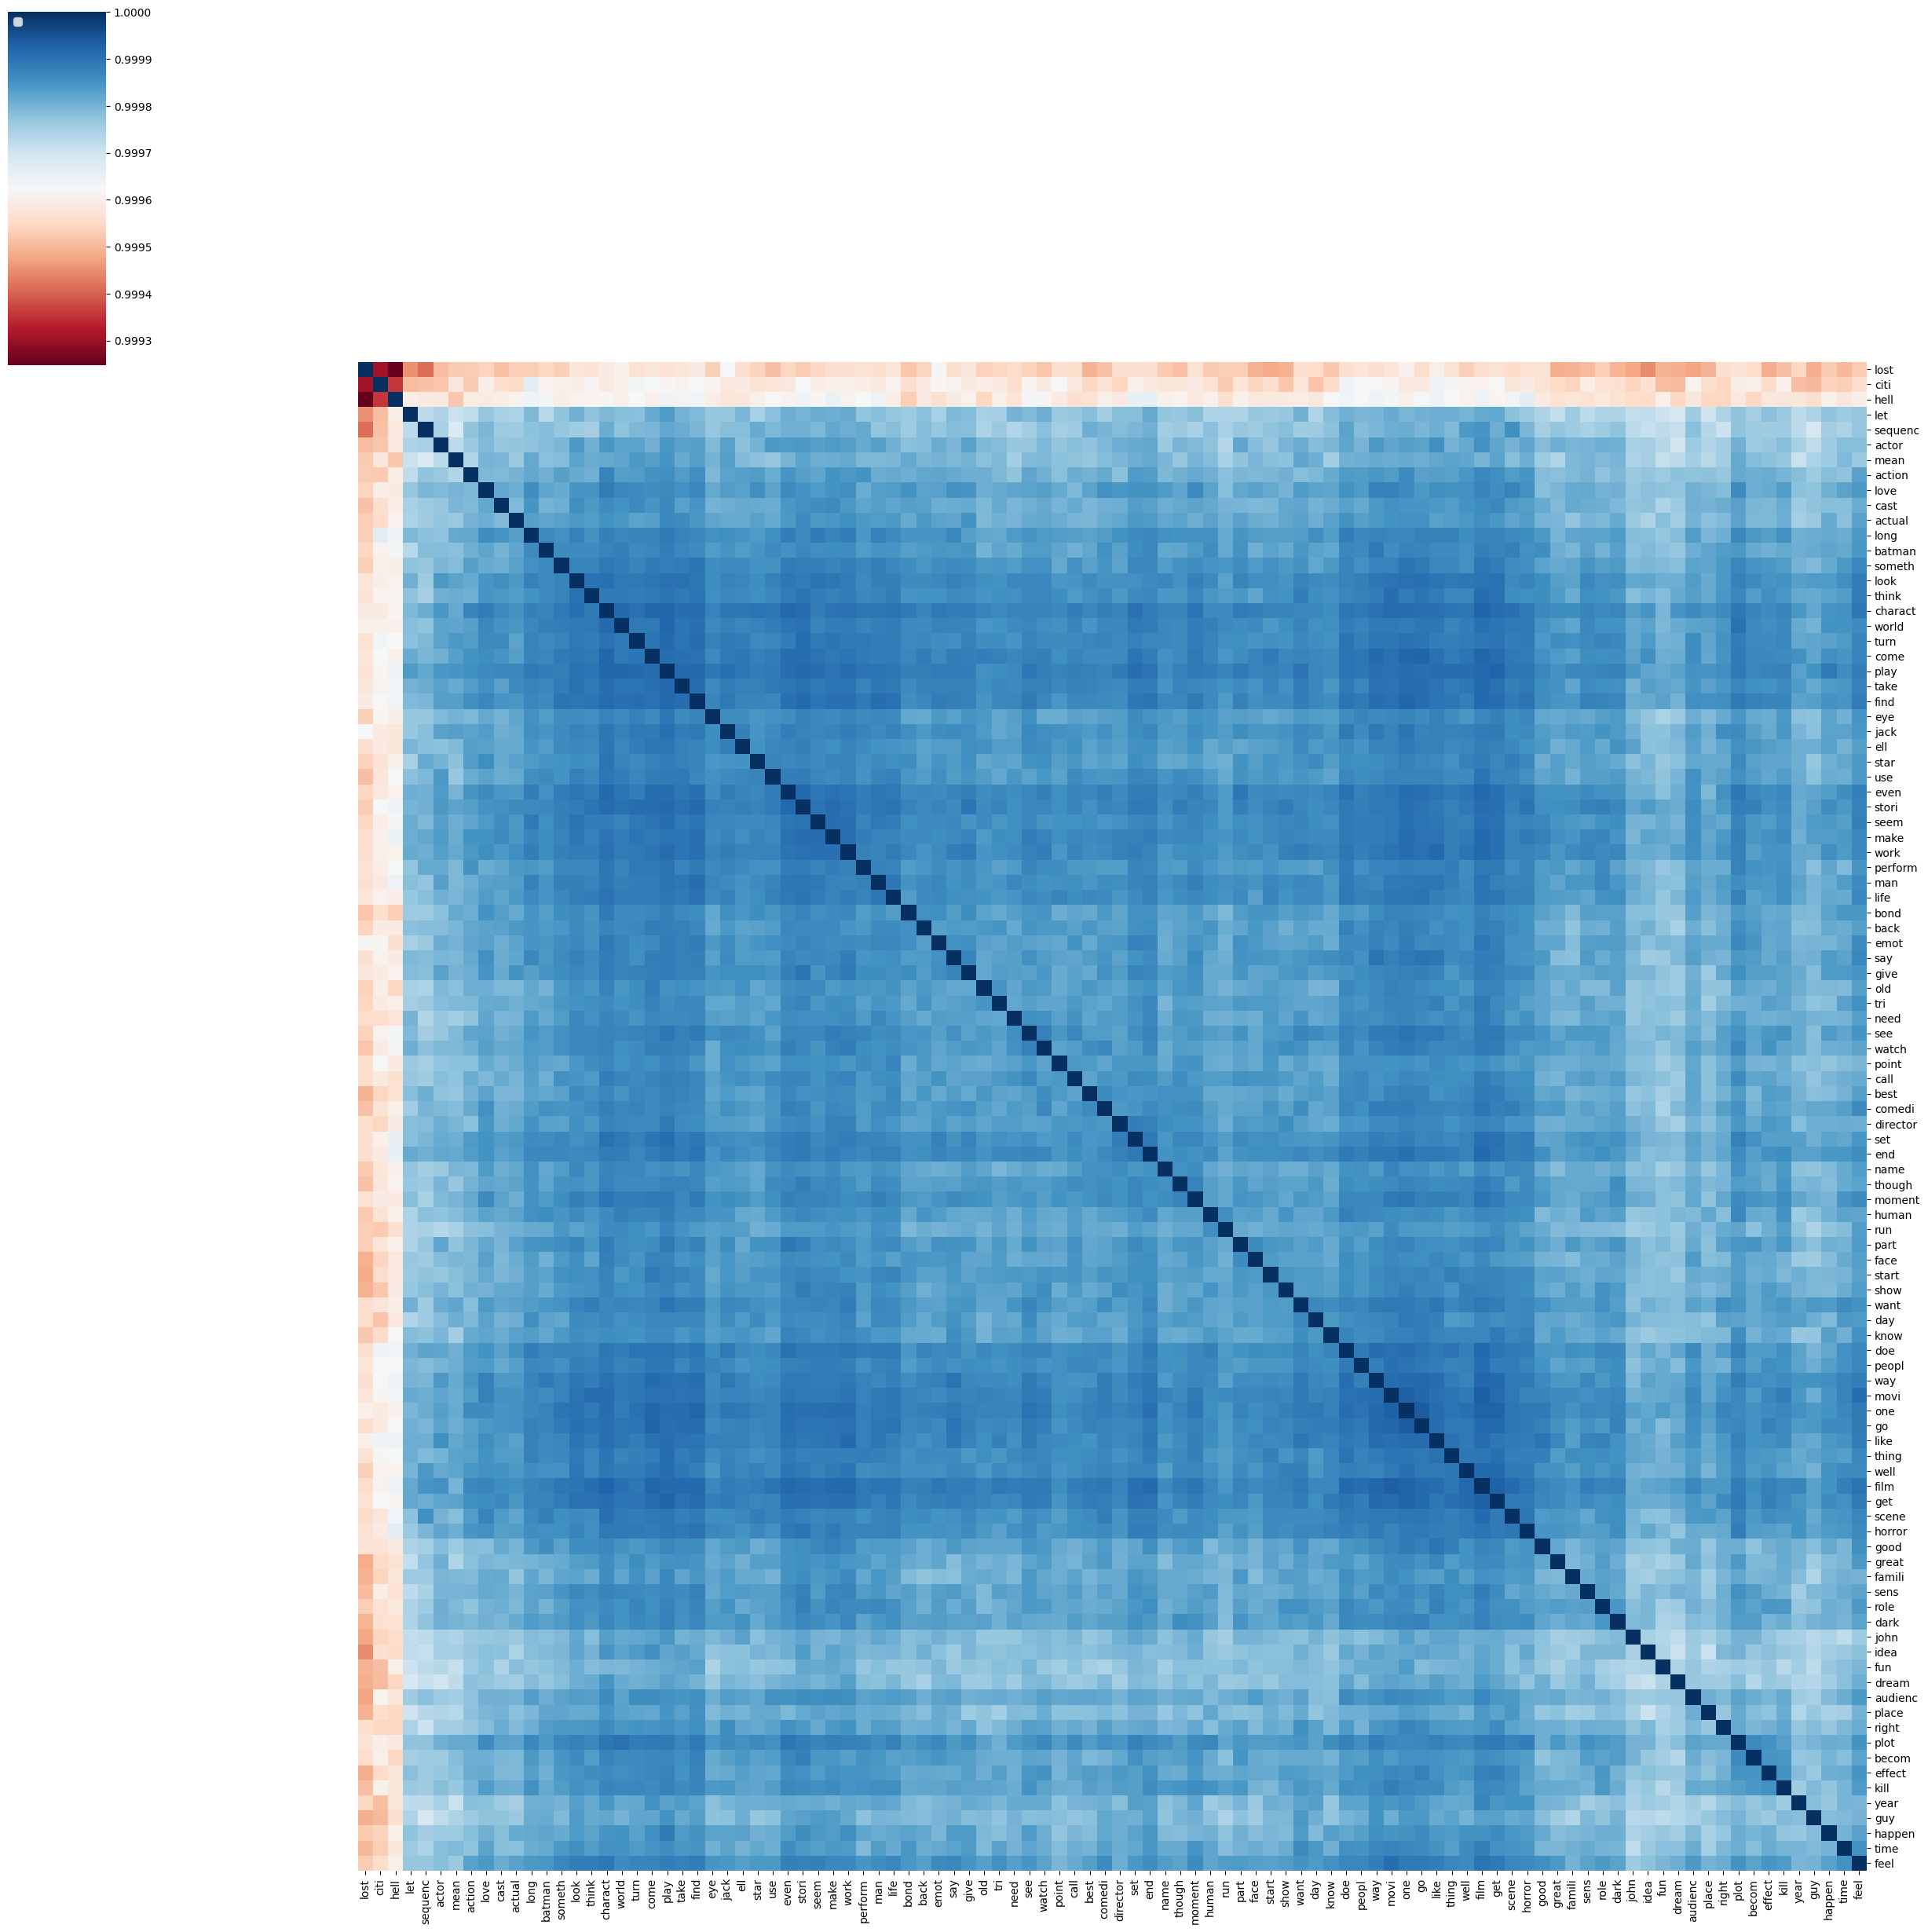

In [ ]:
run_word2vec_experiment(documents, clean_method, 200, tokens_nouns, "W2V_nouns_200d")

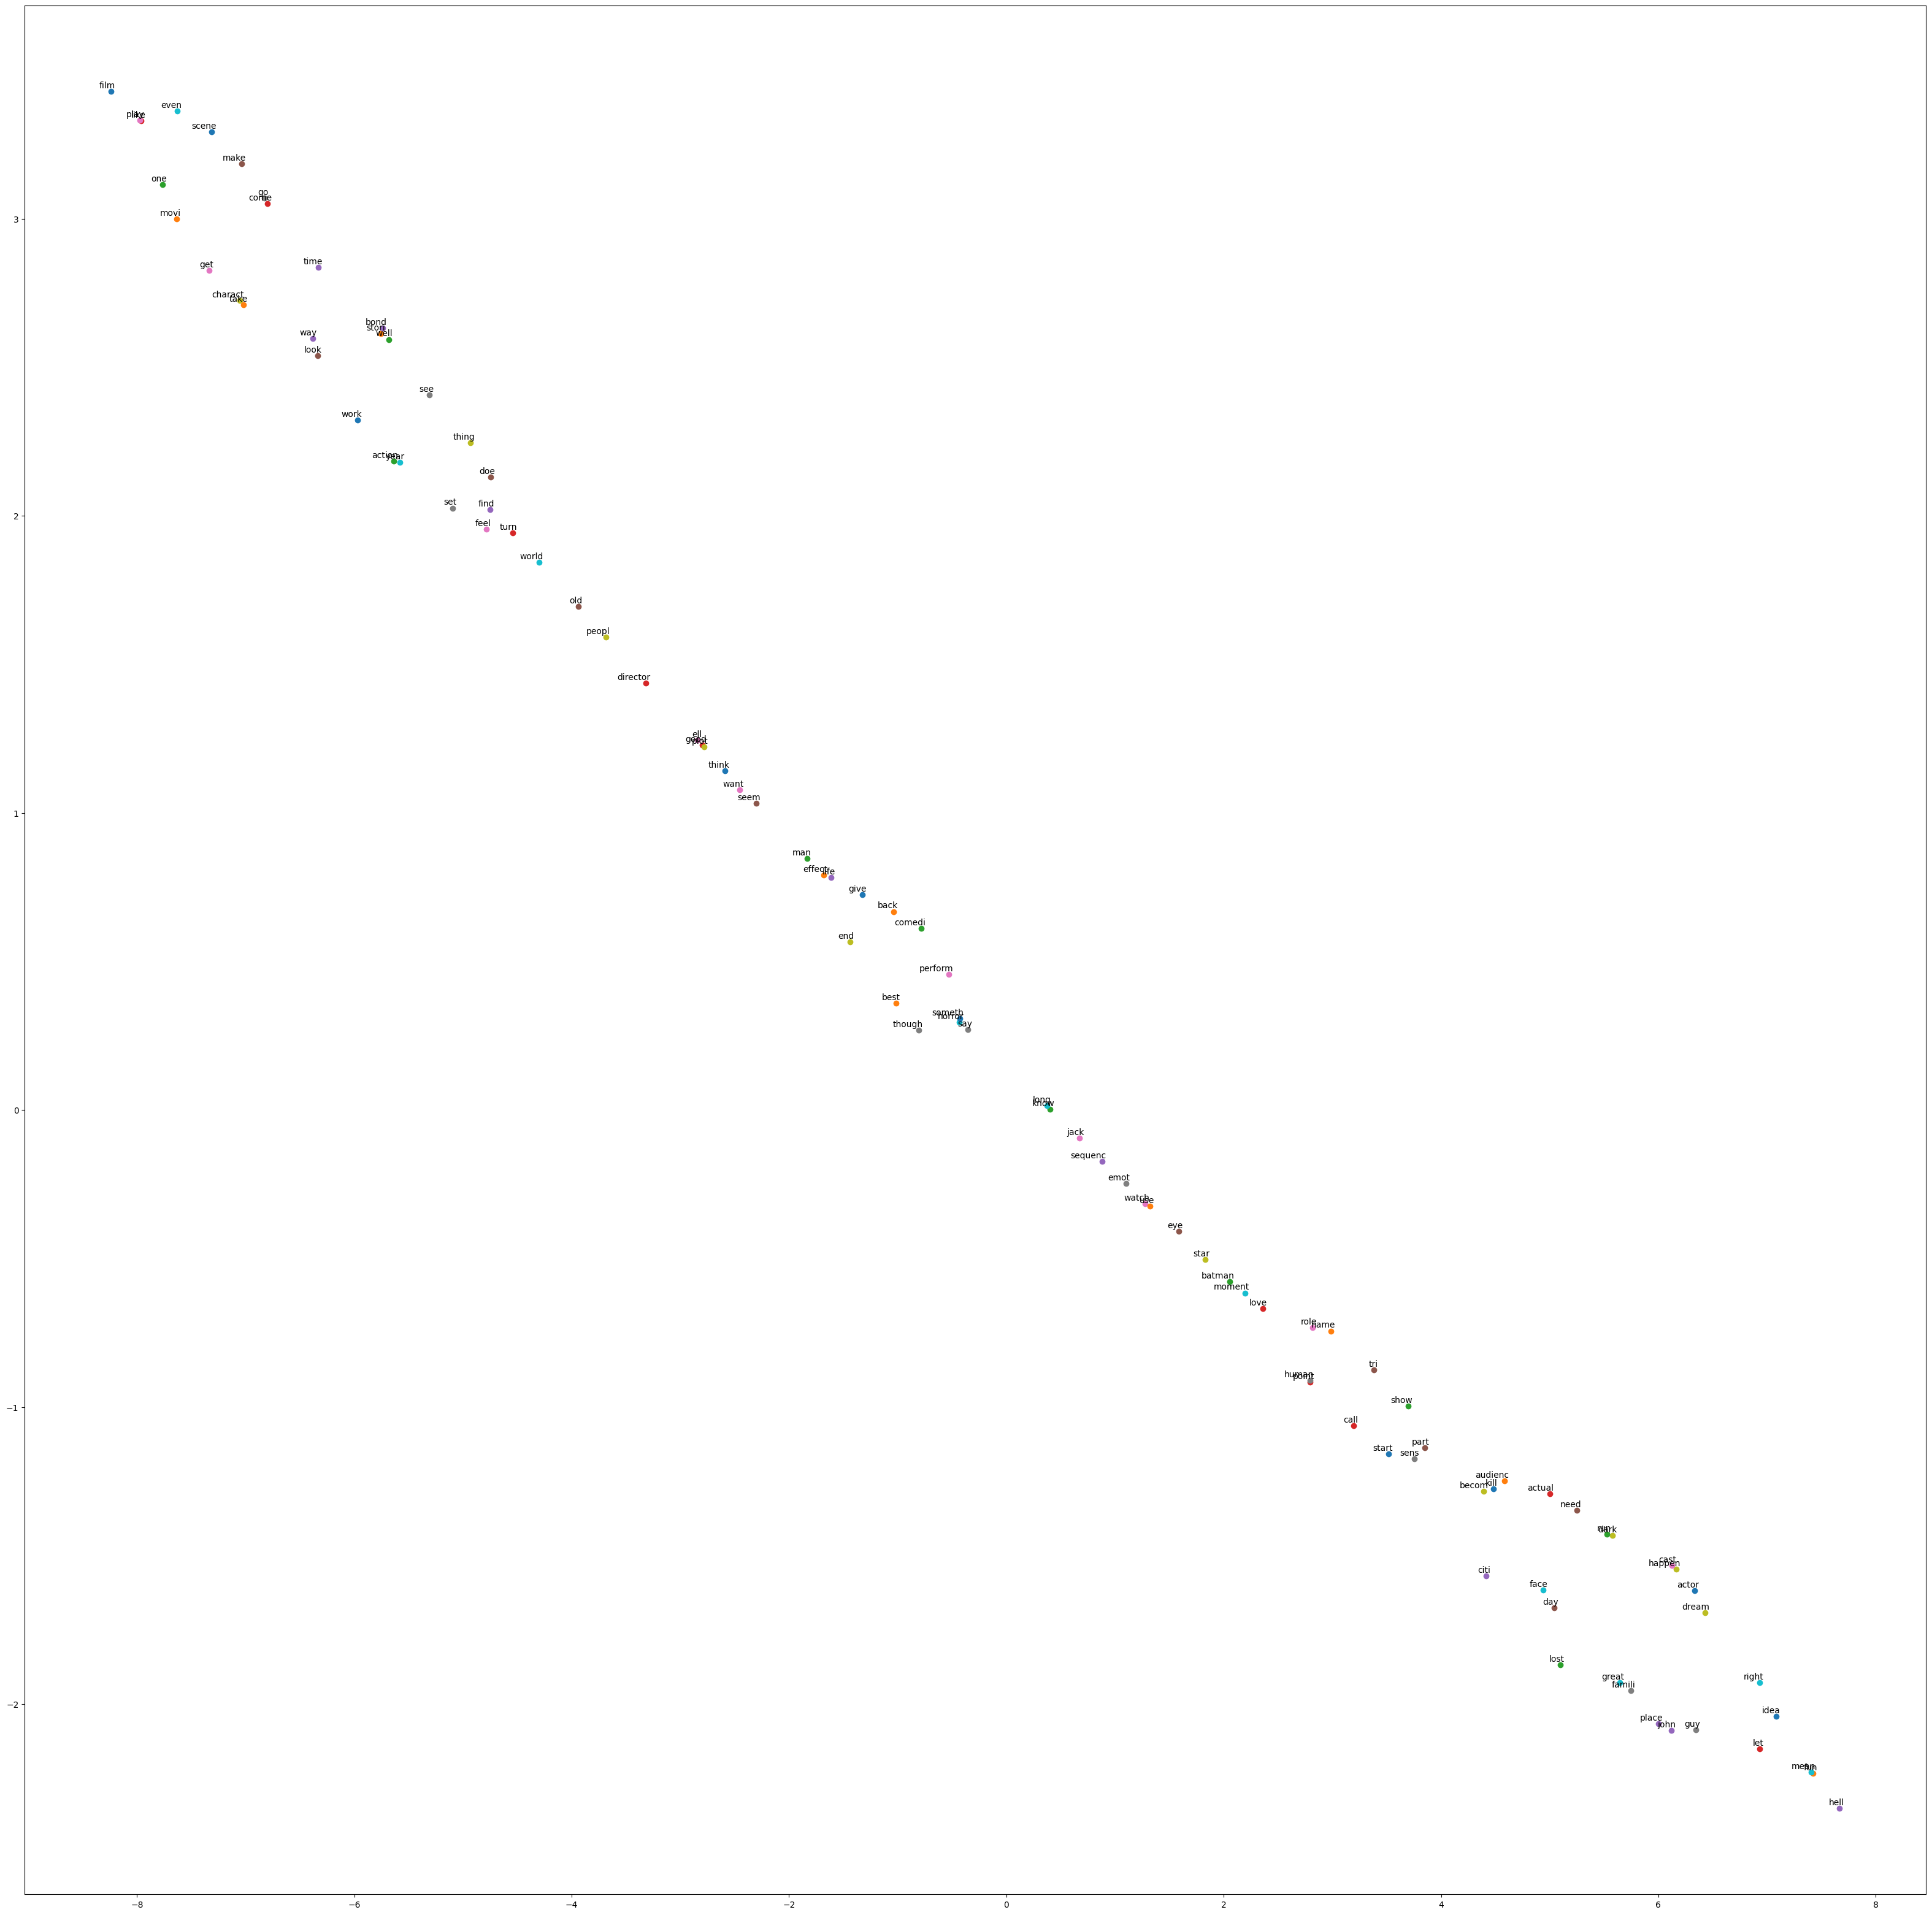

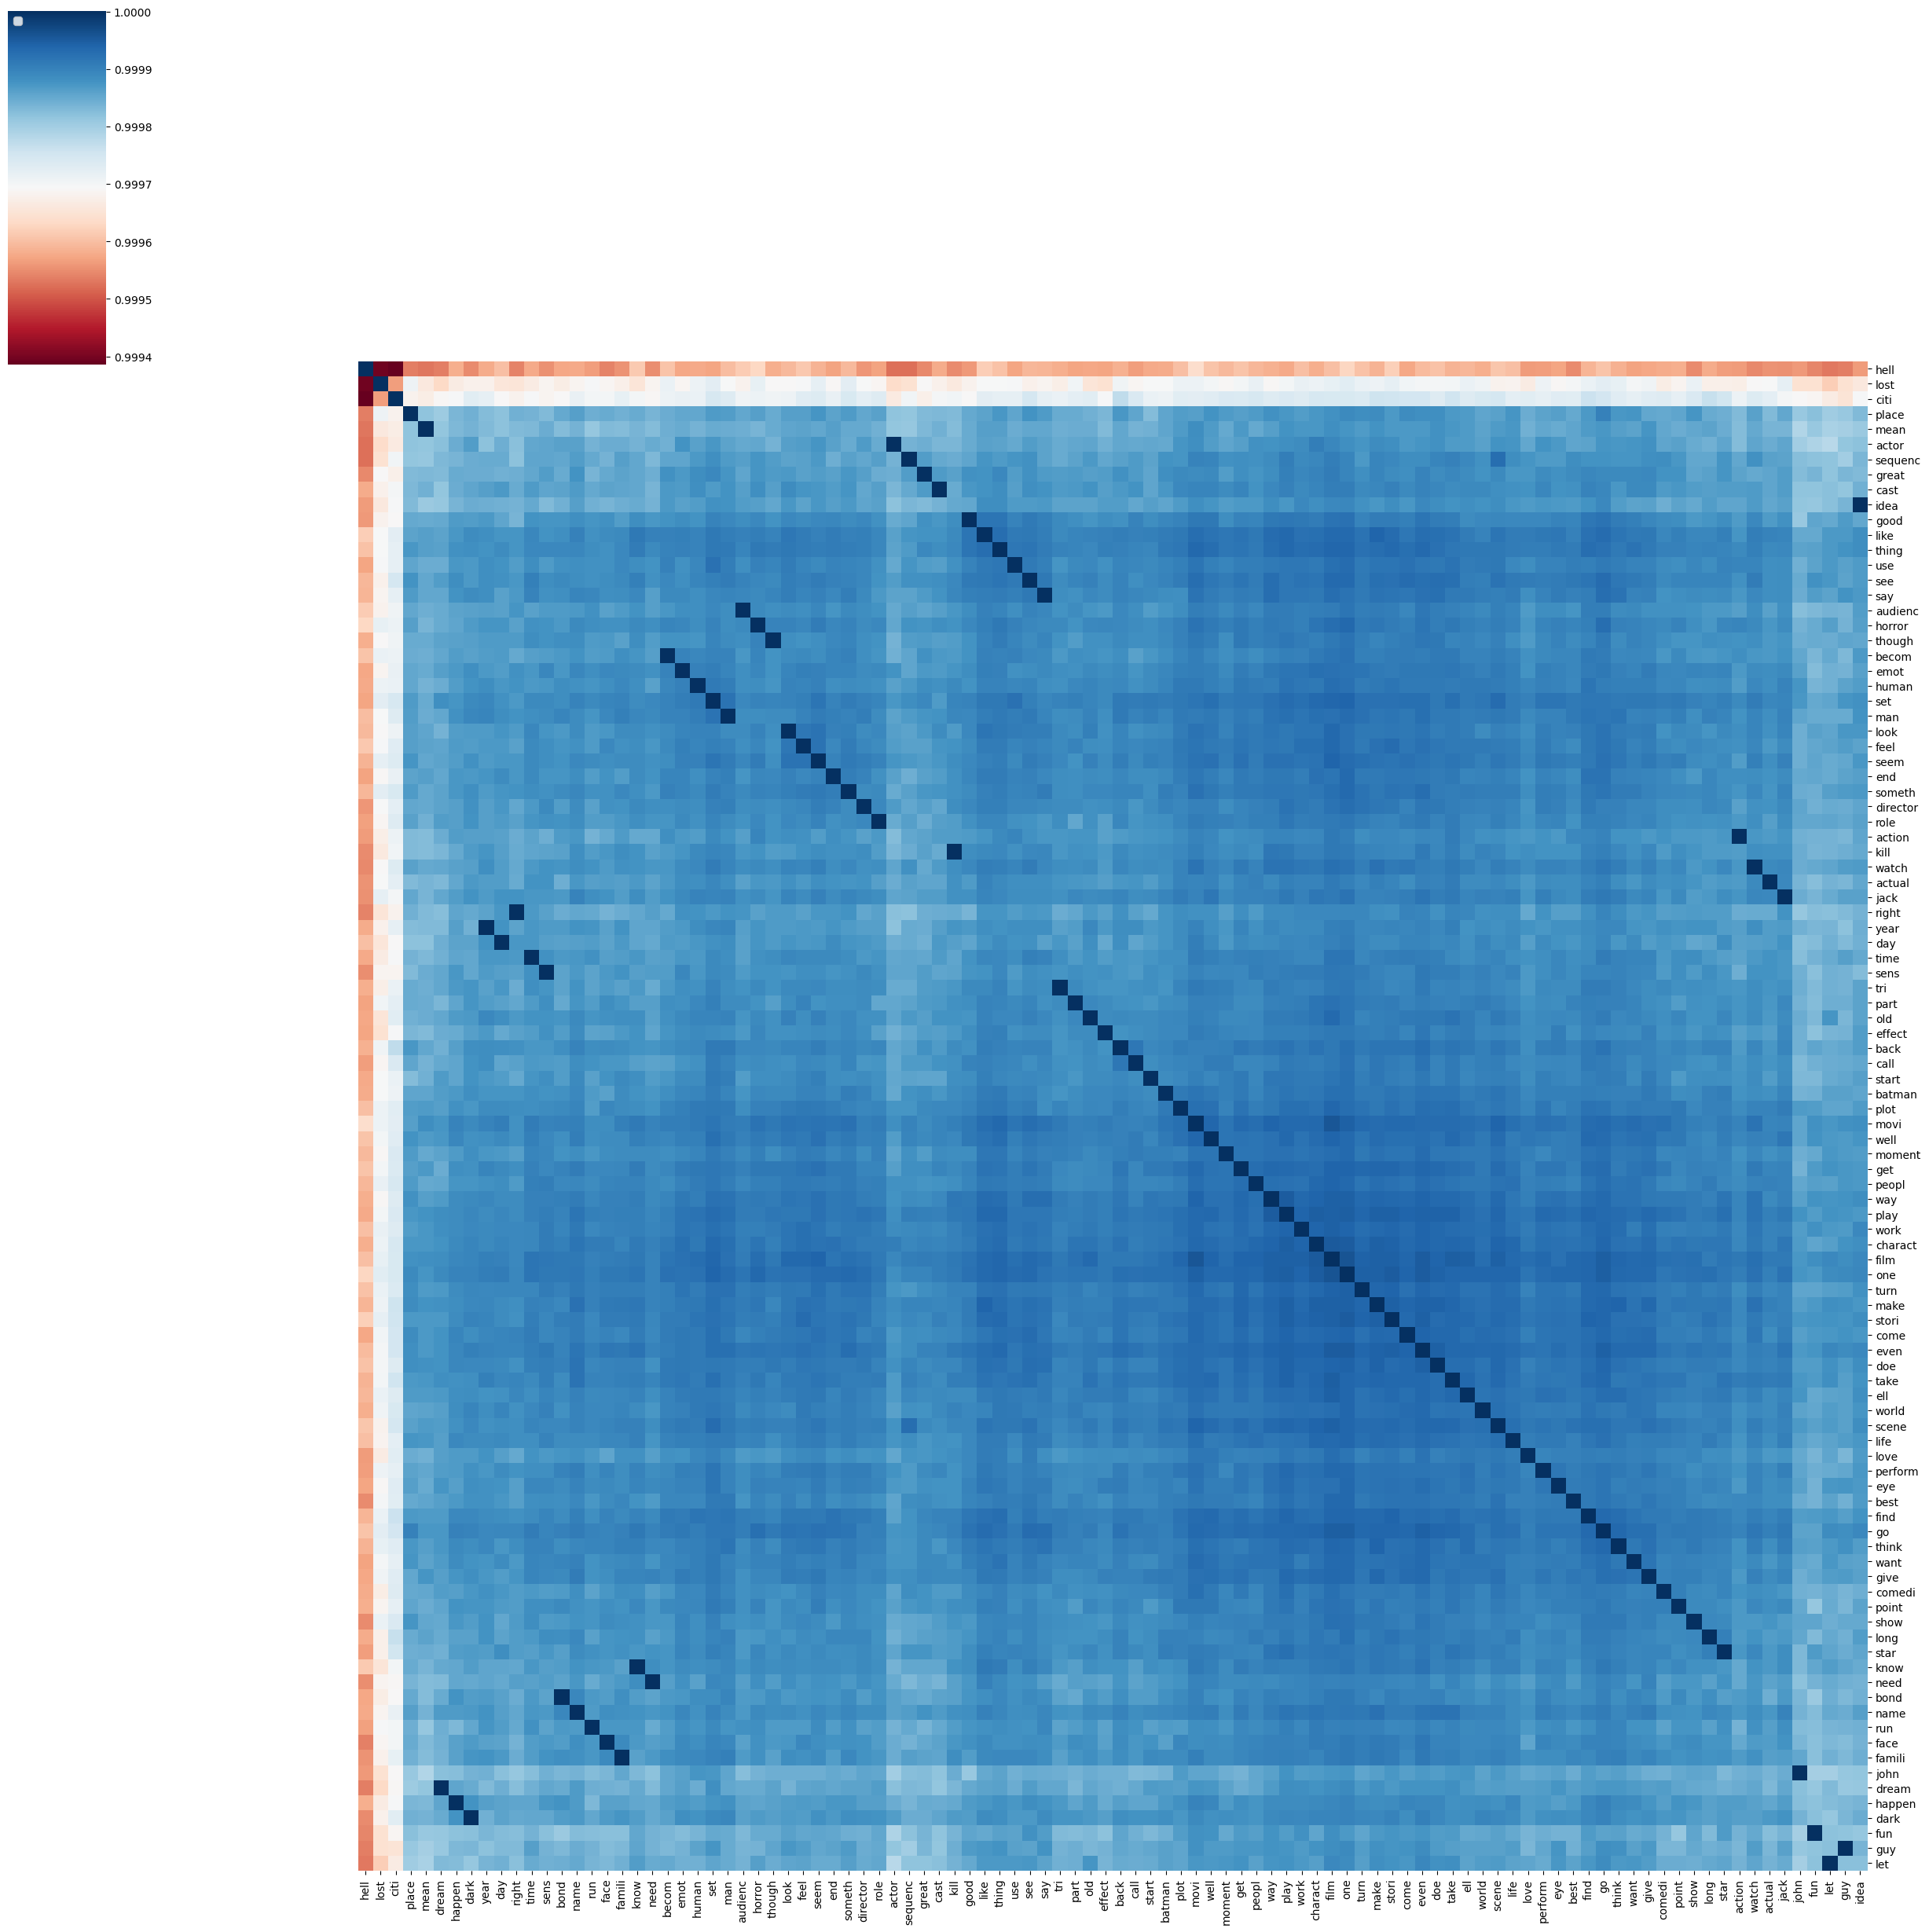

In [ ]:
run_word2vec_experiment(documents, clean_method, 300, tokens_nouns, "W2V_nouns_300d")

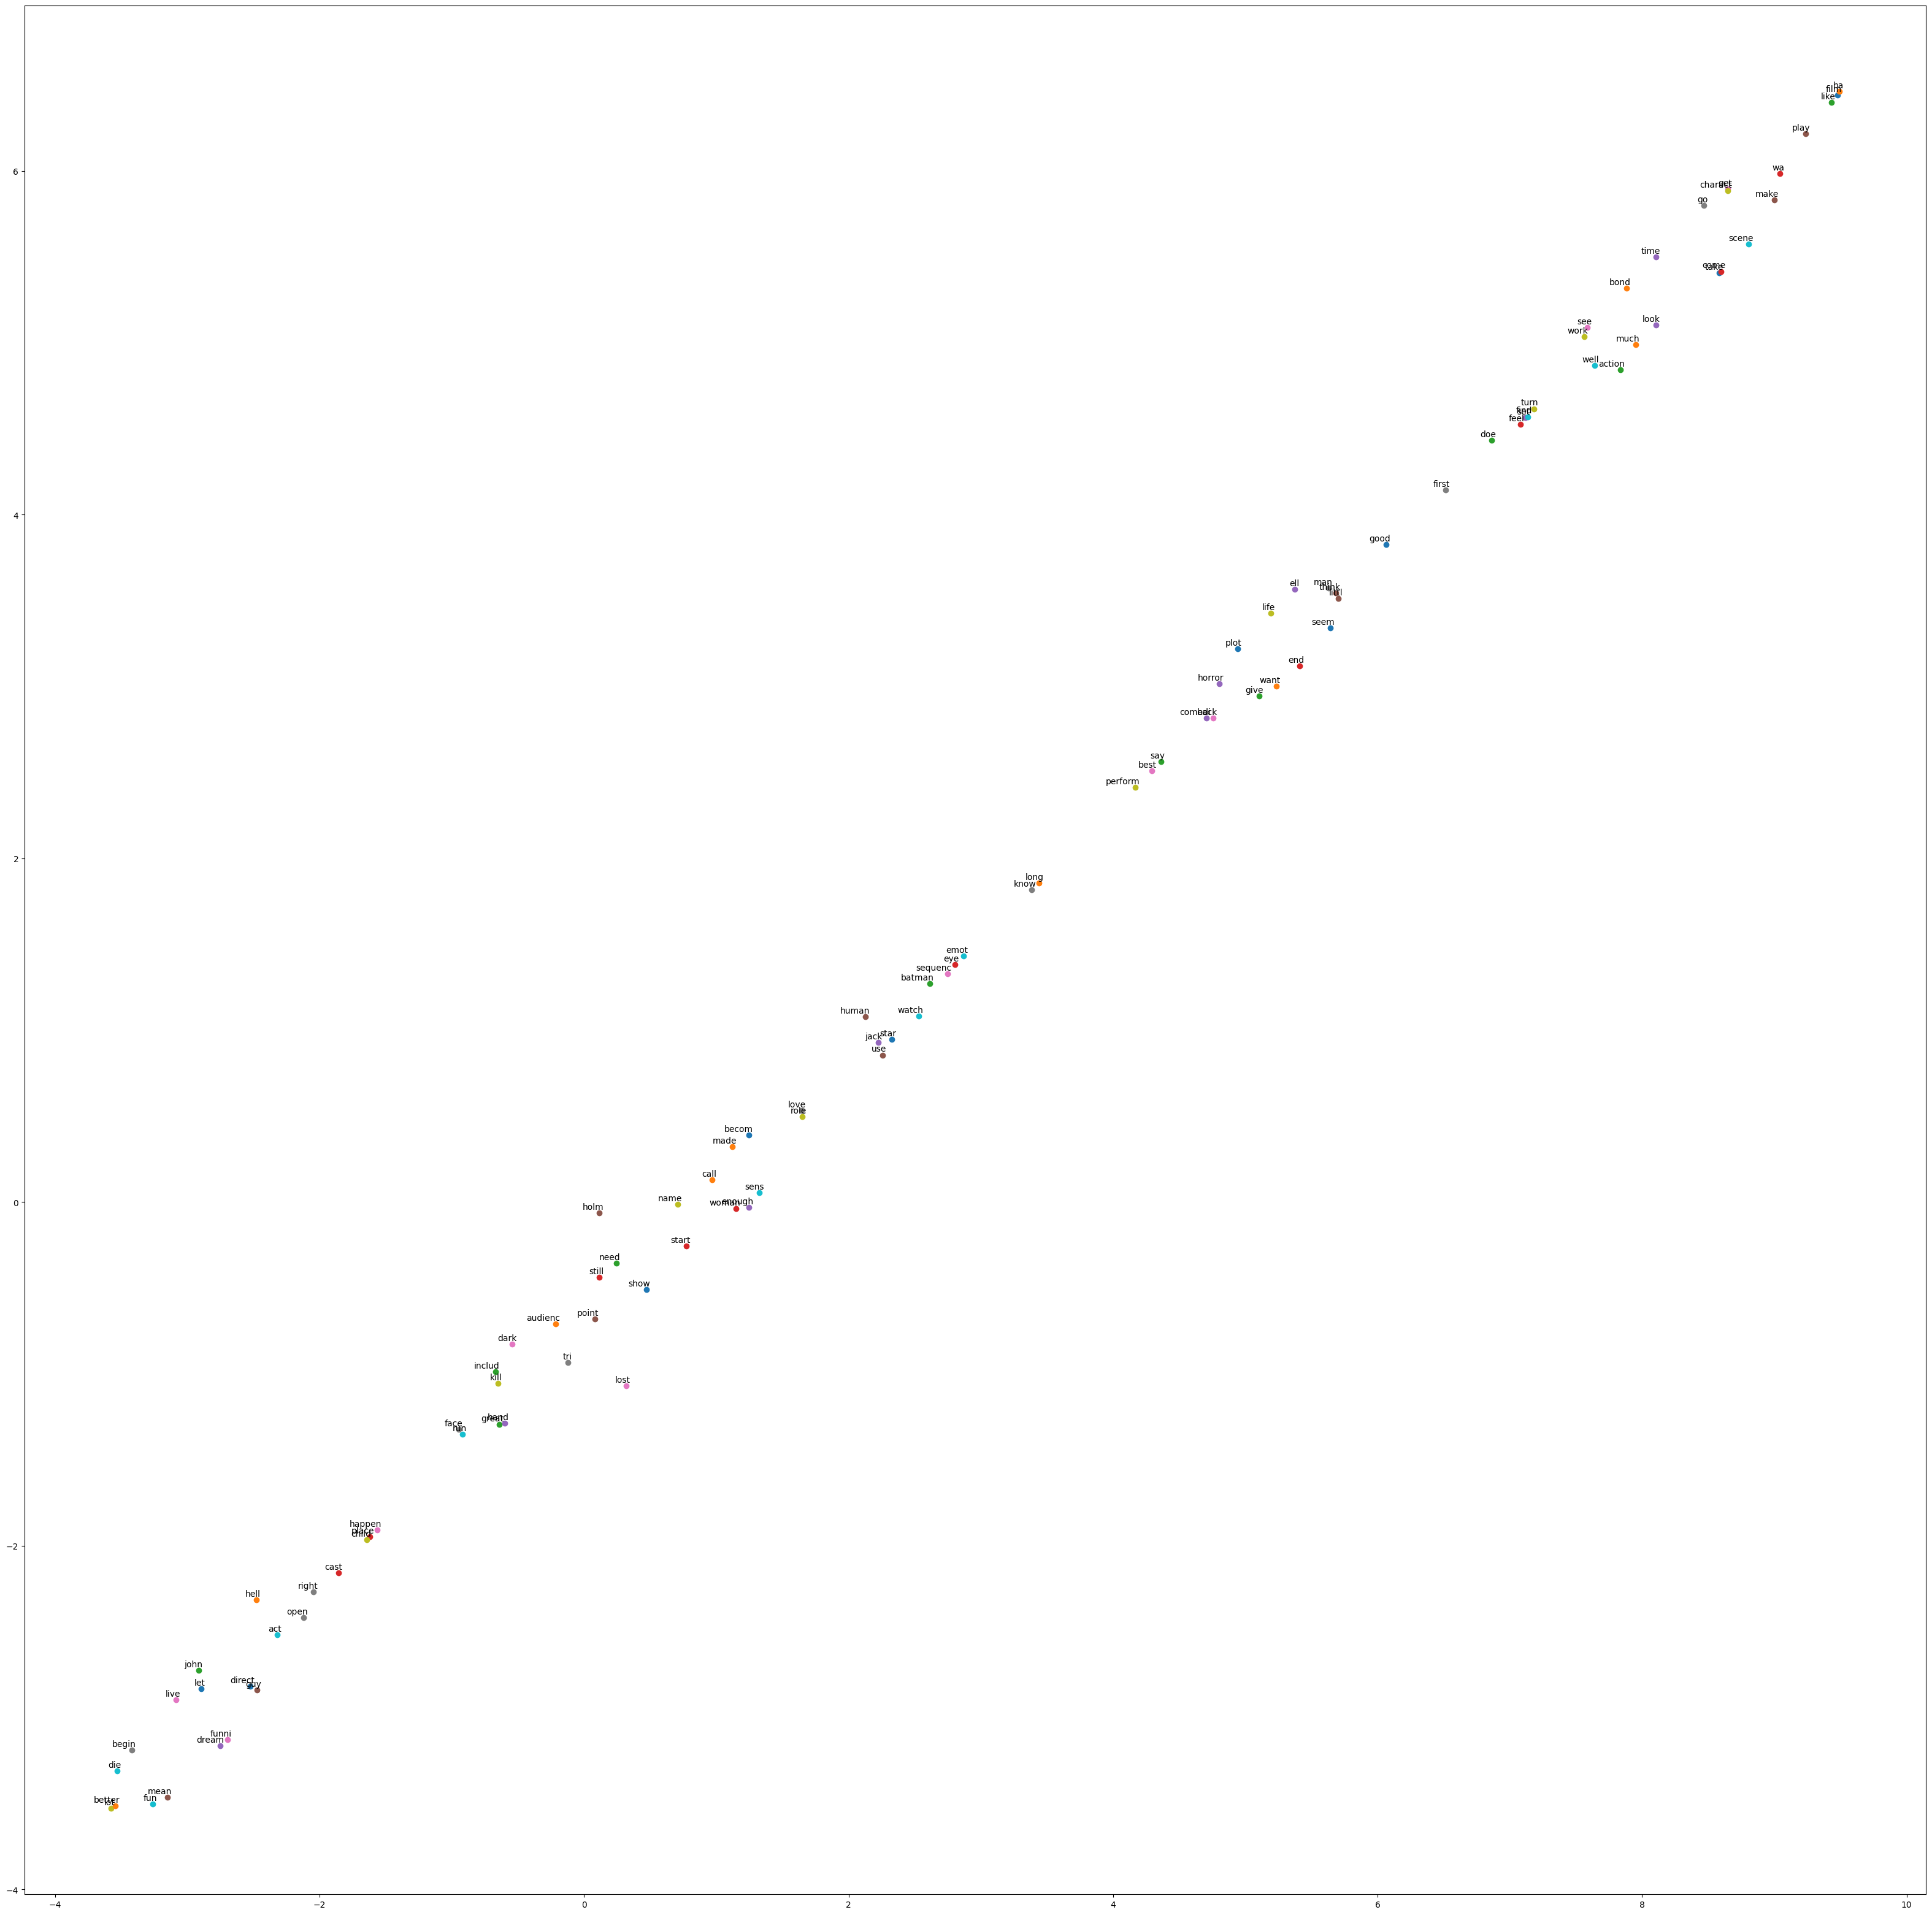

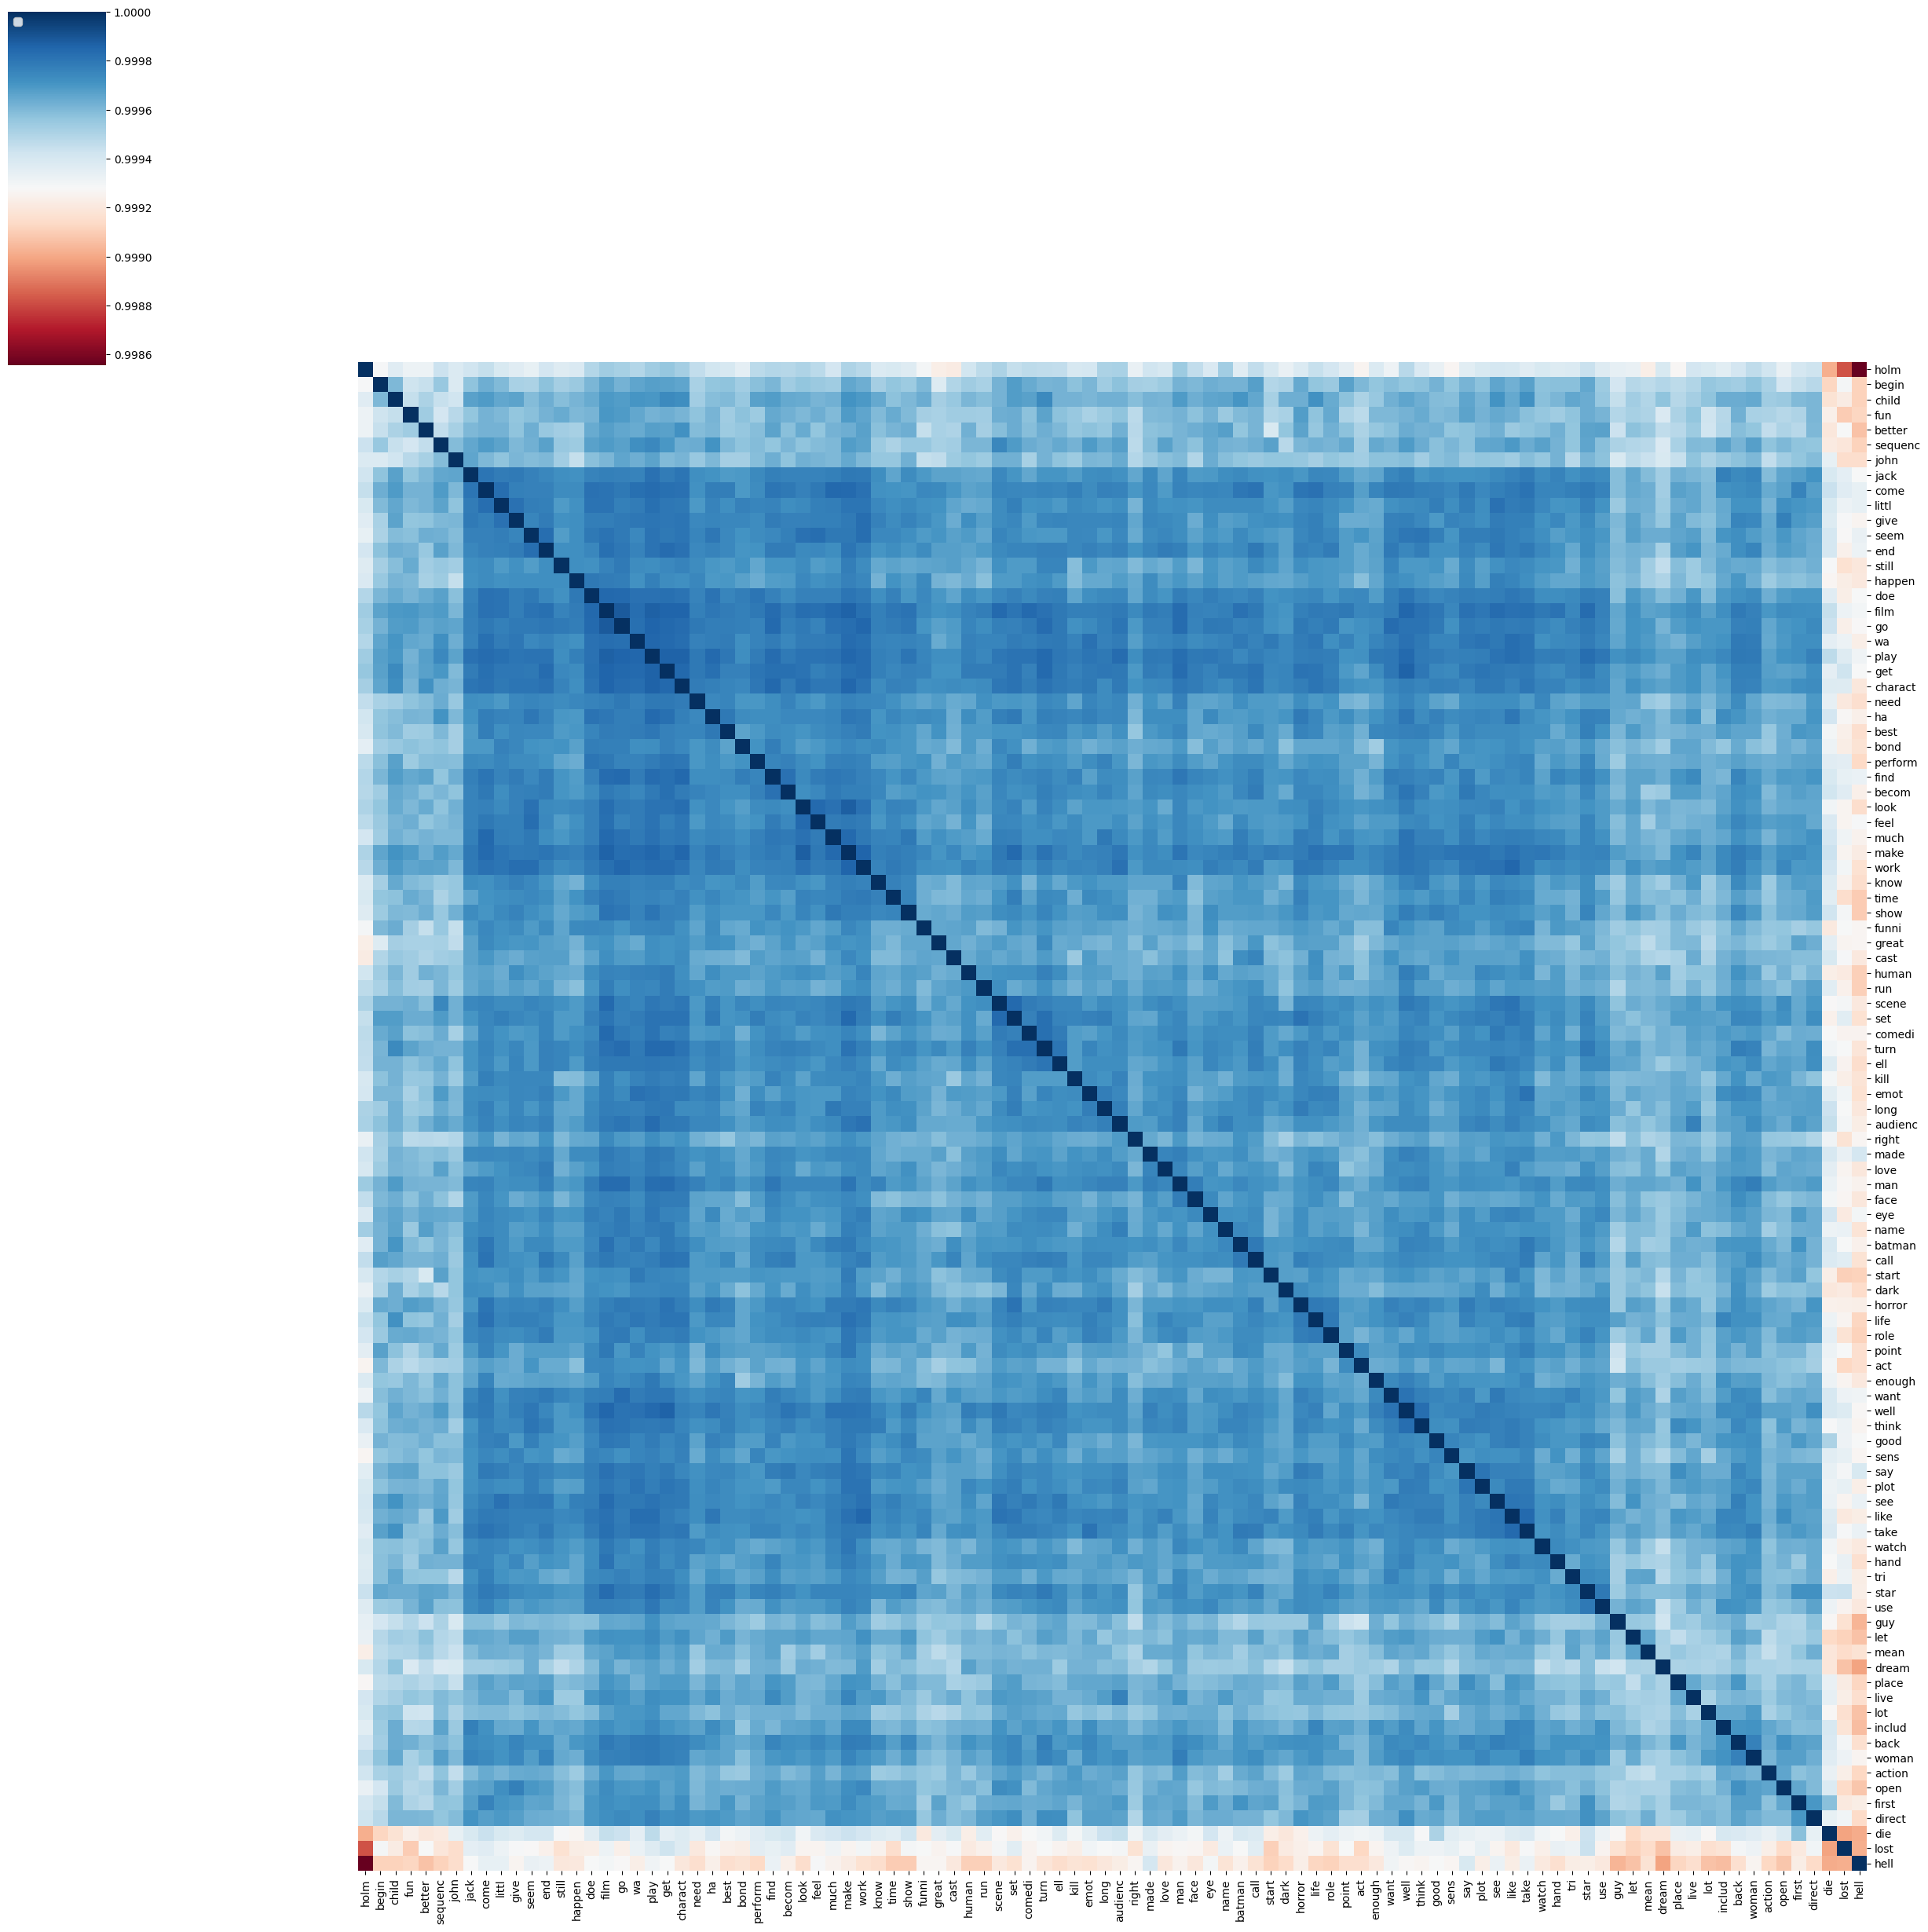

In [ ]:
# verbs
run_word2vec_experiment(documents, clean_method, 100, tokens_verbs, "W2V_verbs_100d")

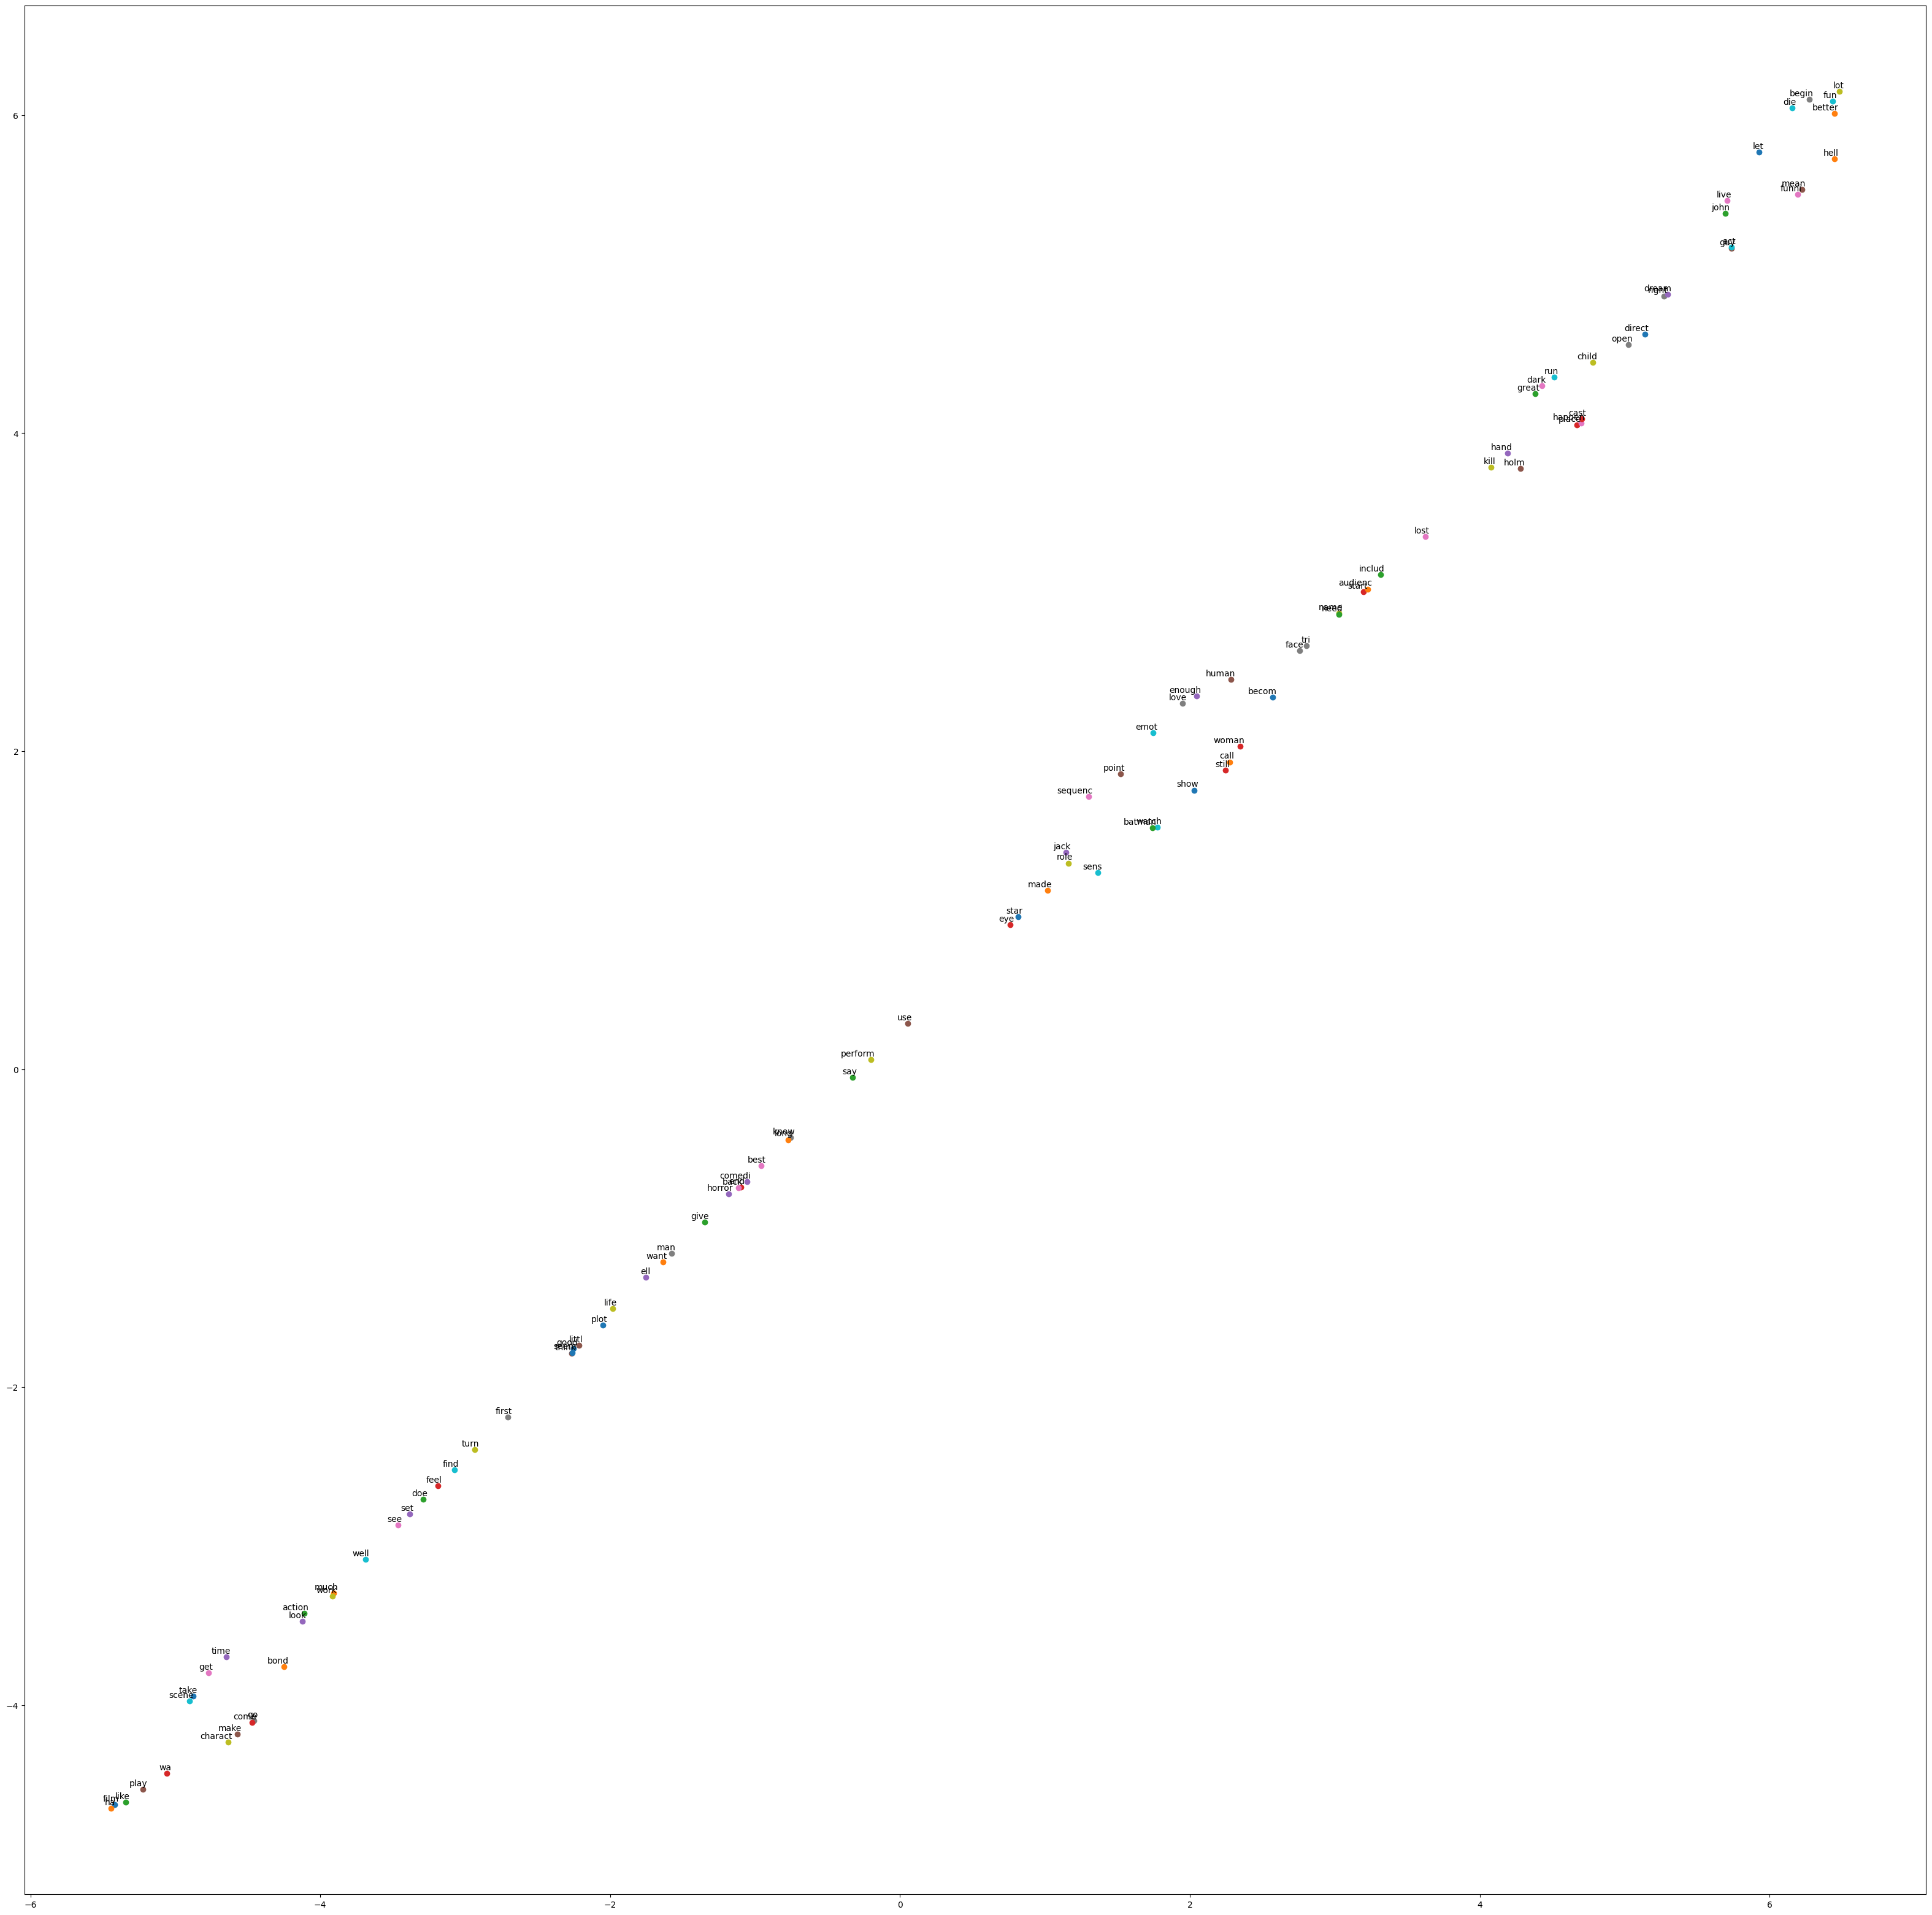

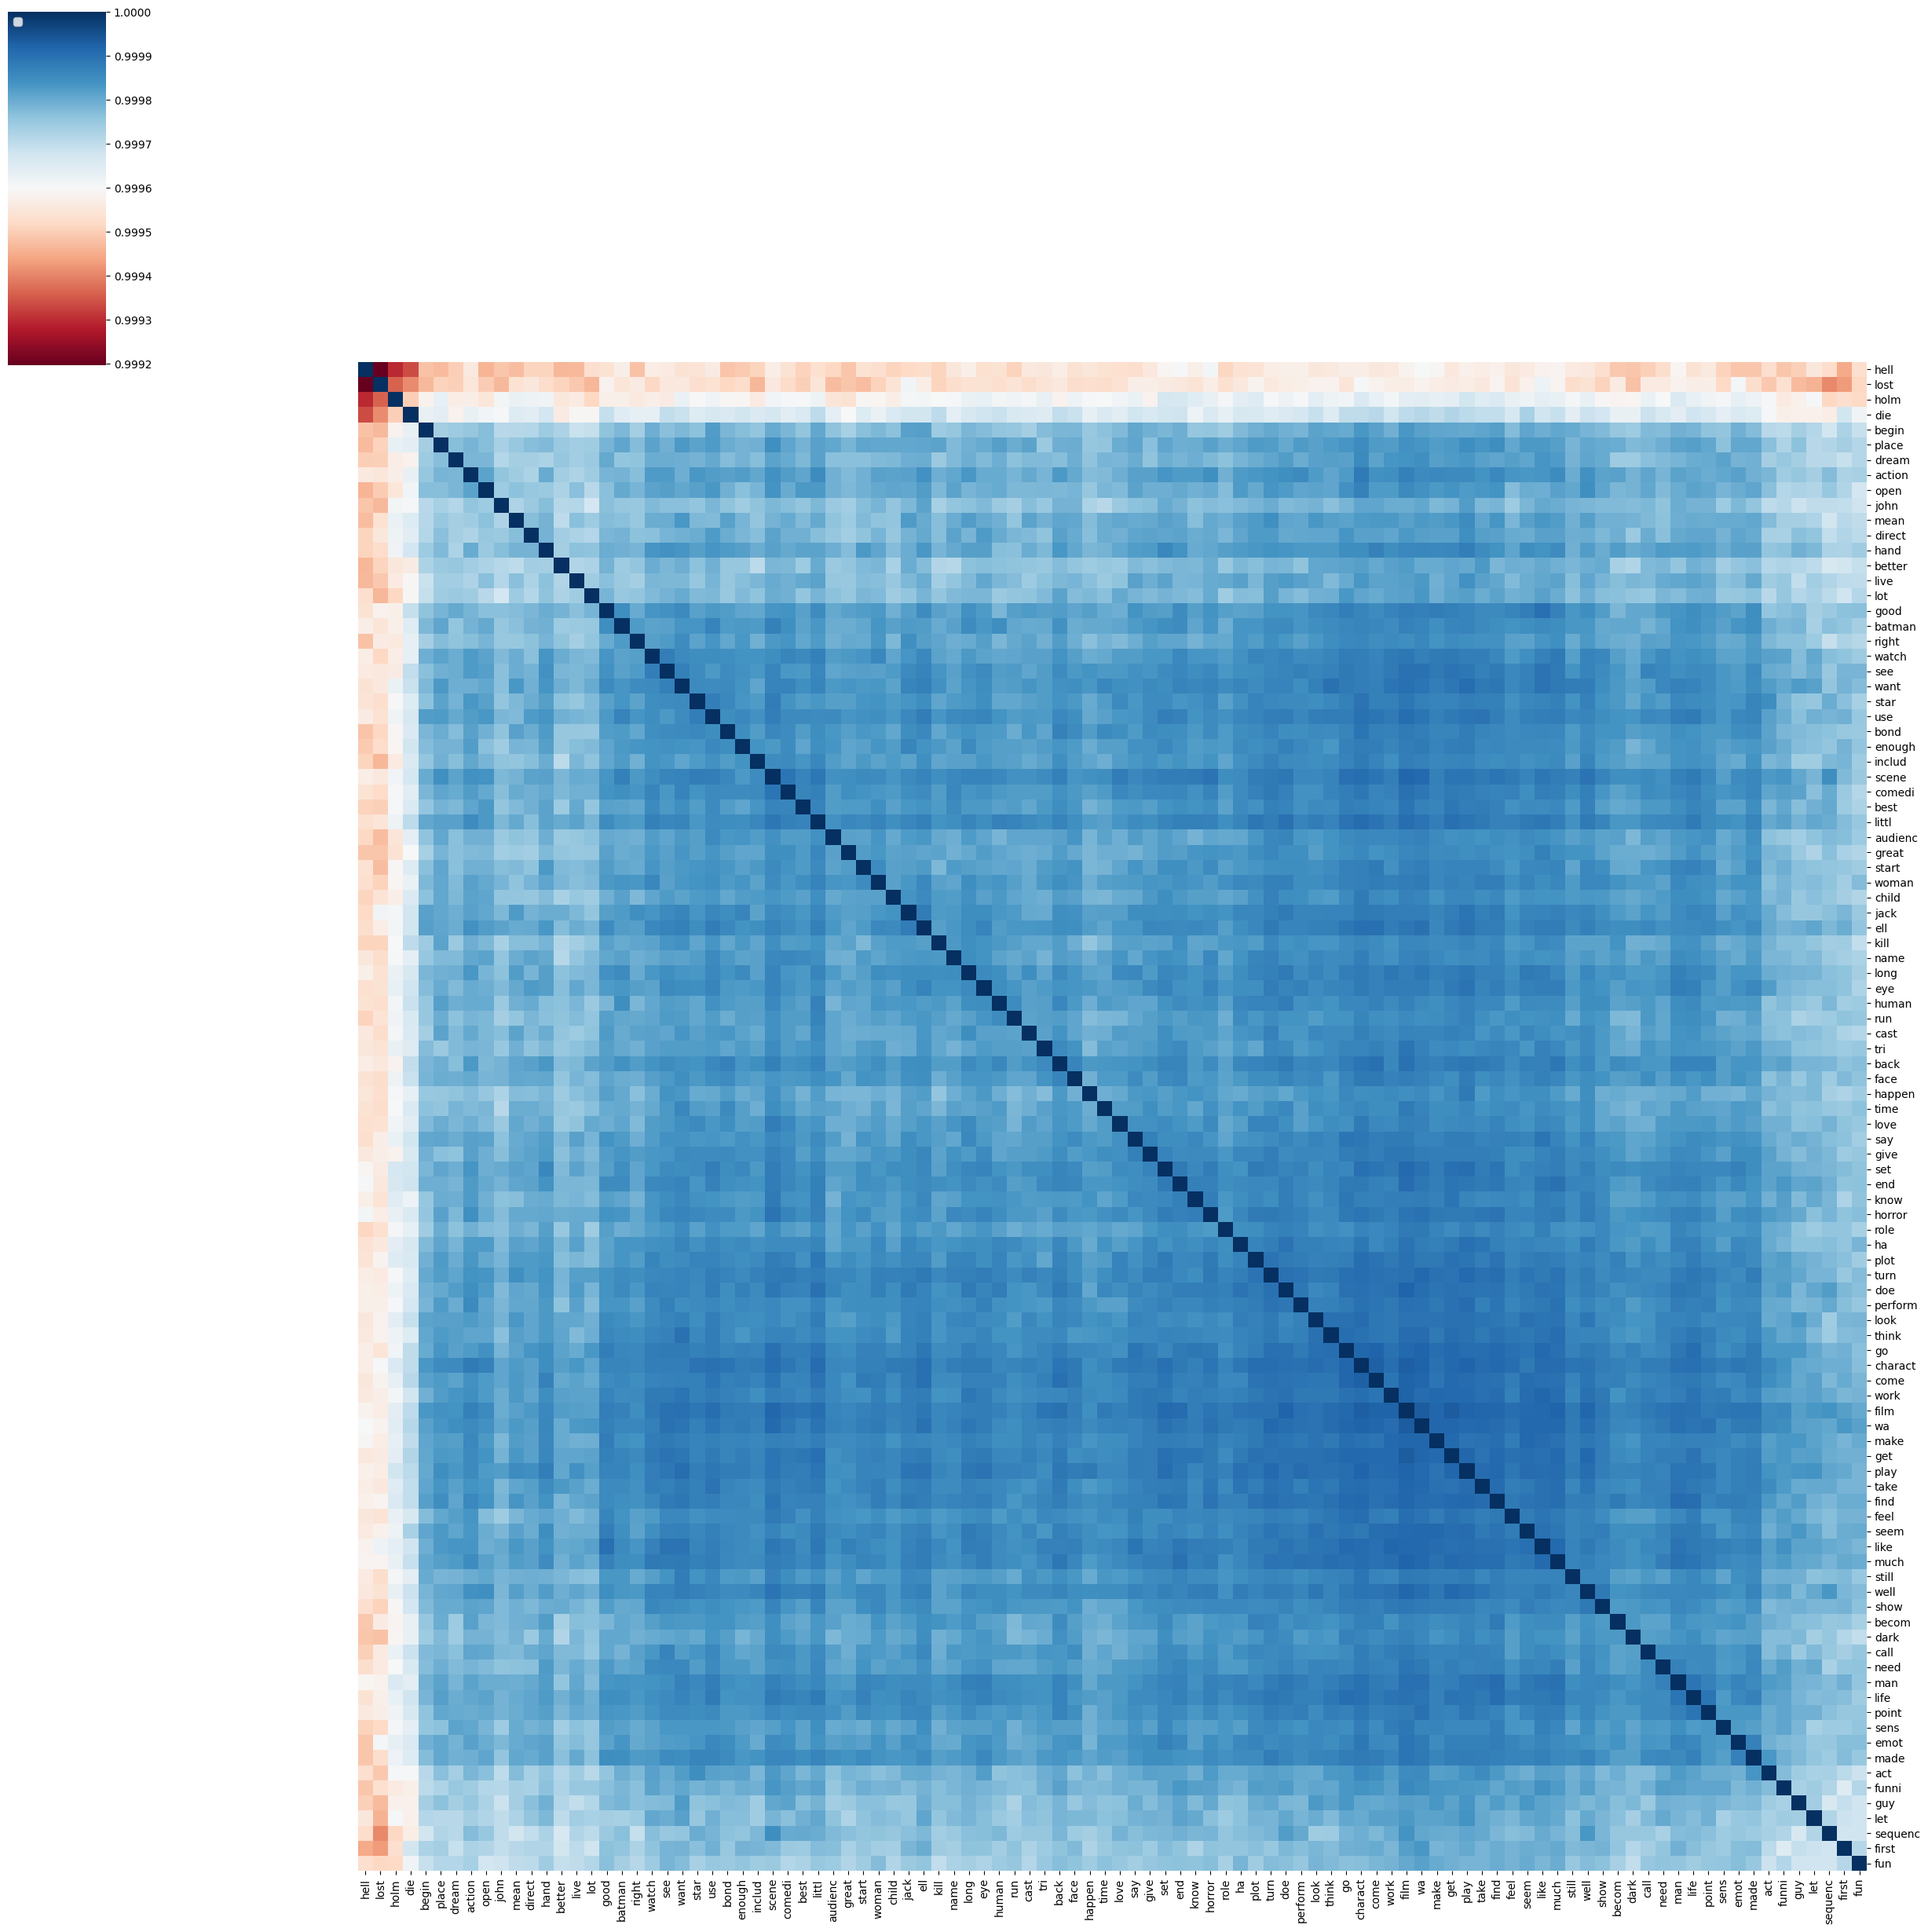

In [ ]:
run_word2vec_experiment(documents, clean_method, 200, tokens_verbs, "W2V_verbs_200d")

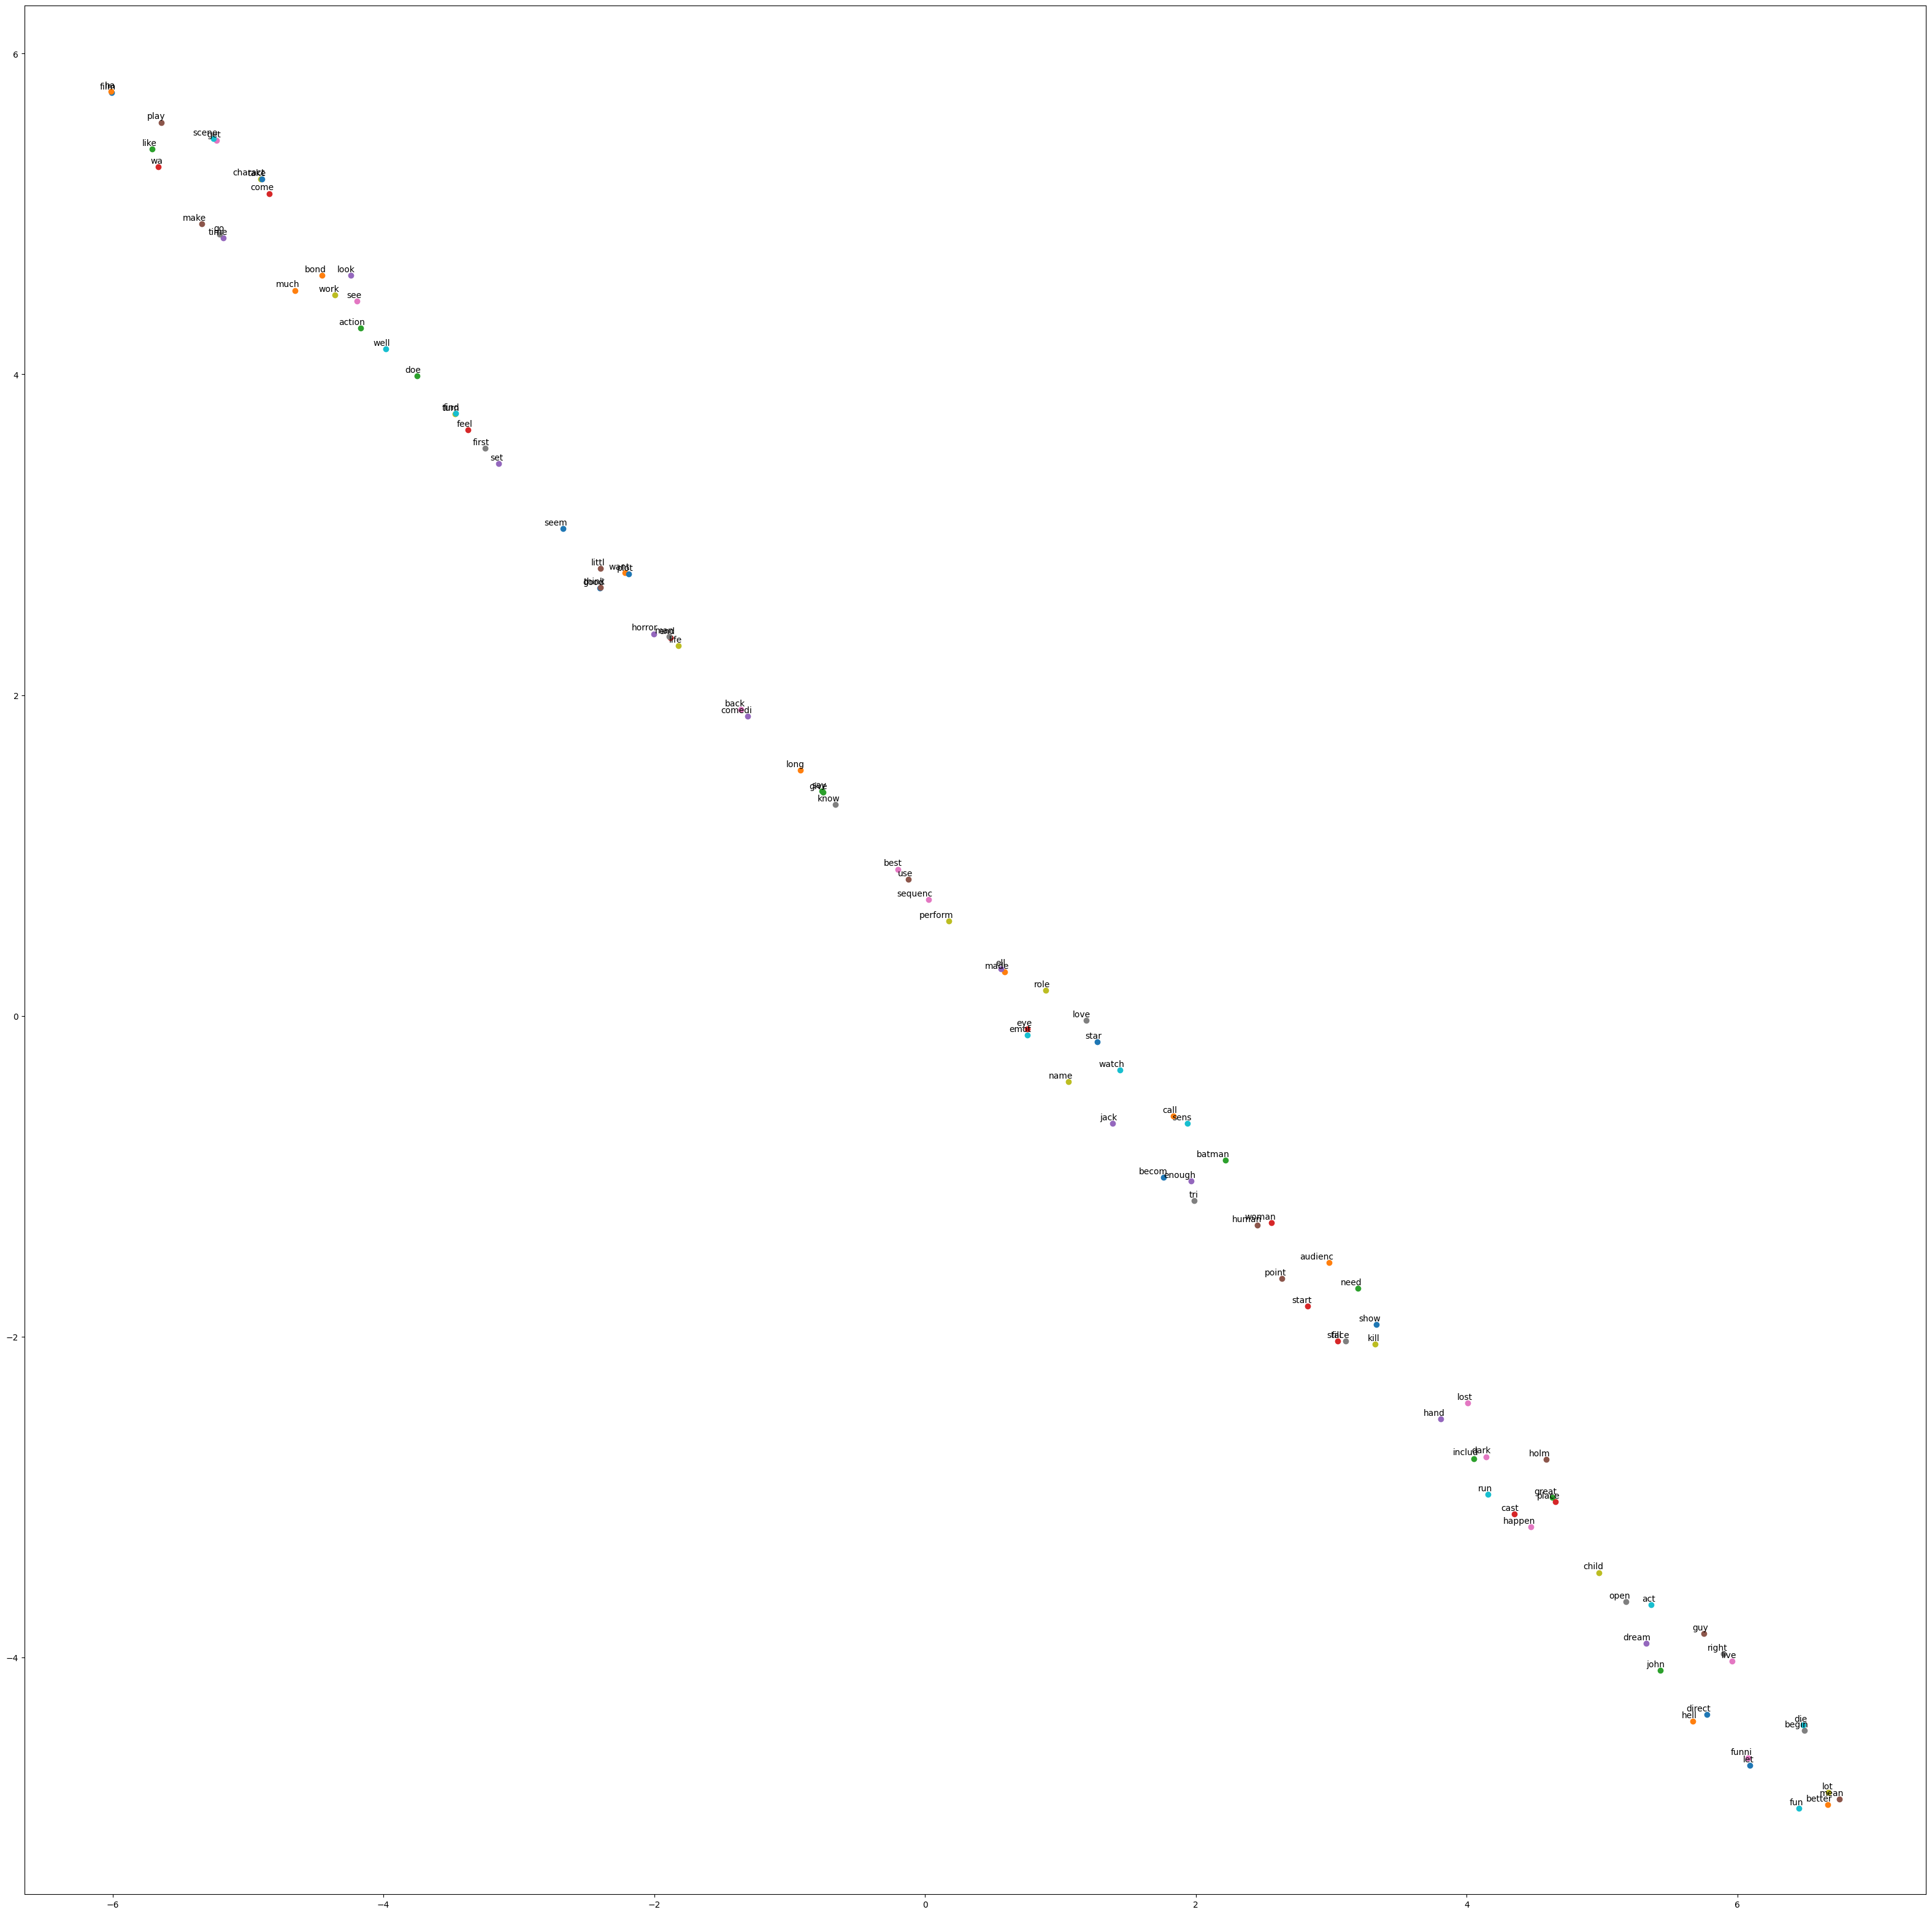

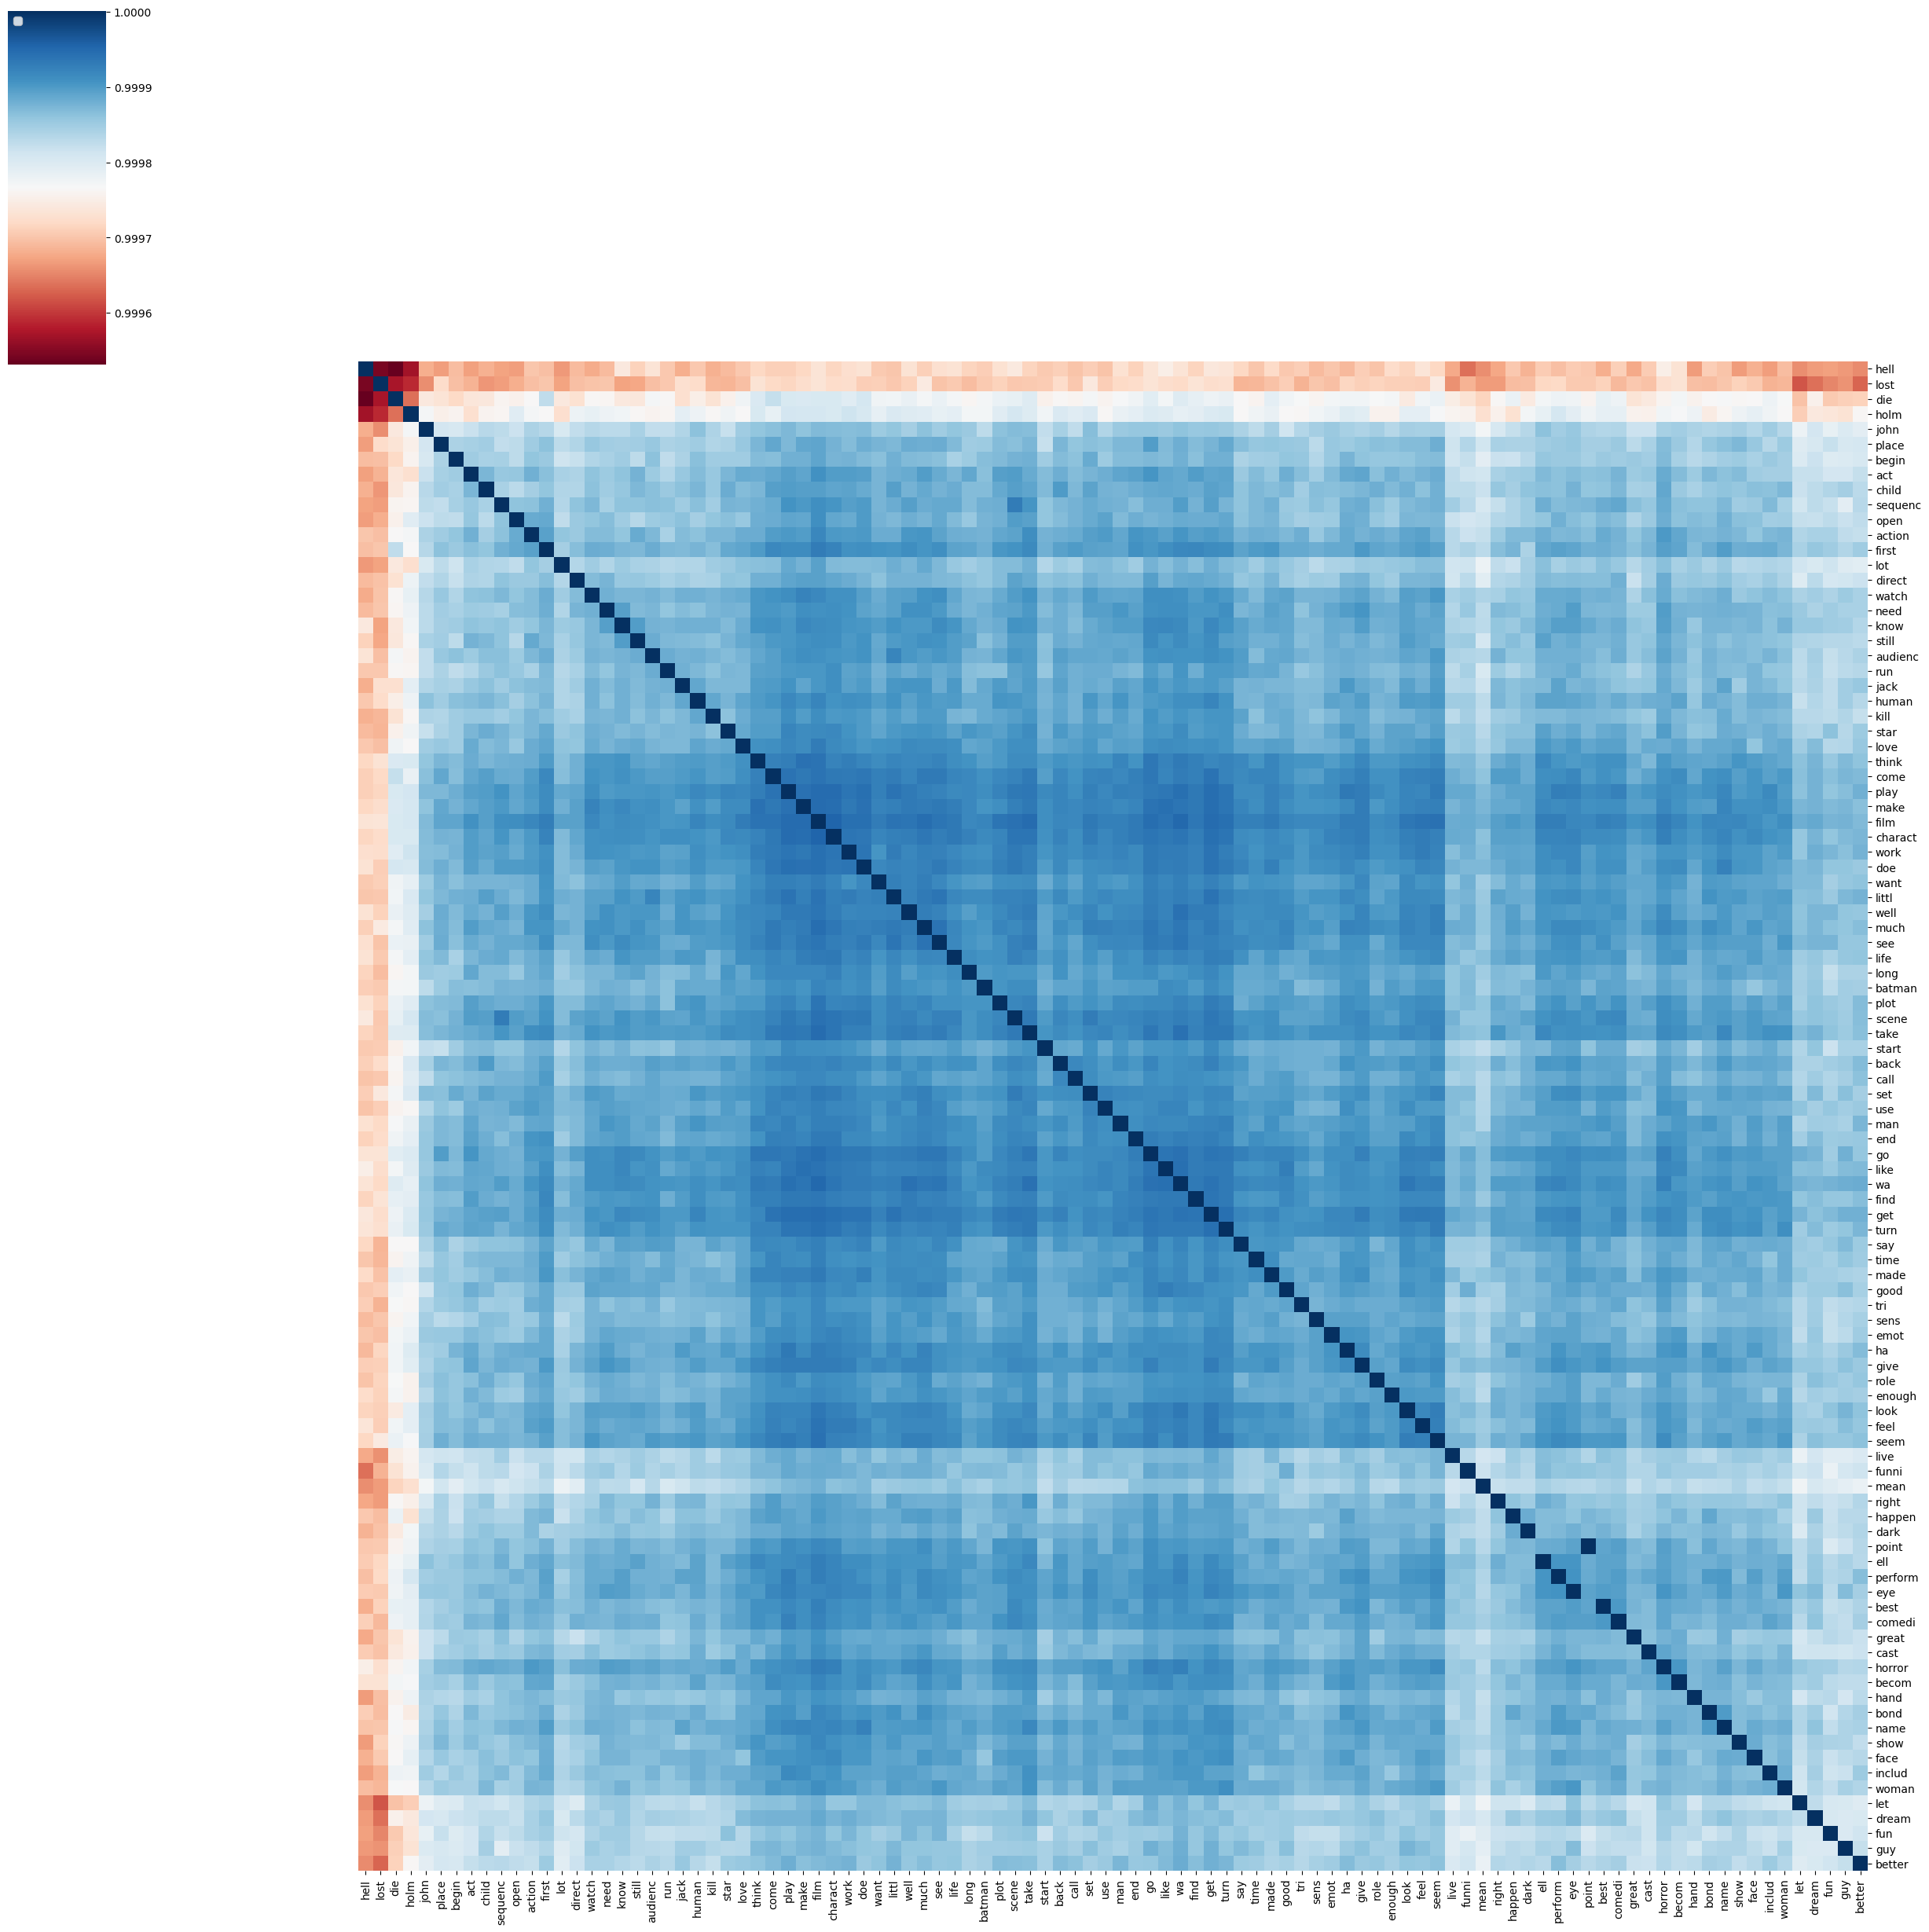

In [ ]:
run_word2vec_experiment(documents, clean_method, 300, tokens_verbs, "W2V_verbs_300d")

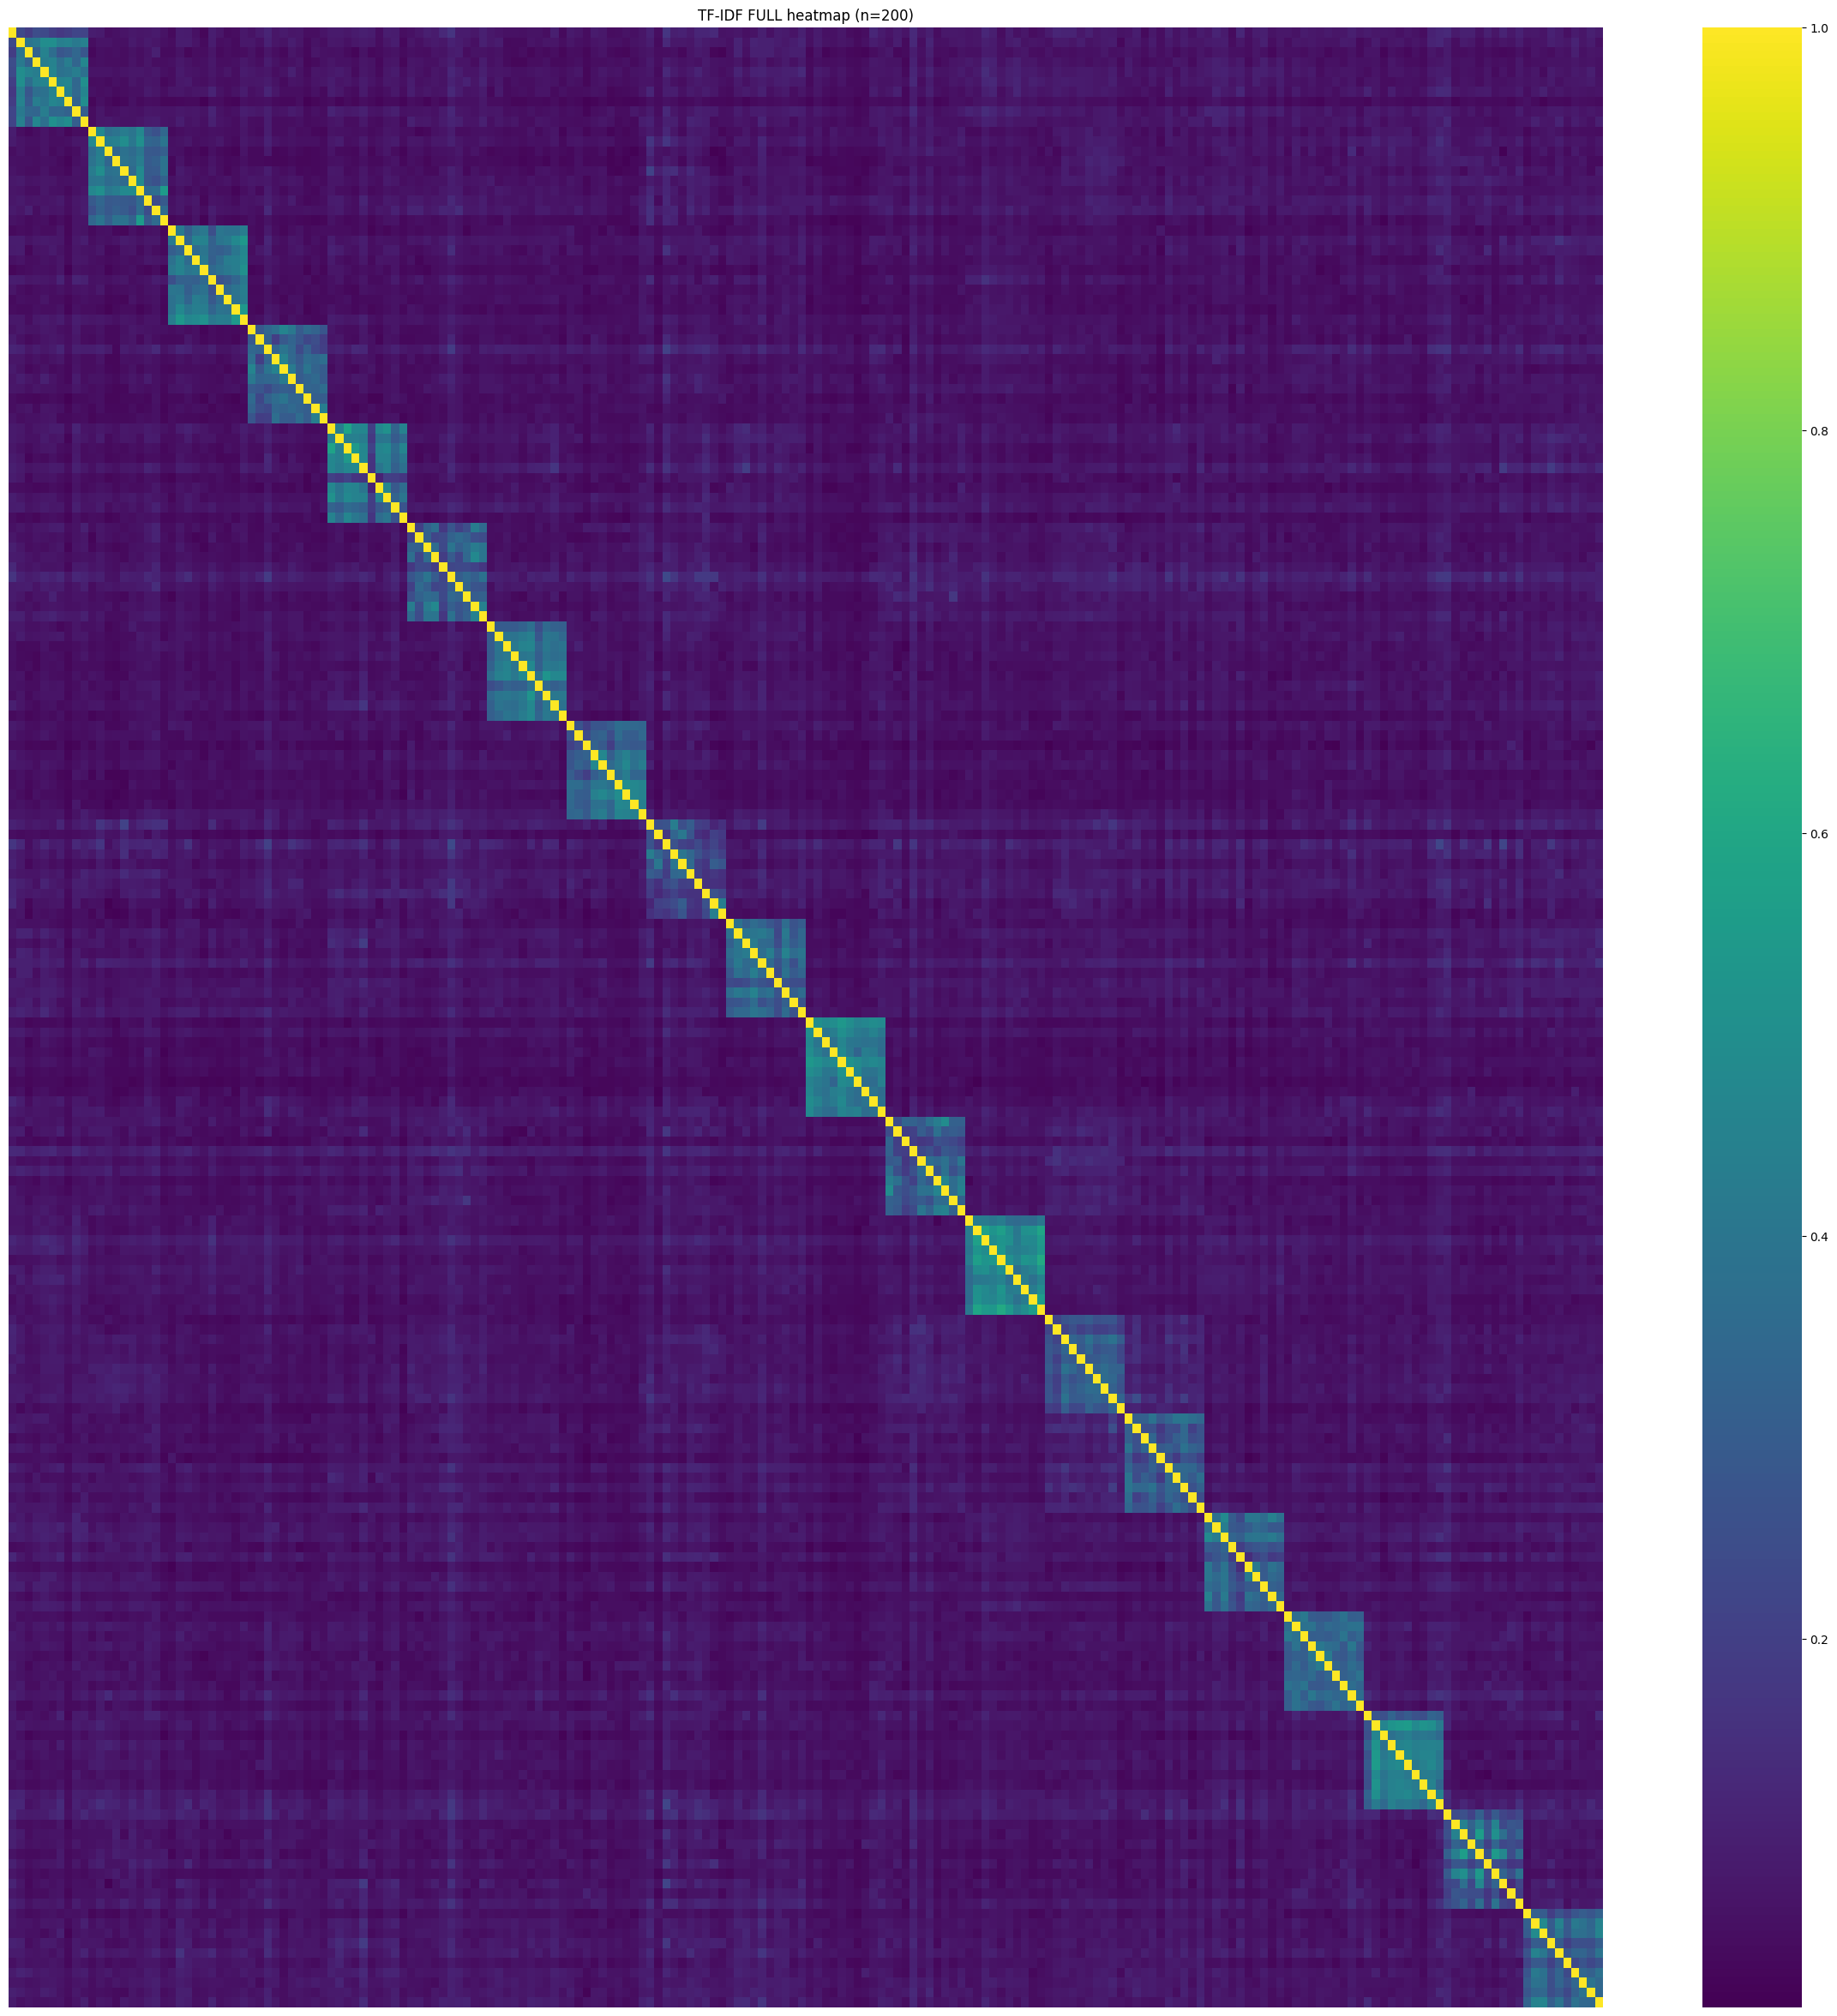

In [ ]:
# NEW

# TF-IDF document–document heatmaps: FULL and SUBSET
# Place immediately after: run_tfidf(documents, clean_method, important_prevalent_terms, 'TFIDF_exp')

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

def _build_tfidf_doc_df(docs):
    """Rebuild TF-IDF doc-term matrix using your cleaning config; index = Doc_ID."""
    cleaned = clean_method(docs)
    texts = [' '.join(x.tokens) for x in cleaned]
    vec = TfidfVectorizer(use_idf=True, ngram_range=(1, 1), norm=None)
    X = vec.fit_transform(texts).toarray()
    doc_ids = [d.doc_id for d in cleaned]
    df = pd.DataFrame(X, index=doc_ids, columns=vec.get_feature_names_out())
    return df

def _order_by_movie_title(df):
    """Stable order by movie title so same-movie blocks appear along the diagonal."""
    order = sorted(df.index, key=lambda i: (titles_by_doc_ids[i], i))
    return df.loc[order]

def _subset_one_per_movie(df, n=20):
    """Pick at most one representative doc per movie (first occurrence in the ordered list)."""
    seen, keep = set(), []
    for i in df.index:
        t = titles_by_doc_ids[i]
        if t not in seen:
            keep.append(i)
            seen.add(t)
        if len(keep) >= n:
            break
    return df.loc[keep]

def plot_similarity_matrix_unlabeled(data: pd.DataFrame, title: str, figsize=(30, 30)):
    """Same idea as your plot_similarity_matrix, but without tick labels (professor request)."""
    sims = cosine_similarity(data, data)
    fig, ax = plt.subplots(figsize=figsize)
    sns.heatmap(ax=ax, data=sims, xticklabels=False, yticklabels=False, cmap='viridis')
    ax.set_title(title)
    plt.show()

# --- compute once, then plot both views ---
tfidf_doc_df = _order_by_movie_title(_build_tfidf_doc_df(documents))

# FULL n x n (no labels)
plot_similarity_matrix_unlabeled(tfidf_doc_df, title=f"TF-IDF FULL heatmap (n={len(tfidf_doc_df)})")

# SUBSET (labeled with Movie#DocID) using your existing labeled plotter
subset_df = _subset_one_per_movie(tfidf_doc_df, n=20)
subset_labeled = subset_df.copy()
subset_labeled.index = [f"{titles_by_doc_ids[i]}#{i}" for i in subset_df.index]

# Reuse existing labeled plot (plot_similarity_matrix expects rows=items, columns=features)
plot_similarity_matrix(subset_labeled, experiment_name="TFIDF_SUBSET_20", figsize=(14, 12))

In [ ]:
extra_terms = [
    'bond',
    'craig',
    'star',
    'casino',
    'action'
]

In [ ]:
# Get our terms to examine in experiements 4-12
all_tokens = get_all_tokens(remove_stop_words(clean_method(documents)))
chosen_tokens = random.choices(all_tokens, k=100 - len(extra_terms)) + extra_terms

lemmatizer = WordNetLemmatizer()
lemmatized_chosen_tokens = [lemmatizer.lemmatize(x) for x in chosen_tokens]
stemmed_chosen_tokens = [stemmer.stem(x) for x in lemmatized_chosen_tokens]

## Word2Vec Experiments:


<div class="alert alert-block alert-success">
    <b>Word2vec embeddings</b>: https://radimrehurek.com/gensim/models/word2vec.html <br>
    This module implements the word2vec family of algorithms, using highly optimized C routines, data streaming and Pythonic interfaces.
            </div>

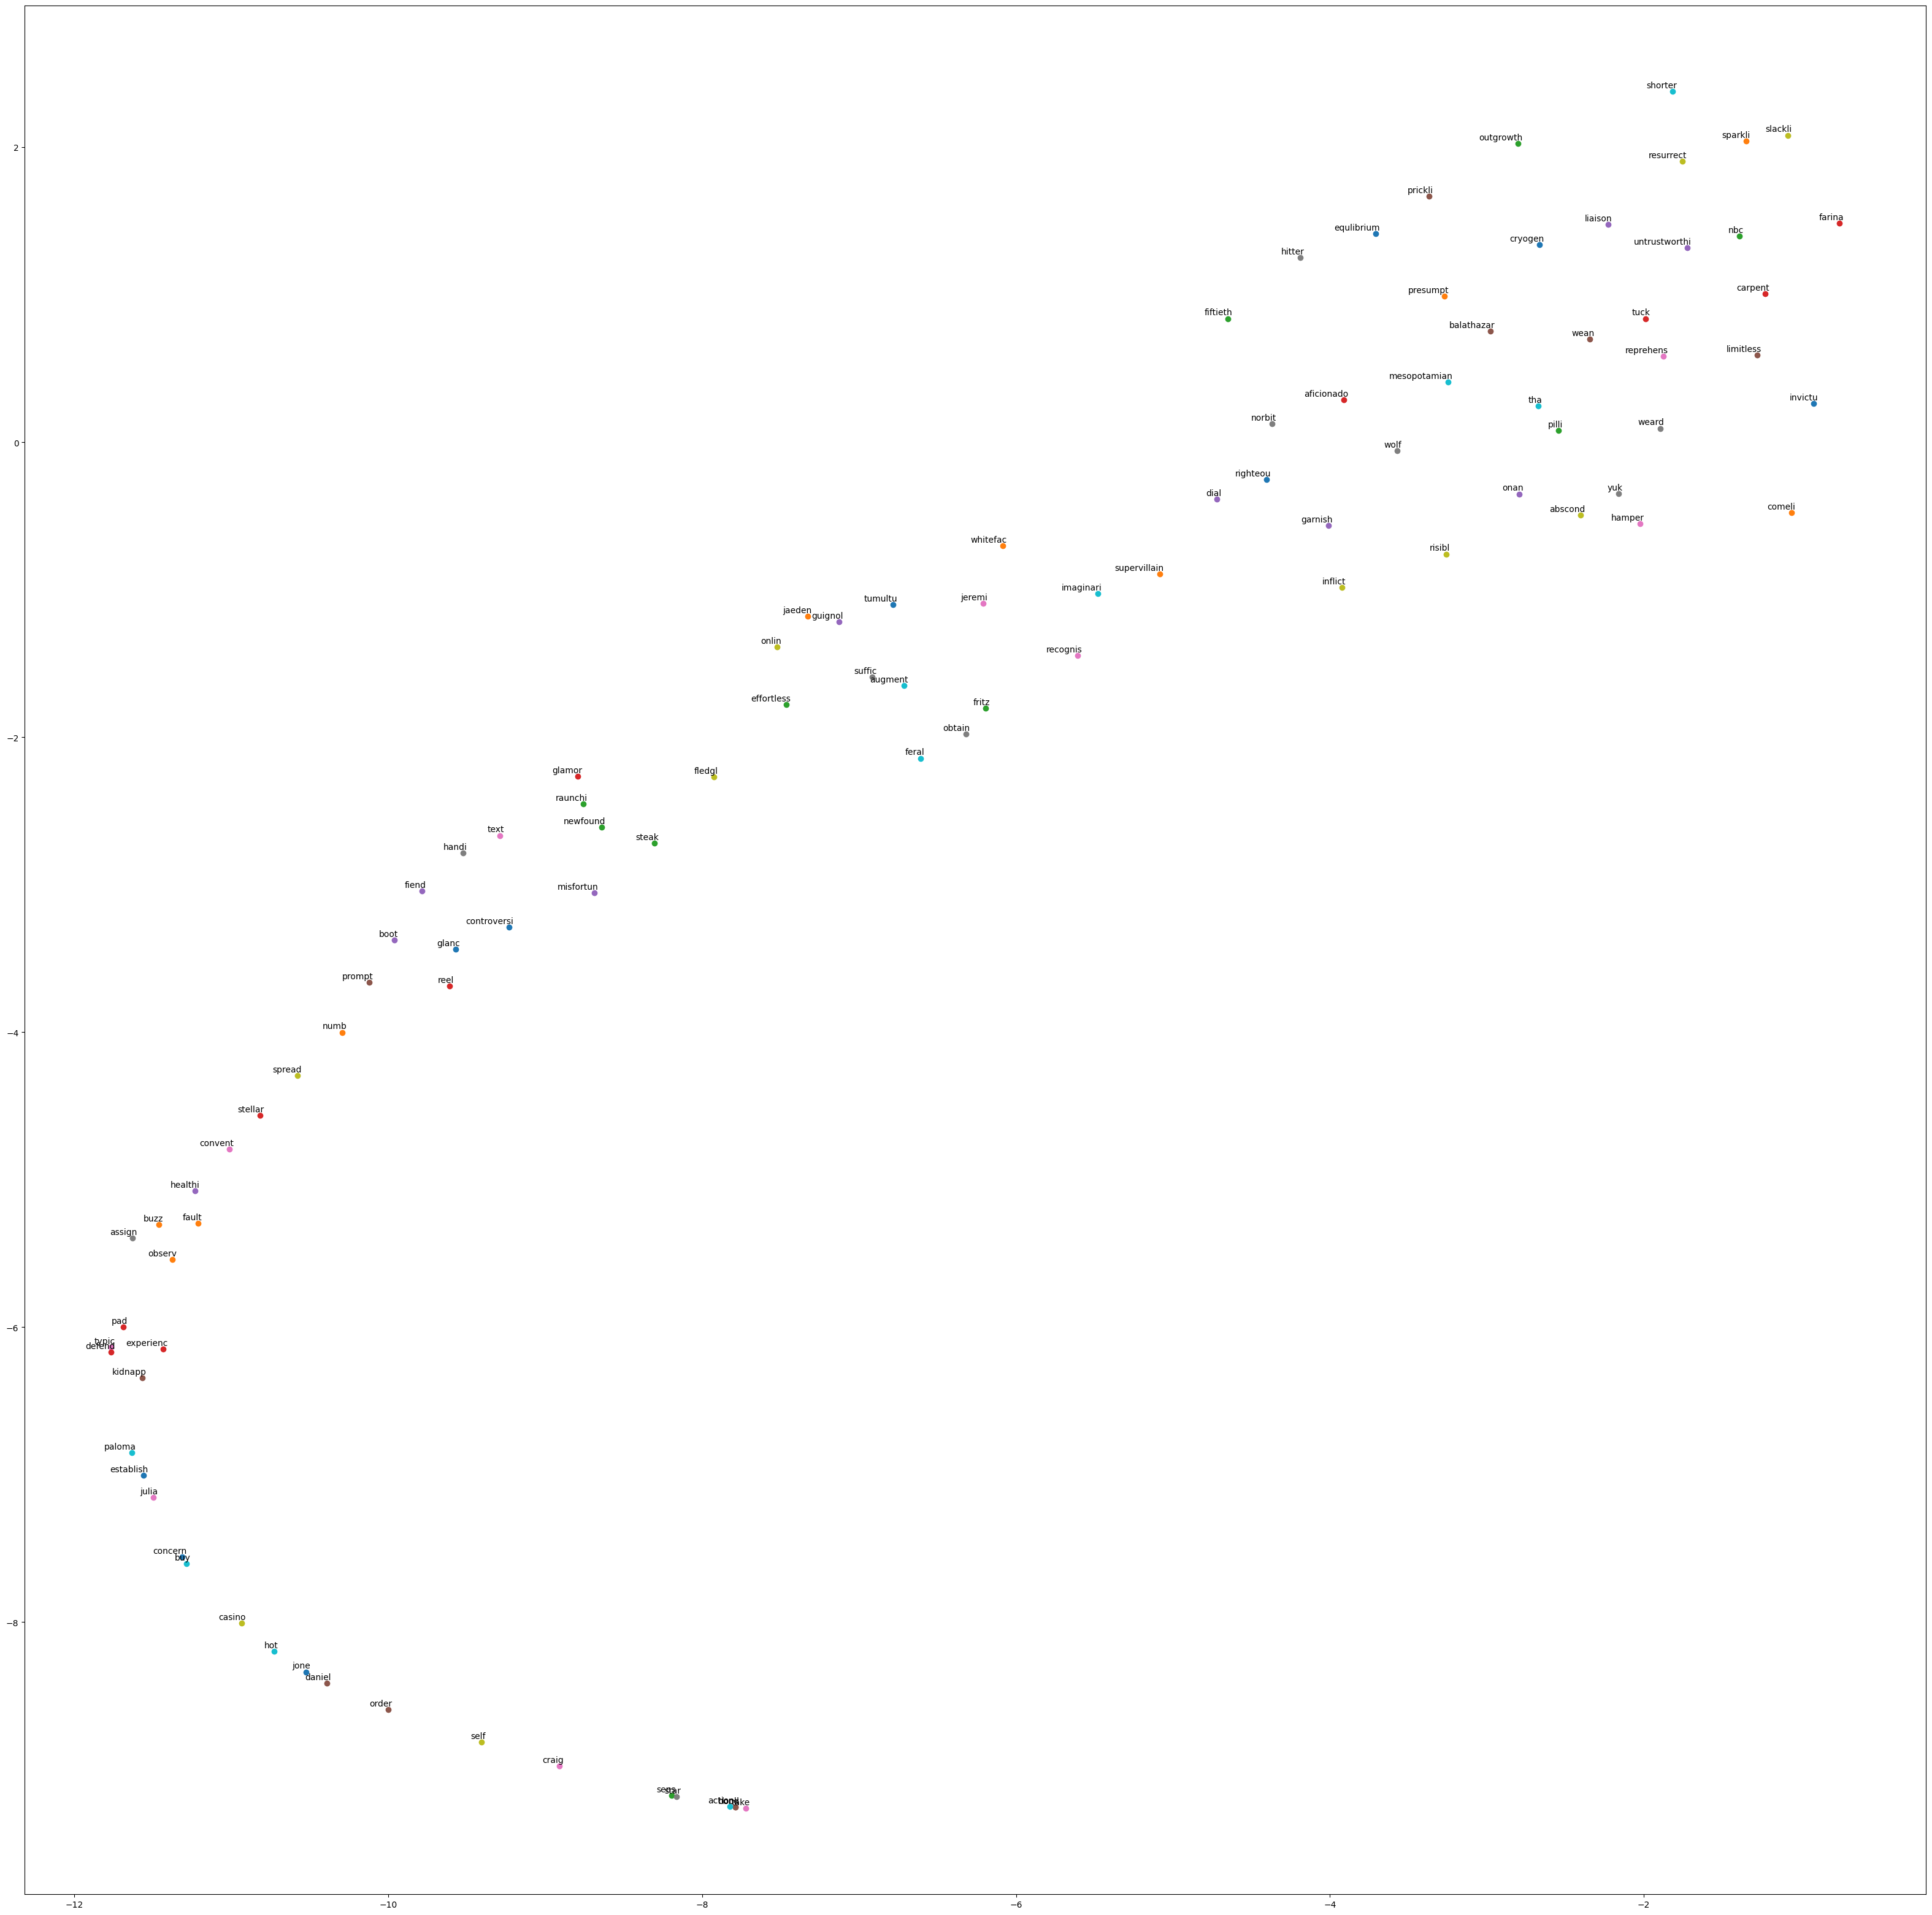

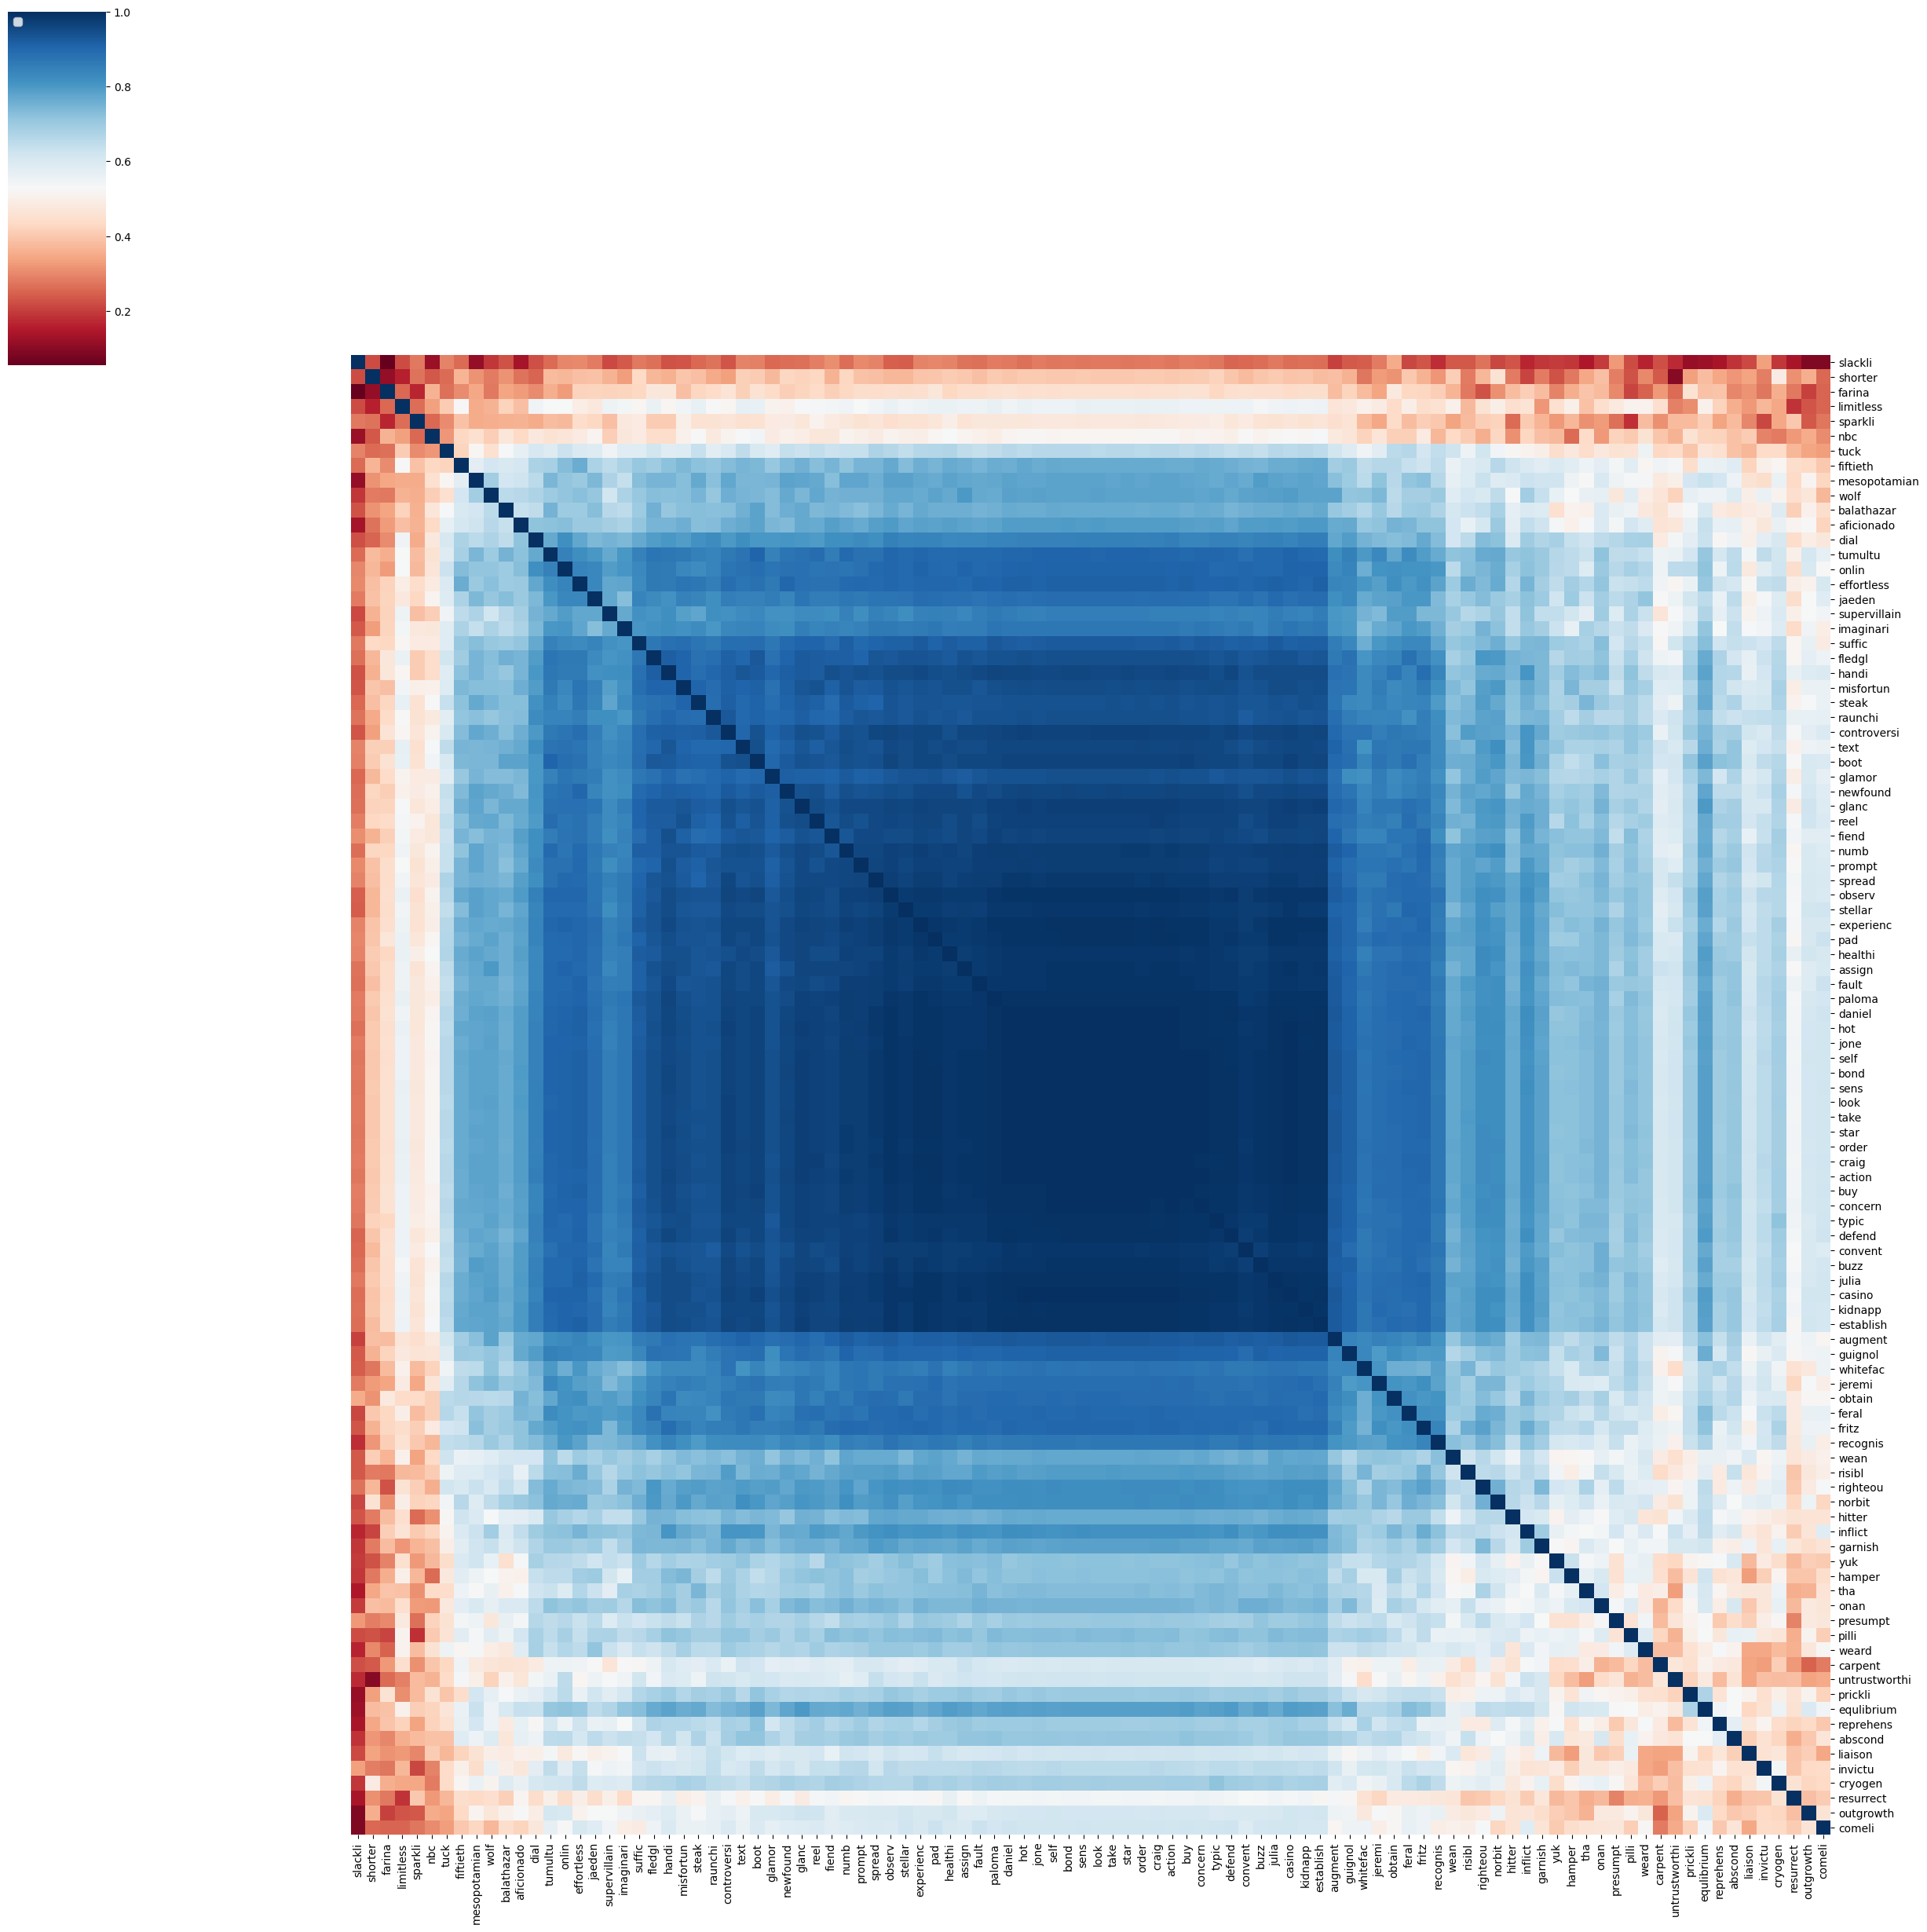

In [ ]:
run_word2vec_experiment(documents, clean_method, 100, chosen_tokens, 'Word2Vec_exp')

## Utility functions for Doc2Vec experiments

<div class="alert alert-block alert-success">
    <b>Doc2vec Paragraph Embeddings</b>: https://radimrehurek.com/gensim/models/doc2vec.html <br>
    Paragraph and document embeddings via the distributed memory and distributed bag of words models from Quoc Le and Tomas Mikolov: “Distributed Representations of Sentences and Documents”. <br>

The algorithms use either hierarchical softmax or negative sampling;
            </div>

In [ ]:
def run_doc2vec(documents: List[TokenizedDocument], embedding_size: int, descriptors_by_doc_ids: Dict[int, str]):
    tagged_documents = [TaggedDocument(document.tokens, [i]) for i, document in enumerate(documents)]
    doc2vec_model = Doc2Vec(tagged_documents, vector_size=embedding_size, window=3, min_count=2, workers=12)

    doc2vec_df = pd.DataFrame()
    for document in documents:
        vector = pd.DataFrame(doc2vec_model.infer_vector(document.tokens)).transpose()
        doc2vec_df = pd.concat([doc2vec_df, vector], axis=0)

    doc2vec_df['Descriptor'] = [descriptors_by_doc_ids[x.doc_id] for x in documents]
    doc2vec_df.set_index(['Descriptor'], inplace=True)
    return doc2vec_df

def run_doc2vec_experiment(documents: List[Document],
                           clean_func: Callable[[List[Document]], List[TokenizedDocument]],
                           embedding_size: int,
                           experiment_name: str):
    cleaned_documents = clean_func(documents)
    doc2vec_df = run_doc2vec(cleaned_documents, embedding_size, descriptors_by_doc_ids)

    plot_similarity_matrix(doc2vec_df, experiment_name)
    plot_similarity_clustermap(doc2vec_df, experiment_name, figsize=(50, 50))
    plot_tsne(doc2vec_df, 30, experiment_name)

## Doc2Vec Experiments:

<div class="alert alert-block alert-success">
    <b>Doc2vec Paragraph Embeddings</b>: https://radimrehurek.com/gensim/models/doc2vec.html <br>
    Paragraph and document embeddings via the distributed memory and distributed bag of words models from Quoc Le and Tomas Mikolov: “Distributed Representations of Sentences and Documents”. <br>

The algorithms use either hierarchical softmax or negative sampling;
            </div>

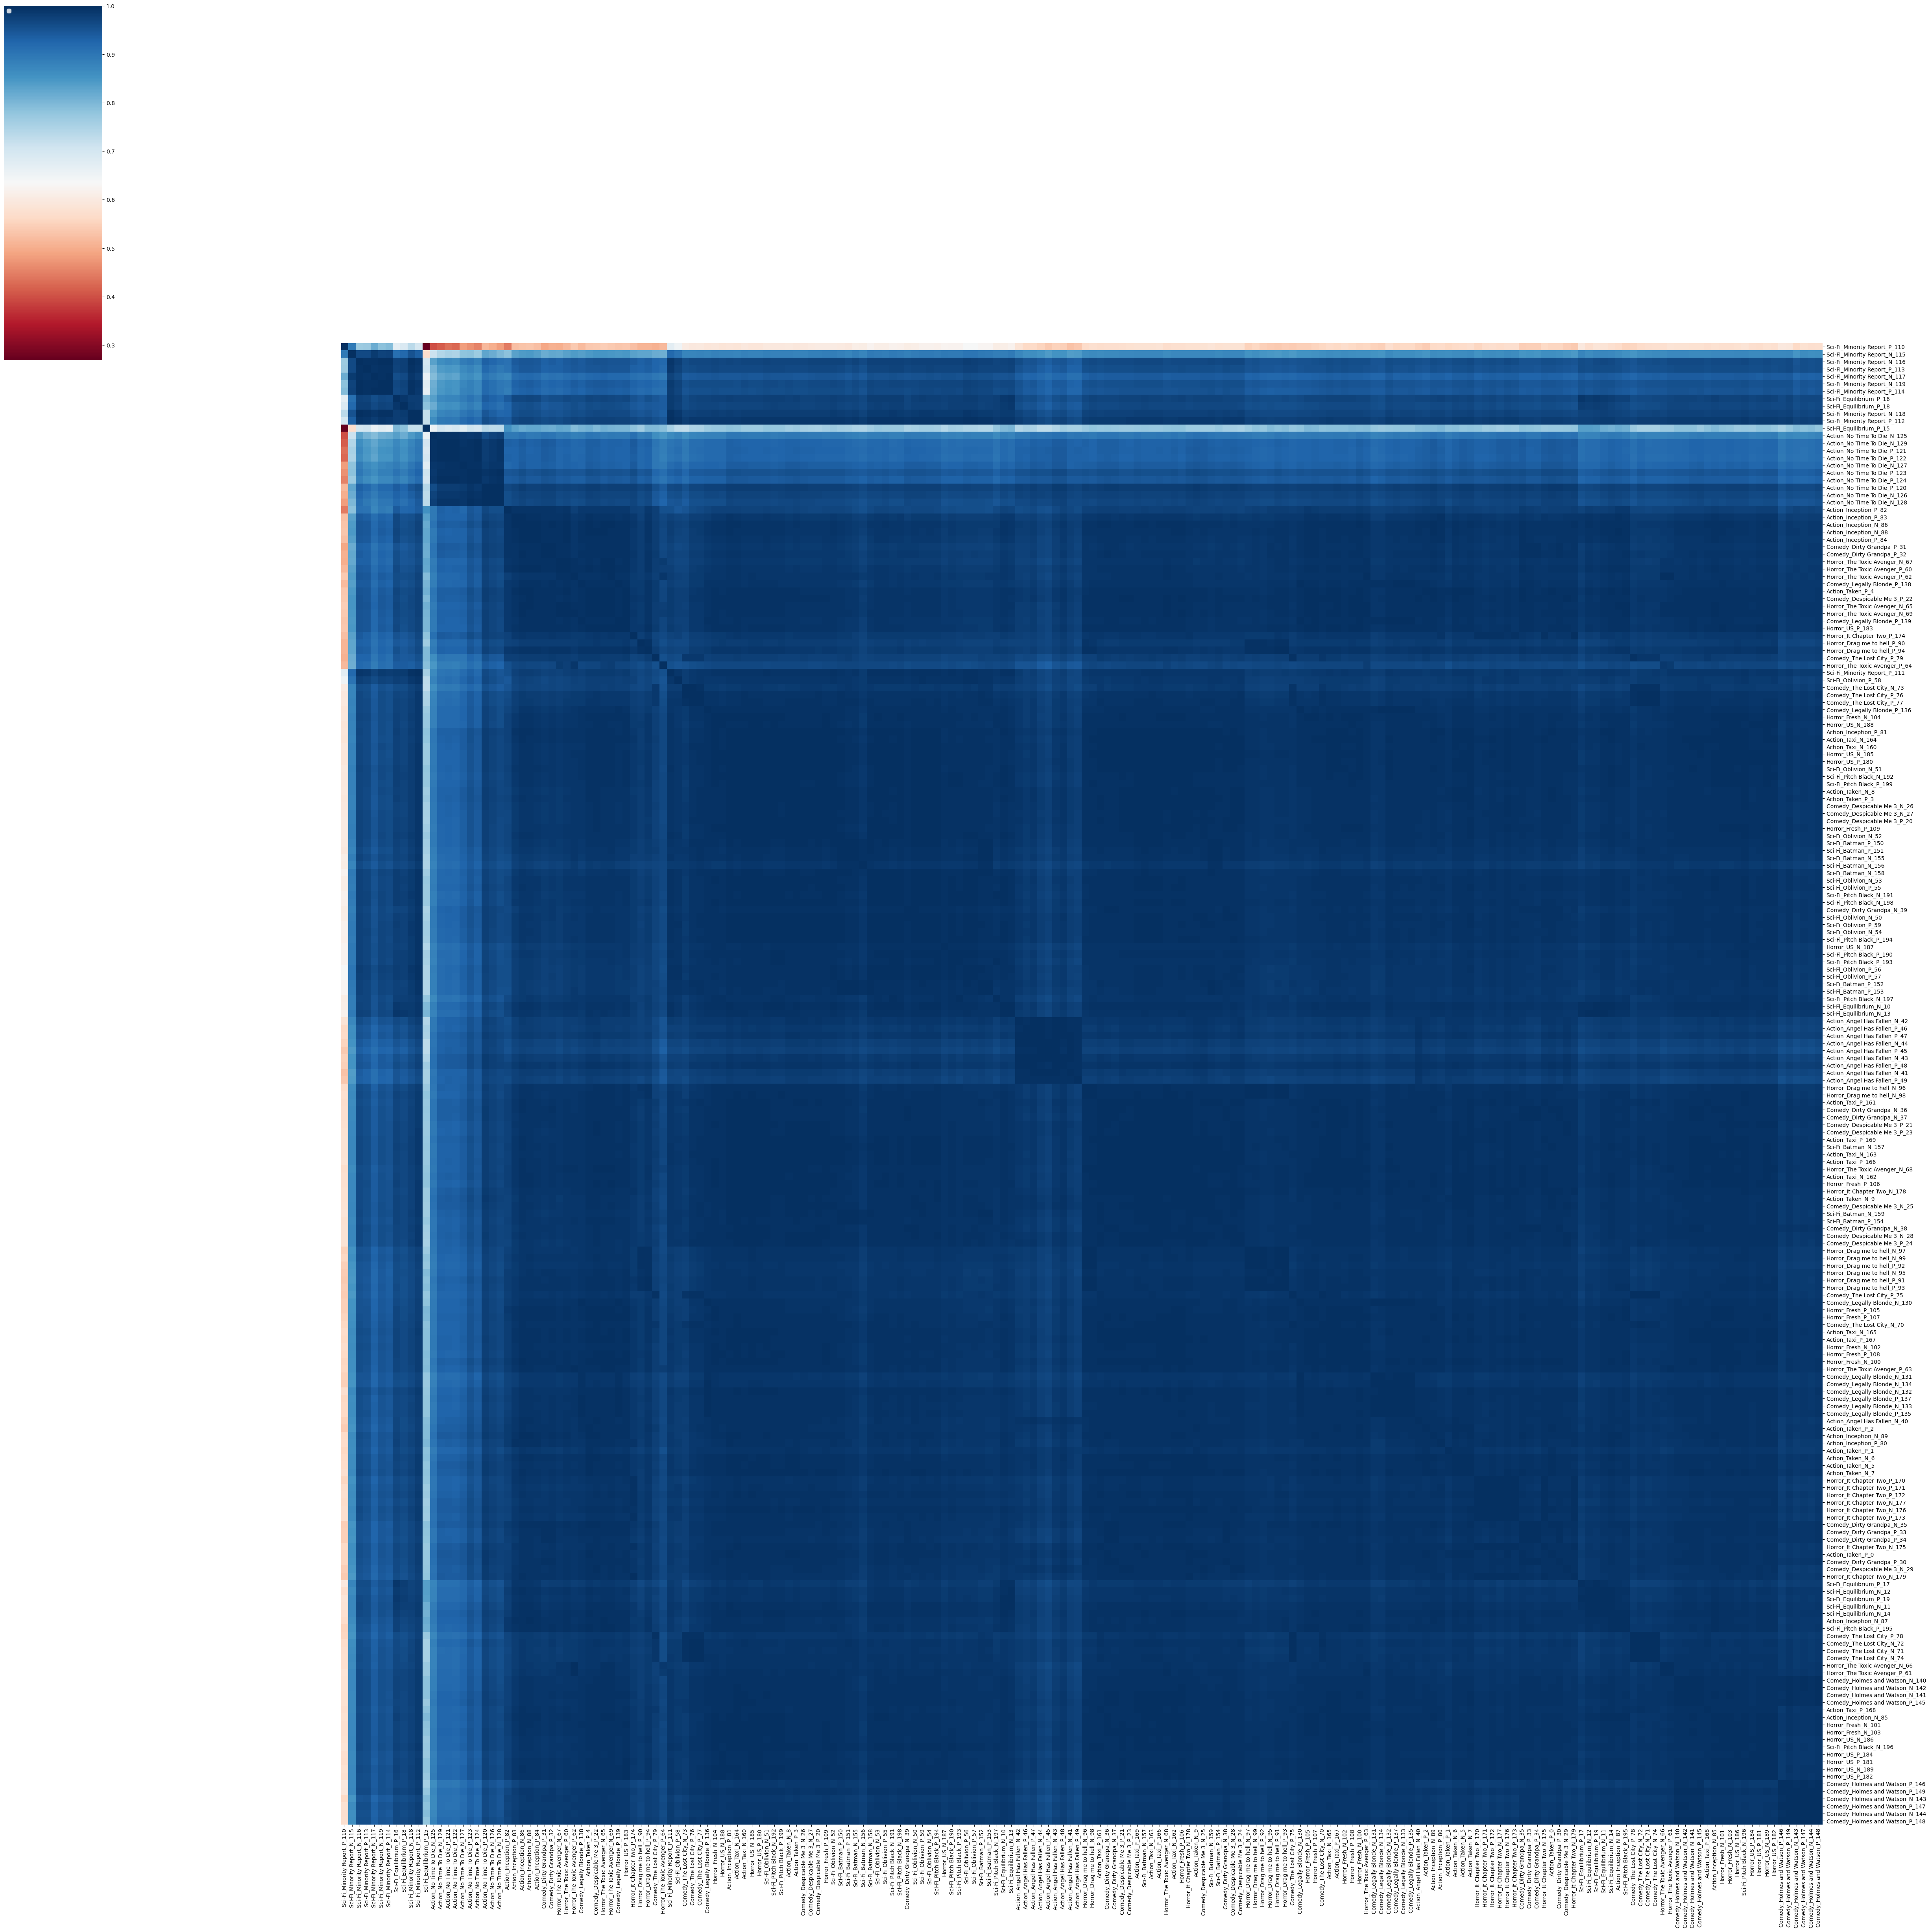

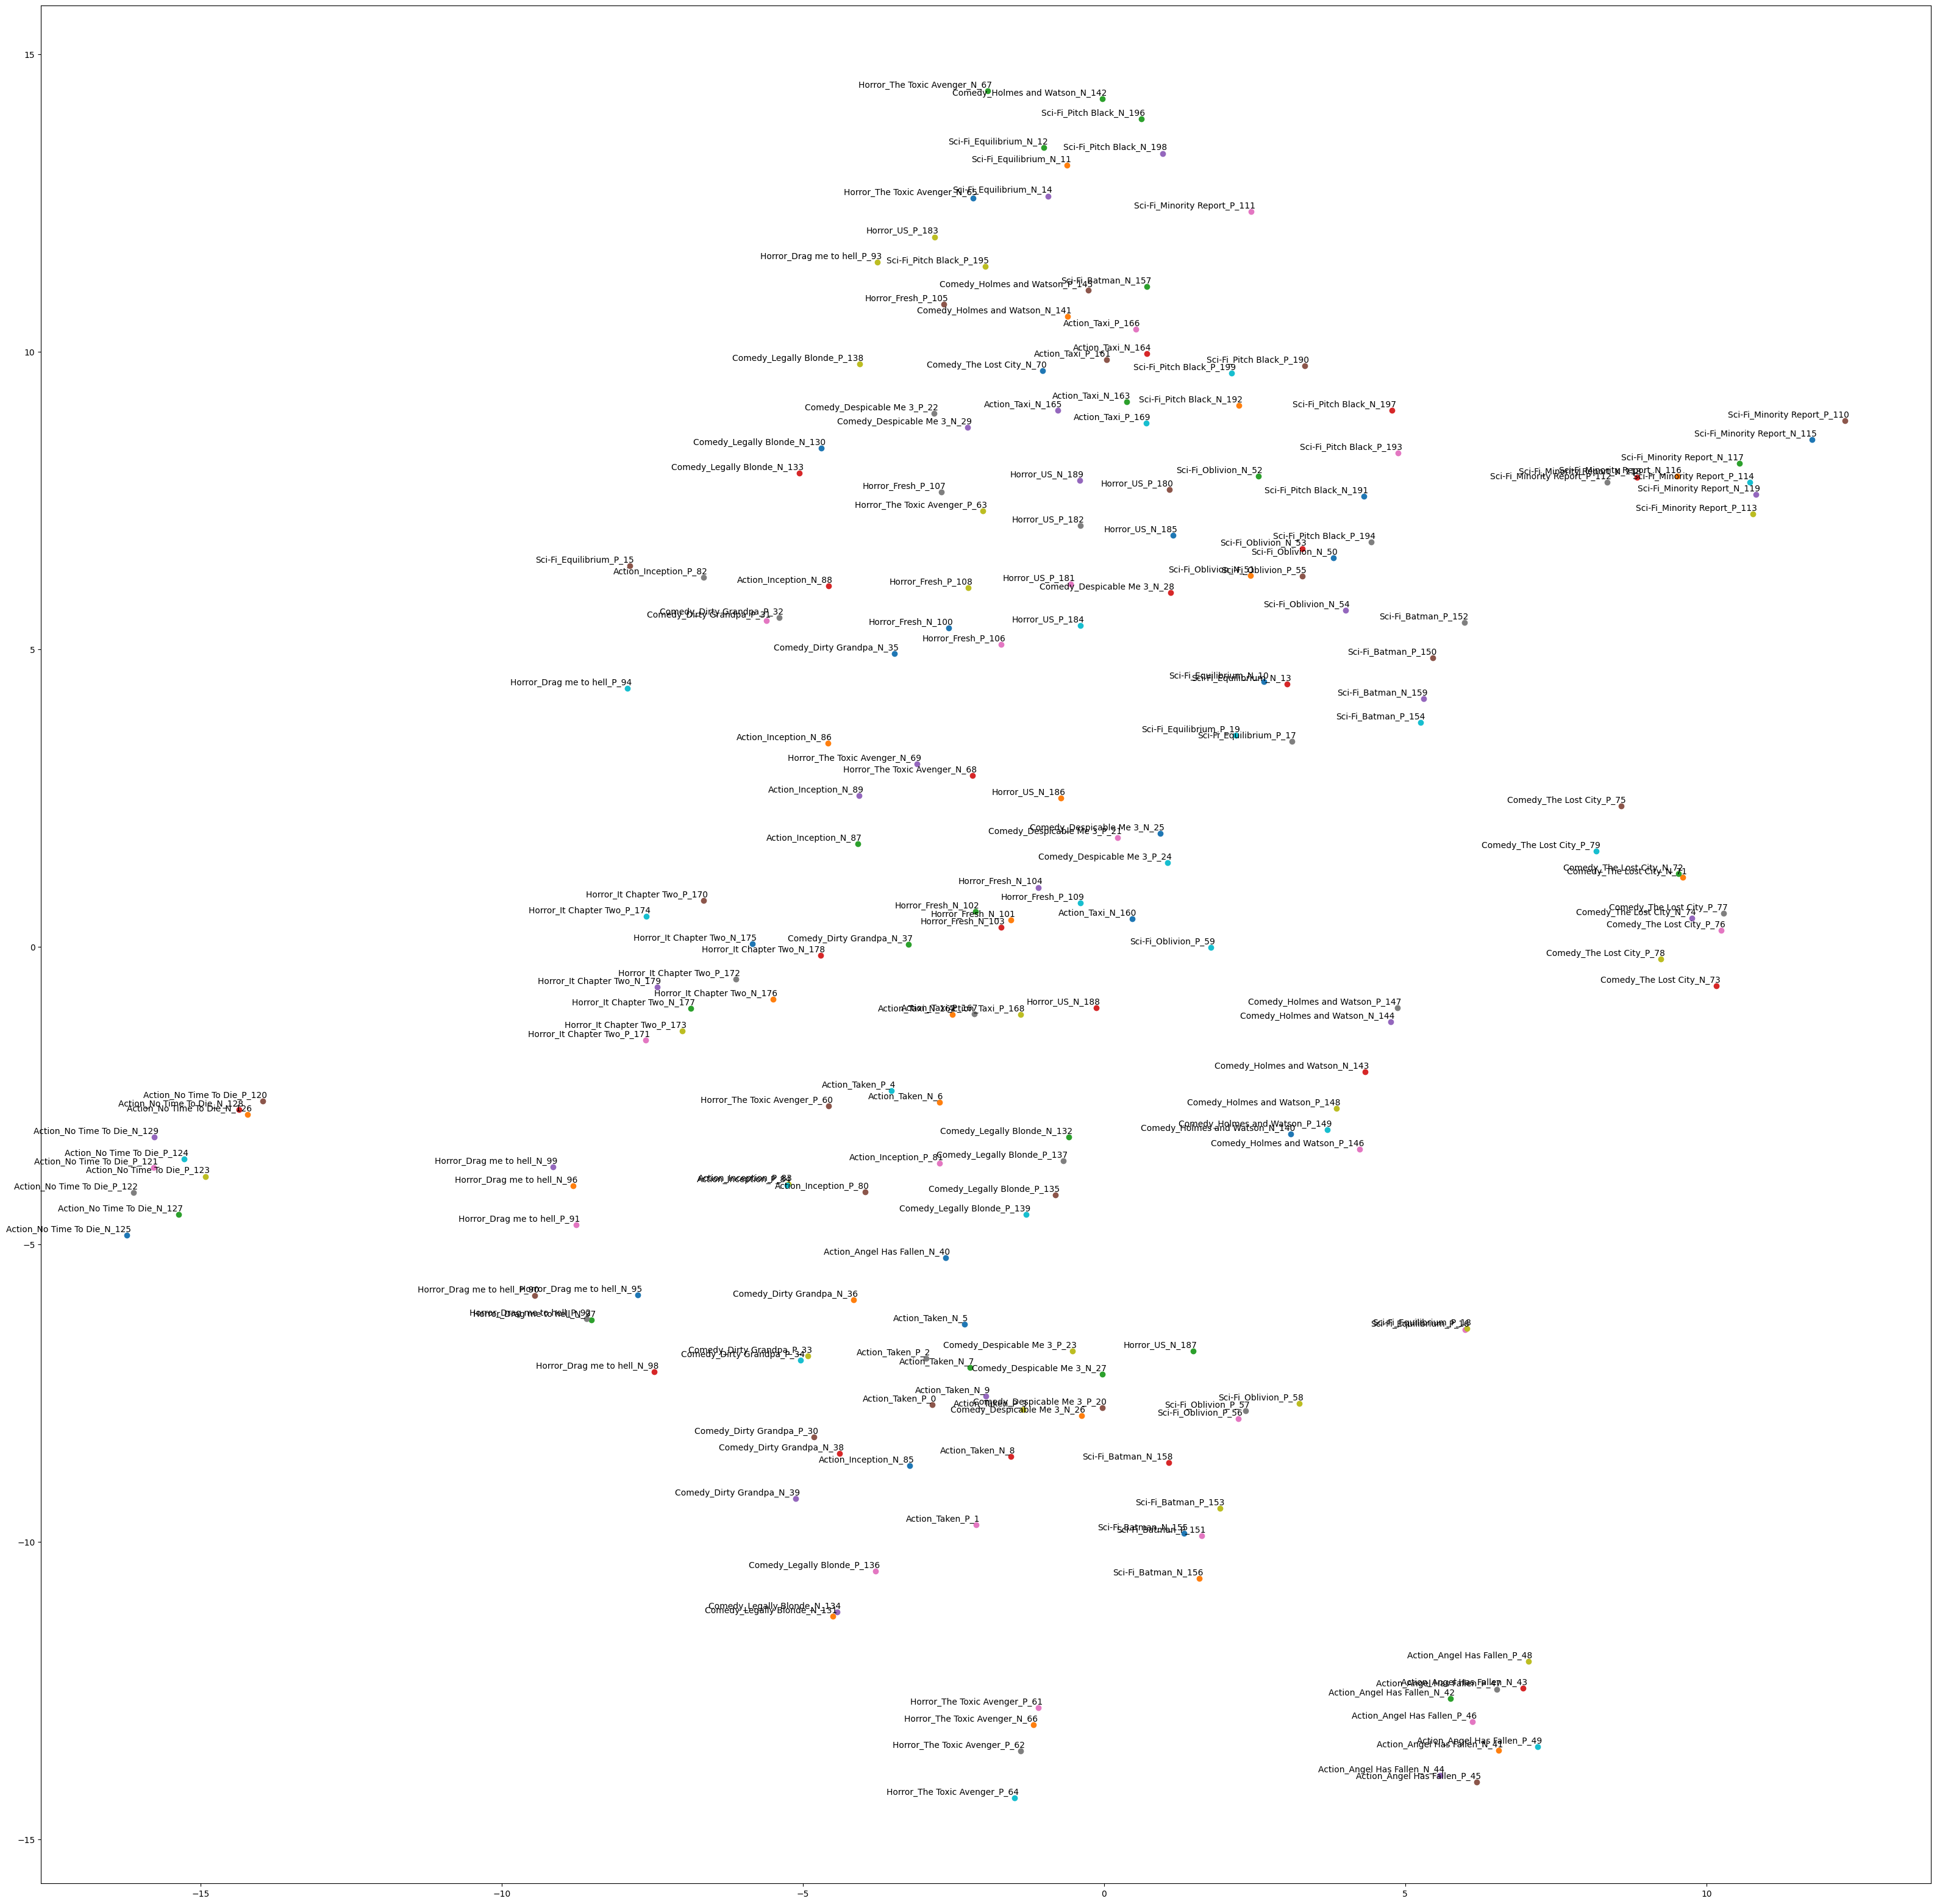

In [ ]:
run_doc2vec_experiment(documents, clean_method, 100, 'Doc2Vec_exp')

## **ELMo Emeddings**

Explore ELMo (Embeddings from Language Models) embeddings to enhance our text analysis capabilities. Unlike traditional word embeddings that represent words with static vectors, ELMo provides context-aware embeddings, capturing the nuanced meanings of words based on their usage.

This is a TensorFlow 1 version of ELMo, available at Kaggle https://www.kaggle.com/models/google/elmo/frameworks/tensorFlow1/variations/elmo/versions/3 , compatible with modern Python environments, and we use TensorFlow 2 code instead.

In [ ]:
! pip install tensorflow tensorflow-hub

In [ ]:
import tensorflow_hub as hub
import tensorflow as tf
import torch  # <--- The new addition
import pandas as pd
import numpy as np

In [ ]:
# Load the ELMo model
elmo = hub.load("https://tfhub.dev/google/elmo/3")
embeddings = elmo.signatures['default'](tf.constant(["I have a pen", "I have an apple"]))['elmo']

print(embeddings)


tf.Tensor(
[[[-1.2254355  -0.56004155 -0.17601362 ... -0.48899472 -0.15847605
   -0.02072026]
  [-0.06928669 -0.32243836 -0.20192209 ...  0.06436353 -0.01132806
    0.23569691]
  [ 0.08227284 -0.13877694 -0.11335732 ...  0.09817557 -0.39810365
    0.1064739 ]
  [-0.59798044 -0.06444039 -0.62319255 ...  0.09078256  0.02052066
    0.28290296]]

 [[-1.2254355  -0.56004155 -0.17601362 ... -0.47857666 -0.06792711
    0.08927003]
  [-0.06928669 -0.32243836 -0.20192209 ...  0.31662846  0.21778789
    0.25088534]
  [-0.15906422 -0.04295161 -0.49626738 ...  0.30489403 -0.08282581
    0.16055614]
  [ 0.33383614 -0.15934686  0.57856274 ...  0.14826375  0.4691132
    0.6117441 ]]], shape=(2, 4, 1024), dtype=float32)


In [ ]:
def get_elmo_embeddings(texts):
    """
    Generate ELMo embeddings for a list of texts and return as PyTorch Tensors.

    Parameters:
    - texts: List of strings

    Returns:
    - A PyTorch Tensor containing the ELMo embeddings.
      Shape: [Batch_Size, Sequence_Length, 1024]
    """
    # 1. Convert texts to TensorFlow constants (TF Hub requirement)
    text_tf = tf.constant(texts)

    # 2. Generate ELMo embeddings using TensorFlow
    # This runs the TF computation graph
    embeddings_tf = elmo.signatures['default'](text_tf)['elmo']

    # 3. Convert TF Tensor -> Numpy -> PyTorch Tensor
    # We detach from the TF graph and hand off to PyTorch
    embeddings_pt = torch.from_numpy(embeddings_tf.numpy())

    return embeddings_pt

In [ ]:
# NO DATA WRANGLING
texts = corpus_df['Text'].tolist()

# OR UNCOMMENT FOR DATA WRANGLING
#cleaned_documents = clean_method(documents)
#texts = [' '.join(x.tokens) for x in cleaned_documents]


In [ ]:
# Process in batches to manage memory usage
batch_size = 4
# ^-- KEEP THIS AT 4. ELMo is very memory intensive.
# Increasing this (e.g., to 32) will likely crash the Colab runtime.

all_embeddings = []

# GET ELMO EMBEDDINGS OVER A SUBSET OF ALL MOVIE REVIEWS
sample_size = 20
# ^-- Keep strictly at 20 for the demo to run instantly.
# If you run the full dataset, it will take ~30-40 minutes.

# OR UNCOMMENT TO RUN FOR ALL MOVIE REVIEWS
# sample_size = len(texts)

print(f"Starting processing of {sample_size} items with batch size {batch_size}...")

for i in range(0, sample_size, batch_size):
    # Slice the text list
    batch_texts = texts[i:i+batch_size]

    # 1. Get the PyTorch Tensor for this batch (uses our new wrapper function)
    # The heavy TF graph is created and destroyed inside this function call
    batch_embeddings_pt = get_elmo_embeddings(batch_texts)

    # 2. Append the PyTorch tensor to our list
    all_embeddings.append(batch_embeddings_pt)

    print(f"Processed batch {i//batch_size + 1}/{(sample_size + batch_size - 1)//batch_size}")

print("Done processing batches.")

Starting processing of 20 items with batch size 4...
Processed batch 1/5
Processed batch 2/5
Processed batch 3/5
Processed batch 4/5
Processed batch 5/5
Done processing batches.


In [ ]:
# # Convert the list of tensors to a single numpy array
# all_embeddings_np = np.concatenate([batch.numpy().mean(axis=1) for batch in all_embeddings], axis=0)

# CONVERT LIST OF PYTORCH TENSORS TO SINGLE NUMPY ARRAY
# We do the math in PyTorch, then export to Numpy for the plotting libraries.

# 1. Perform Mean Pooling (averaging over the sequence length)
# PyTorch uses 'dim' instead of 'axis'
# Input shape per batch: [4, Sequence_Length, 1024] -> Output: [4, 1024]
pooled_batches = [torch.mean(batch, dim=1) for batch in all_embeddings]

# 2. Concatenate the batch tensors into one large PyTorch Tensor
all_embeddings_pt = torch.cat(pooled_batches, dim=0)

print(f"Final PyTorch Tensor Shape: {all_embeddings_pt.shape}")
# Should output: torch.Size([20, 1024])

# 3. Convert to Numpy for Scikit-Learn (t-SNE) and Matplotlib
all_embeddings_np = all_embeddings_pt.numpy()

# Verify the shape for sanity
print(f"Numpy Array Shape: {all_embeddings_np.shape}")

Final PyTorch Tensor Shape: torch.Size([20, 1024])
Numpy Array Shape: (20, 1024)


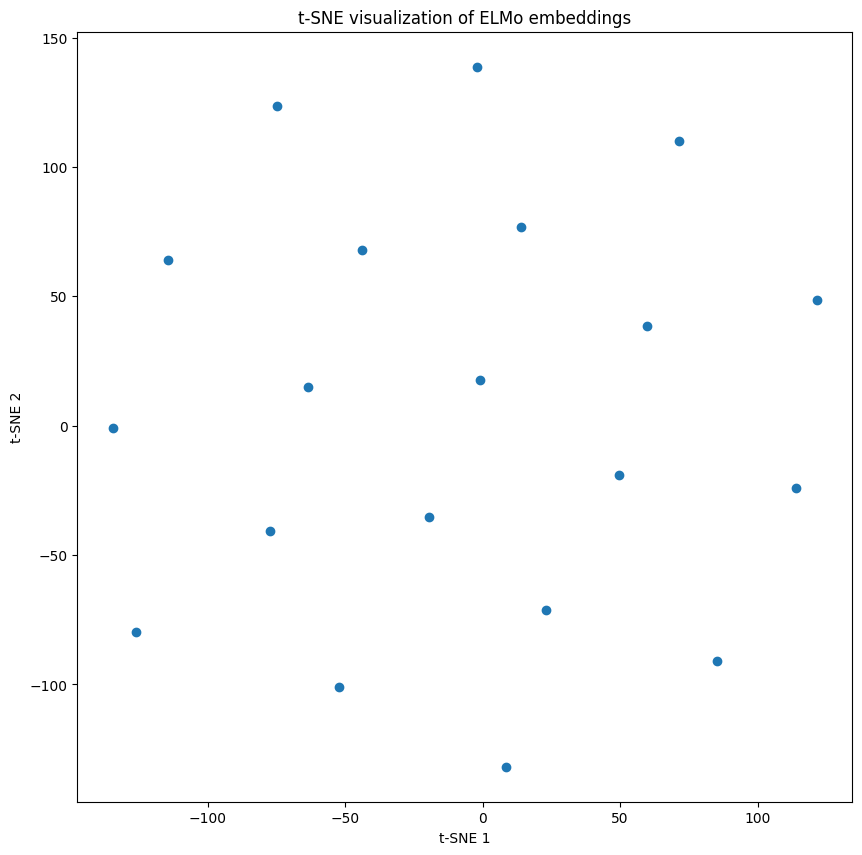

In [ ]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# Use t-SNE to reduce dimensionality for visualization
if (sample_size>=30):
    tsne = TSNE(n_components=2, random_state=42)
else:
    # Default perplexity is too large for a small sample size
    tsne = TSNE(n_components=2, random_state=42, perplexity=sample_size-1)

embeddings_tsne = tsne.fit_transform(all_embeddings_np)

# Plot
plt.figure(figsize=(10, 10))
plt.scatter(embeddings_tsne[:, 0], embeddings_tsne[:, 1])
plt.title('t-SNE visualization of ELMo embeddings')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.show()


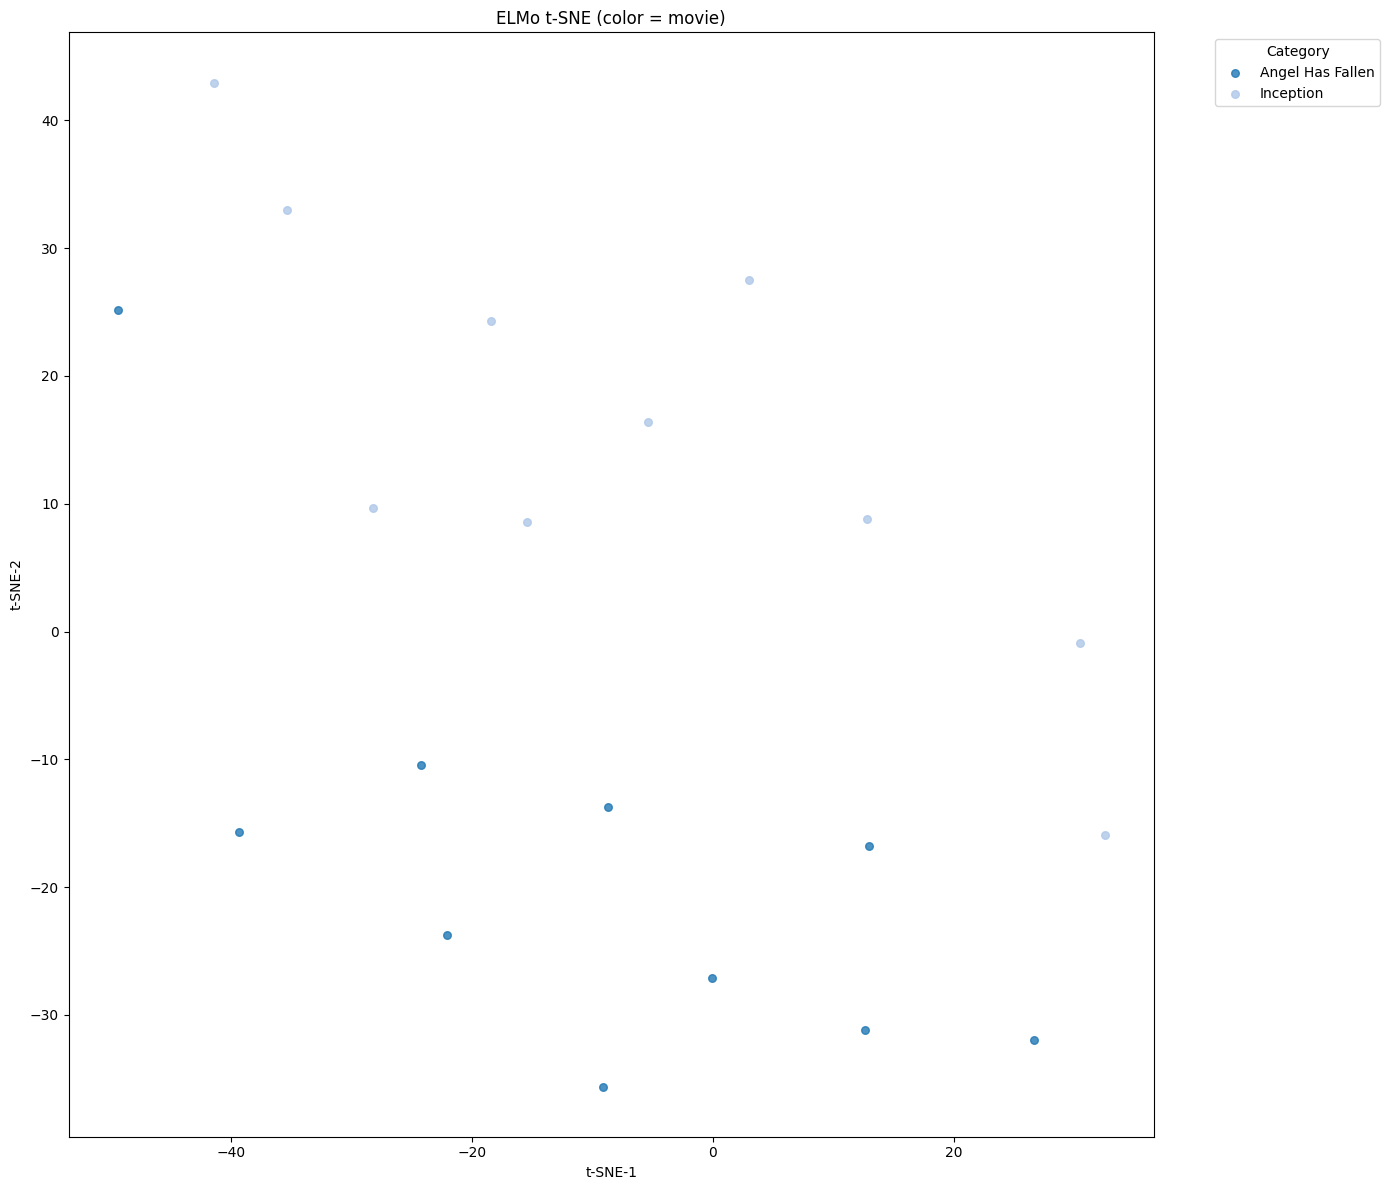

In [ ]:
# ELMo t-SNE colored by movie (uses all_embeddings_np from your ELMo section)

import pandas as pd
from sklearn.manifold import TSNE

# Number of embedded reviews = number of rows in the ELMo array
n_used = all_embeddings_np.shape[0]

doc_ids_for_embeddings = list(corpus_df.index)[:n_used]

# movie labels for those doc ids
movie_labels = [titles_by_doc_ids[doc_id] for doc_id in doc_ids_for_embeddings]

# Ensure IDs align with the embeddings
n_points = all_embeddings_np.shape[0]
doc_ids_for_embeddings = list(corpus_df.index)[:n_points]

# Build the dataframe of ELMo document vectors
elmo_doc_df = pd.DataFrame(all_embeddings_np, index=doc_ids_for_embeddings)

# Movie labels aligned to those doc IDs
movie_series = pd.Series({doc_id: titles_by_doc_ids[doc_id] for doc_id in elmo_doc_df.index})

# Call the utility with the expected argument name
unused_return_result= plot_tsne_by_category(elmo_doc_df, movie_series, title="ELMo t-SNE (color = movie)")
# ^- unused_return_result prevents large array from being printed out in notebook

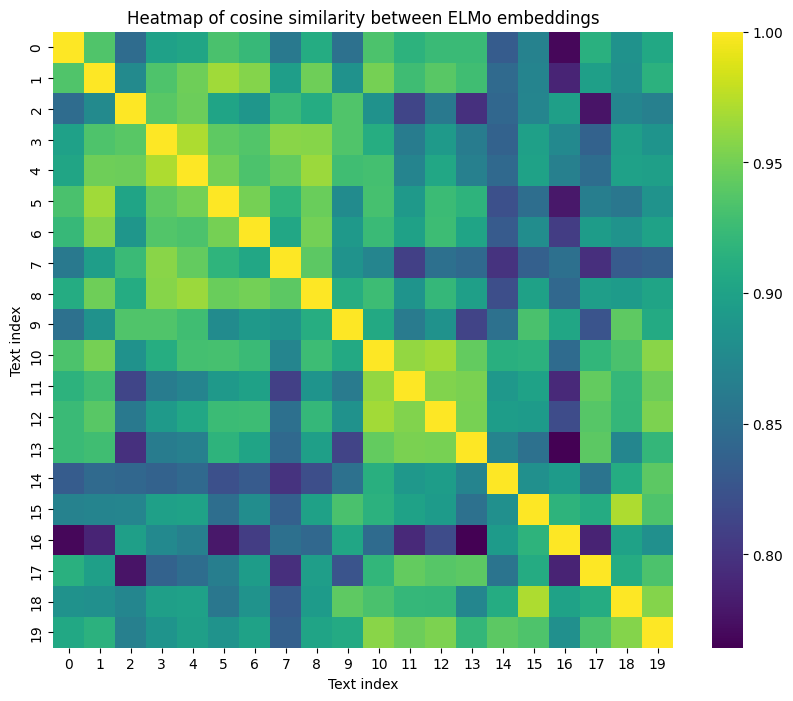

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
import seaborn as sns

# Compute the cosine similarity matrix
similarity_matrix = cosine_similarity(all_embeddings_np)

# Plot as a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(similarity_matrix, cmap='viridis')
plt.title('Heatmap of cosine similarity between ELMo embeddings')
plt.xlabel('Text index')
plt.ylabel('Text index')
plt.show()


In [ ]:
! pip freeze

absl-py==1.4.0
accelerate==1.13.0
access==1.1.10.post3
affine==2.4.0
aiofiles==24.1.0
aiohappyeyeballs==2.6.1
aiohttp==3.13.4
aiosignal==1.4.0
aiosqlite==0.22.1
alabaster==1.0.0
albucore==0.0.24
albumentations==2.0.8
ale-py==0.11.2
alembic==1.18.4
altair==5.5.0
annotated-doc==0.0.4
annotated-types==0.7.0
antlr4-python3-runtime==4.9.3
anyio==4.13.0
anywidget==0.9.21
apsw==3.51.3.0
apswutils==0.1.2
argon2-cffi==25.1.0
argon2-cffi-bindings==25.1.0
array_record==0.8.3
arrow==1.4.0
arviz==0.22.0
astropy==7.2.0
astropy-iers-data==0.2026.3.30.0.54.34
astunparse==1.6.3
atpublic==5.1
attrs==26.1.0
audioread==3.1.0
Authlib==1.6.9
autograd==1.8.0
babel==2.18.0
backcall==0.2.0
beartype==0.22.9
beautifulsoup4==4.13.5
betterproto==2.0.0b6
bigframes==2.38.0
bigquery-magics==0.12.2
bleach==6.3.0
blinker==1.9.0
blis==1.3.3
blobfile==3.2.0
blosc2==4.1.2
bokeh==3.8.2
Bottleneck==1.4.2
bqplot==0.12.45
branca==0.8.2
brotli==1.2.0
CacheControl==0.14.4
cachetools==6.2.6
catalogue==2.0.10
certifi==2026.2.25
c

In [ ]:
!pip list --format=freeze

absl-py==1.4.0
accelerate==1.13.0
access==1.1.10.post3
affine==2.4.0
aiofiles==24.1.0
aiohappyeyeballs==2.6.1
aiohttp==3.13.4
aiosignal==1.4.0
aiosqlite==0.22.1
alabaster==1.0.0
albucore==0.0.24
albumentations==2.0.8
ale-py==0.11.2
alembic==1.18.4
altair==5.5.0
annotated-doc==0.0.4
annotated-types==0.7.0
antlr4-python3-runtime==4.9.3
anyio==4.13.0
anywidget==0.9.21
apsw==3.51.3.0
apswutils==0.1.2
argon2-cffi==25.1.0
argon2-cffi-bindings==25.1.0
array_record==0.8.3
arrow==1.4.0
arviz==0.22.0
astropy==7.2.0
astropy-iers-data==0.2026.3.30.0.54.34
astunparse==1.6.3
atpublic==5.1
attrs==26.1.0
audioread==3.1.0
Authlib==1.6.9
autograd==1.8.0
babel==2.18.0
backcall==0.2.0
beartype==0.22.9
beautifulsoup4==4.13.5
betterproto==2.0.0b6
bigframes==2.38.0
bigquery-magics==0.12.2
bleach==6.3.0
blinker==1.9.0
blis==1.3.3
blobfile==3.2.0
blosc2==4.1.2
bokeh==3.8.2
Bottleneck==1.4.2
bqplot==0.12.45
branca==0.8.2
brotli==1.2.0
CacheControl==0.14.4
cachetools==6.2.6
catalogue==2.0.10
certifi==2026.2.25
c